# Complete SOH Battery Analysis

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast
import seaborn as sns
import json
import glob
import random
from copy import deepcopy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, to_rgb, to_rgba

import tensorflow as tf
from Fitting_algo_v3 import *
from ECM_impedance_v3 import *

## Load Battery Info JSON

In [3]:
battery_json_file = "../../EVC_EIS_Data/original_data/Battery_Info.json" # Check the path

with open(battery_json_file, "r") as f:
    battery_metadata = json.load(f)   # <--- this is now a dict

JSONDecodeError: Expecting value: line 249 column 25 (char 8941)

In [5]:
# Review current documented batteries
print(battery_metadata.keys())

dict_keys(['CELL042'])


## Build Battery Data from EIS

In [6]:
def format_EIS(input_file):
    """
    Load EIS input csv and return a list of dictionary indexed by soc_index.

    Parameters
    ----------
    input_file : str
        csv file path of original EIS data, required to have columns ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'].
    
    Returns
    ----------
    grouped_list : [{soc_dict}], a list of SOC dictionaries. soc_dict has attributes: freq, angular_freq, Z_mag, phase_deg, Z_real, Z_imag.
    """
    df = pd.read_csv(input_file)

    # Ensure relevant columns exist
    required = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Ensure numeric
    num_cols = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # Keep relevant cols and drop invalid rows
    df = (
        df[['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']]
        .dropna(subset=['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'])
        .query("`freq/Hz` != 0")
        .copy()
    )

    # Compute Z components
    phase_rad = np.deg2rad(df['Phase(Z)/deg'].to_numpy())
    Z_mag = df['|Z|/Ohm'].to_numpy()
    df['Z_mag'] = Z_mag
    df['Z_real'] = Z_mag * np.cos(phase_rad)
    df['Z_imag'] = Z_mag * np.sin(phase_rad)
    df['angular_freq'] = 2 * np.pi * df['freq/Hz'].to_numpy()
    df['soc_index'] = df['z cycle'].astype(int)

    # Group by z cycle and build list (index = soc_index)
    grouped_list = []
    for _, g in df.groupby('z cycle'):
        g_sorted = g.sort_values('freq/Hz', ascending=False)
        grouped_list.append({
            "freq": g_sorted['freq/Hz'].to_numpy(dtype=float),
            "angular_freq": g_sorted['angular_freq'].to_numpy(dtype=float),
            "Z_mag": g_sorted['Z_mag'].to_numpy(dtype=float),
            "phase_deg": g_sorted['Phase(Z)/deg'].to_numpy(dtype=float),
            "Z_real": g_sorted['Z_real'].to_numpy(dtype=float),
            "Z_imag": g_sorted['Z_imag'].to_numpy(dtype=float),
        })

    return grouped_list

## EIS Nyquist Plot

In [7]:
def plot_EIS_Nyquist_multi(series, labels=None, *, title=None, connect_line=True, equal_ratio=True):
    """
    Overlay multiple EIS data to one Nyquist Plot.

    Parameters
    ----------
    series : list of dict
        Each item is a dict like:
          {"Z_real": [...], "Z_imag": [...], "freq": [...]}
    labels : list of str, optional
        Legend labels for each series. If None, uses "EIS i".
    title : str, optional
        Figure title.
    connect_line : bool, default True
        Whether to connect the EIS data points or not.
    equal_ratio : bool, default True
        If True, set x:y axis aspect ratio to 1:1.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes; Call function and then call plt.show() to show the figure.
    """
    if labels is None:
        labels = [f"EIS {i}" for i in range(len(series))]
    if len(labels) != len(series):
        raise ValueError("labels length must match series length")

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

    for i, (s, lab) in enumerate(zip(series, labels)):
        Zr = np.asarray(s["Z_real"], dtype=float)
        Zi = np.asarray(s["Z_imag"], dtype=float)
        f  = np.asarray(s["freq"], dtype=float)

        if not (Zr.shape == Zi.shape == f.shape):
            raise ValueError(f"Series {i} shapes mismatch.")

        mask = np.isfinite(Zr) & np.isfinite(Zi) & np.isfinite(f) & (f > 0)
        Zr, Zi, f = Zr[mask], Zi[mask], f[mask]
        if Zr.size == 0:
            continue

        # sort by frequency: high -> low
        order = np.argsort(-f)
        Zr, Zi, f = Zr[order], Zi[order], f[order]
       
        if connect_line:
            ax.plot(Zr, -Zi, marker='o', linewidth=1.0, alpha=0.9, label=lab, markersize=4)
        else:
            ax.plot(Zr, -Zi, marker='o', linewidth=0, alpha=0.9, label=lab, markersize=4)


    ax.set_xlabel("Re(Z) [Ω]")
    ax.set_ylabel("-Im(Z) [Ω]")
    if equal_ratio:
        ax.set_aspect('equal', adjustable='box')
        ax.set_box_aspect(1)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    if title:
        ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    fig.tight_layout()

    return fig, ax

## Algorithm Fitting

In [8]:
ECM_candidates_map = dict(zip(ECM_NAMES, ECM_IMPEDANCE_FUNCS))


In [9]:
def tau_vec(R, Q, n):
    """
    Compute time constant (tau) for R-CPE component; For vector input.

    Paramters
    ----------
    R : list of float
        Resistance.
    
    Q : list of float
        Capacitance
    
    n : list of float
        Ideal factor
    
    Returns
    ----------
    Time constant value as vector
    """
    R = R.astype(float).to_numpy()
    Q = Q.astype(float).to_numpy()
    n = n.astype(float).to_numpy()
    out = np.full(R.shape, np.nan, dtype=float)  # default to NaN
    valid = (R > 0) & (Q > 0) & (n > 0) & np.isfinite(R) & np.isfinite(Q) & np.isfinite(n)
    out[valid] = np.power(R[valid] * Q[valid], 1.0 / n[valid])
    return out

In [10]:
def ECM_parameter_estimation(ECM_model_name, target_battery_name, target_battery_metadata, target_battery_EISdata, cost_func_name="RMSE_abs", trial_number=50):
    print(f"ECM Parameter Estimation for {target_battery_name}")
    
    # All SOH states
    for soh_i in range(target_battery_metadata["num_soh"]):
        soh_data = target_battery_metadata["soh"][soh_i]
        
        # All SOC states
        for soc_i in range(soh_data["num_soc"]):
            print(f"--- SOH = ({soh_i + 1}), Capacity = {soh_data["capacity"]}; SOC = ({soc_i+1}), {soh_data["soc"][soc_i]*100:.2f}%")
            soc_EISdata = target_battery_EISdata[soh_i][soc_i]
            Z_meas = soc_EISdata["Z_real"] + soc_EISdata["Z_imag"]*1j
            angular_freq = soc_EISdata["angular_freq"]

            # find ECM candidates
            if ECM_model_name not in ECM_candidates_map:
                print(f"[Warning] ECM_model_name '{ECM_model_name}' not found. Use 'v3CM7' as default."
                    f"Available options: {list(ECM_candidates_map.keys())}")
                ECM_model_name = "v3CM7"
            ECM_candidate_impedance_func = ECM_candidates_map[ECM_model_name]
            
            # call fitting function
            best_params, best_err, err_str, trial_results = ECM_result_wrapper_new(Z_meas, angular_freq,
                ECM_model_name, ECM_candidate_impedance_func, 
                trial_num=trial_number, ECM_initial_guess=None, ECM_bounds=None, 
                cost_func_name=cost_func_name, verbose=True, optimizer_option_Powell=None, 
                optimizer_option_BFGS=None
            )

            df = pd.DataFrame(trial_results)
            # Optional: Format Original Dataframe

            param_col_names = PARAMS_NAMES[ECM_model_name]
            print(param_col_names)
            params_df = pd.DataFrame(df["estimated_params"].tolist(), columns=param_col_names, index=df.index)
            
            freq_df = pd.DataFrame()
            for i in range(ECM_NUM_RCS[ECM_model_name]):
                
                tau_i = tau_vec(params_df[f"R{i+1}"], params_df[f"C{i+1}"], params_df[f"n{i+1}"])
                params_df[f"tau{i+1}"] = tau_i
                freq_df[f"freq{i+1}"] = 1.0 / (2.0 * np.pi * tau_i)
            
            df_out = pd.concat([df, params_df, freq_df], axis=1)
            
            # Sort rows by the cost function column
            df_out = df_out.sort_values(by=[f"{cost_func_name}"], ascending=True).reset_index(drop=True)
            df_out.insert(0, "trial_rank", range(1, len(df_out) + 1))

            save_dir = f"ECM_Params_Estimation/{target_battery_name}/{ECM_model_name}_{cost_func_name}_trials{trial_number}/soh{soh_i+1}/"
            os.makedirs(save_dir, exist_ok=True)

            save_path = os.path.join(save_dir, f"{target_battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{trial_number}_objFunc_{cost_func_name}_{ECM_model_name}.csv")
            df_out.to_csv(save_path, index=False)
            print("--- CSV file saved.")

## Algorithm Fitting Result ---- Remove Outliers

In [ ]:
def remove_outliers(input_filename, param_col_names, savedir):
    if not os.path.exists(input_filename):
        print(f"File not found: {input_filename}")
        return

    df = pd.read_csv(input_filename)

    # ---- Step 1: drop rows where freq1 > 10K
    mask_freq1 = df["freq1"] <= 10000
    df_step1 = df.loc[mask_freq1]
    print(f"Step 1: {len(df_step1)} rows kept after freq1 <= 10kHz")

    # ---- Step 2: drop rows where ANY parameter < 1e-6
    mask_params = (df_step1[param_col_names] >= 1e-6).all(axis=1)
    df_step2 = df_step1.loc[mask_params]
    print(f"Step 2: {len(df_step2)} rows kept after filtering parameters >= 1e-6")

    # ---- Step 3: drop rows where RMSE_abs > 0.008
    if "RMSE_abs" in df_step2.columns:
        mask_rmse = df_step2["RMSE_abs"] <= 0.008
        df_step3 = df_step2.loc[mask_rmse]
        print(f"Step 3: {len(df_step3)} rows kept after RMSE_abs <= 0.008")
    else:
        print("Warning: 'RMSE_abs' column not found. Skipping Step 3.")
        df_step3 = df_step2

    # ---- Step 4: drop rows where R2_magnitude < 0.998
    if "R2_magnitude" in df_step3.columns:
        mask_r2 = df_step3["R2_magnitude"] >= 0.998
        df_step4 = df_step3.loc[mask_r2]
        print(f"Step 4: {len(df_step4)} rows kept after R2_magnitude >= 0.998")
    else:
        print("Warning: 'R2_magnitude' column not found. Skipping Step 4.")
        df_step4 = df_step3

    # Save final output
    os.makedirs(savedir, exist_ok=True)
    output_filename = os.path.join(
        savedir,
        os.path.splitext(os.path.basename(input_filename))[0] + "_rmOutliers.csv"
    )
    df_step4.to_csv(output_filename, index=False)
    print(f"Filtered data saved to: {output_filename}")

## Build Merged Df

In [ ]:
def build_merged_df(battery_name, battery_metadata, ECM_model_name, num_trials, obj_func, suffix=None):
    best_trial_df = []
    median_df = []
    mean_df = []
    full_trials_df = []

    # further separate medain df by soc > 25% and soc <= 25%
    median_df_socG24 = []
    median_df_socLEQ25 = []
    
    base_folder = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}/"
    if suffix:
        base_folder = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}_{suffix}/"
    
     # All SOH states
    for soh_i in range(battery_metadata["num_soh"]):
        if soh_i == 3 or soh_i == 5:
            continue # NOTE: Skip SOH 4 and 6 for CELL042
        soh_data = battery_metadata["soh"][soh_i]
        for soc_i in range(soh_data["num_soc"]):
            if suffix:
                file = os.path.join(
                    base_folder,
                    f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}_{suffix}.csv"
                )
            else:
                file = os.path.join(
                    base_folder,
                    f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}.csv"
                )
       
            df = pd.read_csv(file)
            df["SOH"] = soh_data["capacity"]
            df["SOC"] = soh_data["soc"][soc_i]
            best_trial_df.append(df.iloc[0])

            params_names = PARAMS_NAMES[ECM_model_name]
            
            median_row = df[params_names].median()
            median_row["SOH"] = soh_data["capacity"]
            median_row["SOC"] = soh_data["soc"][soc_i]
            median_df.append(median_row)
            if soh_data["soc"][soc_i] > 0.25:
                median_df_socG24.append(median_row)
            else:
                median_df_socLEQ25.append(median_row)
            
            mean_row = df[params_names].mean()
            mean_row["SOH"] = soh_data["capacity"]
            mean_row["SOC"] = soh_data["soc"][soc_i]
            mean_df.append(mean_row)

    df_best = pd.DataFrame(best_trial_df)
    df_median = pd.DataFrame(median_df)
    df_mean = pd.DataFrame(mean_df)
    df_median_socG24 = pd.DataFrame(median_df_socG24)
    df_median_socLEQ25 = pd.DataFrame(median_df_socLEQ25)


    df_best.to_csv(os.path.join(base_folder, f"{battery_name}_{ECM_model_name}_trials{num_trials}_bestTrials_allSOH_allSOC.csv"), index=False)
    df_median.to_csv(os.path.join(base_folder, f"{battery_name}_{ECM_model_name}_trials{num_trials}_median_allSOH_allSOC.csv"), index=False)
    df_mean.to_csv(os.path.join(base_folder, f"{battery_name}_{ECM_model_name}_trials{num_trials}_mean_allSOH_allSOC.csv"), index=False)
    df_median_socG24.to_csv(os.path.join(base_folder, f"{battery_name}_{ECM_model_name}_trials{num_trials}_median_socG25_allSOH.csv"), index=False)
    df_median_socLEQ25.to_csv(os.path.join(base_folder, f"{battery_name}_{ECM_model_name}_trials{num_trials}_median_socLEQ25_allSOH.csv"), index=False)
    print("Merged CSV files saved.")

    return df_best, df_median, df_mean, df_median_socG24, df_median_socLEQ25

In [589]:
def build_merged_df_option(battery_name, battery_metadata, ECM_model_name, num_trials, obj_func, suffix=None, stats="median", soc_range="all"):
    result_rows = []
    
    base_folder = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}/"
    if suffix:
        base_folder = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}_{suffix}/"
    
     # All SOH states
    for soh_i in range(battery_metadata["num_soh"]):
        if soh_i == 3 or soh_i == 5:
            continue # NOTE: Skip SOH 4 and 6 for CELL042
        soh_data = battery_metadata["soh"][soh_i]
        for soc_i in range(soh_data["num_soc"]):
            if suffix:
                file = os.path.join(
                    base_folder,
                    f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}_{suffix}.csv"
                )
            else:
                file = os.path.join(
                    base_folder,
                    f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}.csv"
                )
       
            df = pd.read_csv(file)
            params_names = PARAMS_NAMES[ECM_model_name]

            # Build SOC/SOH scalars
            soh_val = soh_data["capacity"]
            soc_val = soh_data["soc"][soc_i]

            # Apply SOC-range filter logic
            def soc_in_range(v):
                if soc_range == "all":
                    return True
                if soc_range == "G25":     # > 0.25
                    return v > 0.25
                if soc_range == "LEQ25":   # <= 0.25
                    return v <= 0.25
                raise ValueError("soc_range must be one of ['all', 'G25', 'LEQ25']")

            if not soc_in_range(soc_val):
                continue

            if stats == "all":
                rows = df[params_names].copy()
                rows["SOH"] = soh_val
                rows["SOC"] = soc_val
                result_rows.append(rows)
                continue

            # Single-row stats
            if stats == "median":
                row = df[params_names].median()
            elif stats == "mean":
                row = df[params_names].mean()
            elif stats == "best":
                # df is already ordered so that the first row is "best"
                row = df[params_names].iloc[0]
            else:
                raise ValueError("stats must be one of ['median', 'mean', 'best', 'all']")

            row_df = row.to_frame().T  # normalize to a 1-row DataFrame
            row_df["SOH"] = soh_val
            row_df["SOC"] = soc_val
            result_rows.append(row_df)

    # Concatenate to build dataframe
    if result_rows:
        result_df = pd.concat(result_rows, ignore_index=True)
    else:
        params_names = PARAMS_NAMES[ECM_model_name]
        result_df = pd.DataFrame(columns=list(params_names) + ["SOH", "SOC"])

    # Save merged CSV
    save_path = os.path.join(
        base_folder,
        f"{battery_name}_{ECM_model_name}_trials{num_trials}_allSOH_{stats}_{soc_range}SOC.csv",
    )
    result_df.to_csv(save_path, index=False)
    print(f"Merged CSV files saved to {save_path}.")

    return result_df

## Per Parameter Analysis Plots

### Functions

In [12]:
# Plot Config
BASE_COLORS = ["red", "blue", "green", "orange", "purple", "brown", "teal", "gold", "magenta", "olive"]
MARKER, MARKER_SIZE, EDGE_WIDTH = "o", 50, 0.6

# ----------------------------------------------------------------------------------------------------------
def load_best_row(csv_path):
    df = pd.read_csv(csv_path)
    if "trial_rank" not in df.columns:
        raise ValueError(f"'trial_rank' column missing in {csv_path}")
    best = df.loc[df["trial_rank"] == 1]
    if best.empty:
        raise ValueError(f"No row with trial_rank==1 in {csv_path}")
    return best.iloc[0]


def gather_best_trial_dataset(battery_name, obj_func, ECM_model_name, num_trials, battery_metadata):
    rows = []
    for soh_i in range(battery_metadata["num_soh"]):
        for soc_i in range(battery_metadata["soh"][soh_i]["num_soc"]):
            fname = f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}.csv"
            root_dir = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}/"
            file_path = os.path.join(root_dir, fname)
            if not os.path.exists(file_path):
                print(f"[WARN] Missing file (skip): {file_path}")
                continue
            try:
                s = load_best_row(file_path)
                row = {
                    "soh_label": soh_i + 1,
                    "soh_capacity": battery_metadata["soh"][soh_i]["capacity"],
                    "soc_label": soc_i + 1,
                    "soc": battery_metadata["soh"][soh_i]["soc"][soc_i],
                    "path": file_path
                }
                for p in PARAMS_NAMES[ECM_model_name]:
                    if p not in s.index:
                        raise ValueError(f"Param '{p}' missing in {file_path}")
                    row[p] = s[p]
                # tau and freqs
                for t in range(ECM_NUM_RCS[ECM_model_name]):
                    tau = f"tau{t+1}"
                    if tau not in s.index:
                        raise ValueError(f"Param '{tau}' missing in {file_path}")
                    row[tau] = s[tau]
                    freq = f"freq{t+1}"
                    if freq not in s.index:
                        raise ValueError(f"Param '{freq}' missing in {file_path}")
                    row[freq] = s[freq]

                rows.append(row)
            except Exception as e:
                print(f"[WARN] Skipping {file_path}: {e}")
    if not rows:
        raise RuntimeError("No valid CSVs collected.")
    return pd.DataFrame(rows)


def gather_all_trials_dataset(battery_name, obj_func, ECM_model_name, num_trials, battery_metadata, rmOutlier_suffix = None):
    rows = []
    for soh_i in range(battery_metadata["num_soh"]):
        for soc_i in range(battery_metadata["soh"][soh_i]["num_soc"]):
            fname = f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}.csv"
            root_dir = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}/"
            
            if rmOutlier_suffix is not None:
                fname = f"soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_model_name}_{rmOutlier_suffix}.csv"
                root_dir = f"ECM_Params_Estimation/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}_{rmOutlier_suffix}/"
            
            file_path = os.path.join(root_dir, fname)

            if not os.path.exists(file_path):
                print(f"[WARN] Missing file (skip): {file_path}")
                continue

            try:
                df = pd.read_csv(file_path)

                for _, s in df.iterrows():
                    row = {
                        "soh_label": soh_i + 1,
                        "soh_capacity": battery_metadata["soh"][soh_i]["capacity"],
                        "soc_label": soc_i + 1,
                        "soc": battery_metadata["soh"][soh_i]["soc"][soc_i],
                        "path": file_path
                    }

                    # Add model parameters
                    for p in PARAMS_NAMES[ECM_model_name]:
                        if p not in s.index:
                            raise ValueError(f"Param '{p}' missing in {file_path}")
                        row[p] = s[p]

                    # Add RC pair components
                    for t in range(ECM_NUM_RCS[ECM_model_name]):
                        tau = f"tau{t+1}"
                        freq = f"freq{t+1}"
                        if tau not in s.index or freq not in s.index:
                            raise ValueError(f"Param '{tau}' or '{freq}' missing in {file_path}")
                        row[tau] = s[tau]
                        row[freq] = s[freq]

                    rows.append(row)

            except Exception as e:
                print(f"[WARN] Skipping {file_path}: {e}")

    if not rows:
        raise RuntimeError("No valid rows collected from any file.")
    
    return pd.DataFrame(rows)


def make_soh_cmaps(battery_metadata, base_colors=BASE_COLORS):
    cmap_map = {}
    soh_items = battery_metadata.get("soh", [])
    for i, soh_item in enumerate(soh_items):
        soh_label = i + 1
        base_rgb = to_rgb(base_colors[i % len(base_colors)])
        dark = tuple(c * 0.6 for c in base_rgb)
        light = tuple(1 - (1 - c) * 0.3 for c in base_rgb)
        cmap = LinearSegmentedColormap.from_list(f"soh{soh_label}", [light, base_rgb, dark])
        cmap_map[soh_label] = (cmap, base_rgb)
    return cmap_map

def color_for_soh_soc(cmap_map, df, soh, soc):
    cmap, _ = cmap_map[soh]
    group = df[df['soh_label'] == soh].copy()
    socs = group['soc'].astype(float)
    soc_min, soc_max = socs.min(), socs.max()
    if soc_max == soc_min:
        return cmap(0.5)
    t = (float(soc) - soc_min) / (soc_max - soc_min)
    return cmap(t)

### Per parameter value vs. SOH (SOC grident color, one trial result per SOC)

In [13]:
def plot_param(df, param, battery_metadata, battery_name, obj_func, ECM_model_name, num_trials):
    df["soc"] = df["soc"].astype(float).round(6)
    cmap_map = make_soh_cmaps(battery_metadata)
    sohs = sorted(df["soh_label"].unique())
    fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
    legend_handles = []

    for soh in sohs:
        sub = df[df["soh_label"] == soh]
        total = max(1, len(sub))
        jitter = 0.06
        for idx, row in enumerate(sub.itertuples(), start=1):
            color = color_for_soh_soc(cmap_map, df, soh=int(row.soh_label), soc=row.soc)
            ax.scatter(
                soh + (idx - (total + 1) / 2) / total * jitter,
                getattr(row, param),
                s=MARKER_SIZE,
                marker=MARKER,
                facecolor=color,
                edgecolor="black",
                linewidth=EDGE_WIDTH,
                alpha=0.95
            )
        _, base_rgb = cmap_map[soh]
        legend_handles.append(
            ax.scatter([], [], s=MARKER_SIZE, marker=MARKER, facecolor=base_rgb,
                       edgecolor="black", linewidth=EDGE_WIDTH,
                       label=f"SOH {soh} (Capacity = {sub['soh_capacity'].iloc[0]:.2f})")
        )

    ax.set_xlabel("SOH index")
    ax.set_ylabel(param)
    ax.set_title(f"{battery_name}--{param} vs. SOH (best trial per SOC) \n {num_trials}trials_objFunc_{obj_func}_{ECM_model_name}")
    ax.set_xticks(sohs)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(handles=legend_handles, title="Dark -> Light: High SOC -> Low SOC", loc="best", frameon=True)
    output_dir = f"ECM_Plots/Per-params_vs_SOH/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}/"
    os.makedirs(output_dir, exist_ok=True)
    outpath = os.path.join(output_dir, f"{param}_vs_soh.png")
    plt.tight_layout()
    plt.savefig(outpath)
    plt.show()

### per parameter value vs. SOC (Multiple SOH together)

In [202]:
def plot_param_boxplot_by_soc(df, param, battery_metadata, battery_name, obj_func, ECM_model_name, num_trials):
    df["soc"] = df["soc"].astype(float).round(6)

    # Unique sorted SOC values
    soc_values = sorted(df["soc"].unique())
    # print(len(soc_values))

    # Use default color cycle
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    # print(default_colors)

    fig, ax = plt.subplots(figsize=(40, 6), dpi=200)

    box_data = []
    xtick_labels = []
    box_colors = []
    color_dict = {}

    # print(df.head)
    from collections import Counter

    for i, soc in enumerate(soc_values):
        vals = df[df["soc"] == soc][param].values
        soh = df[df["soc"] == soc]['soh_label'].values
        # print(Counter(np.array(soh)))
        # print(np.array(vals).shape)
        if len(vals) == 0:
            continue
        box_data.append(vals)
        xtick_labels.append(f"{soc * 100:.2f}%")
        color_idx = df[df["soc"] == soc]['soh_label'].values[0]
        box_colors.append(default_colors[color_idx])
        color_dict[default_colors[color_idx]] = color_idx

    bp = ax.boxplot(box_data, patch_artist=True)
    # print(box_colors)

    # used_color = []
    # Apply colors
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(to_rgba(color))
        patch.set_edgecolor('black')
        patch.set_linewidth(0.6)
        # if color not in used_color:
        #     used_color.append(color)
        #     patch.set_label(color_dict[color])

    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.2)

    # Axis and labels
    ax.set_xticks(range(1, len(xtick_labels) + 1))
    ax.set_xticklabels(xtick_labels)
    # Color each xtick label
    for label, color in zip(ax.get_xticklabels(), box_colors):
        label.set_color(color)
    ax.set_xlabel("SOC")
    ax.set_ylabel(param)
    ax.set_ylim(-0.0001, 0.006)

    ax.set_title(f"{battery_name} -- {param} vs SOC\n{num_trials}trials_objFunc_{obj_func}_{ECM_model_name}")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.invert_xaxis()

    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=k, label=f"SOH {v} (Capacity = {df[df["soh_label"] == v]["soh_capacity"].values[0]:.2f})") for k, v in color_dict.items()]
    sorted_handles = sorted(legend_handles, key=lambda h: h.get_label())

    ax.legend(handles=sorted_handles, loc='upper center', ncol=len(sorted_handles))
    # Save
    output_dir = f"ECM_Plots/Parameter_vs_SOC/{battery_name}/{ECM_model_name}_{obj_func}_trials{num_trials}/"
    os.makedirs(output_dir, exist_ok=True)
    outpath = os.path.join(output_dir, f"boxplot_{param}_vs_SOC.png")
    plt.tight_layout()
    plt.savefig(outpath)
    plt.show()

    return outpath

## EIS Reconstruction Plot

In [15]:
ECM_candidates_map = dict(zip(ECM_NAMES, ECM_IMPEDANCE_FUNCS))

def EIS_Nyquist_meas_vs_fit(battery_name, battery_metadata, battery_EISdata, soh_label, soc_label, ECM_name, est_result_file, select_est_ranks=[1], subtitle=""):

    soh_soc_eis = battery_EISdata[soh_label-1][soc_label-1]

    Z_meas_real = soh_soc_eis["Z_real"]
    Z_meas_negimag = -soh_soc_eis["Z_imag"]
    angular_freq = soh_soc_eis["angular_freq"]
    
    if os.path.exists(est_result_file):
        df = pd.read_csv(est_result_file)
        selected = df[df["trial_rank"].isin(select_est_ranks)].copy()
    else:
        print(f"[WARN] est_result_file not found: {est_result_file}")
    
    plt.figure(figsize=(8,8))
    plt.plot(Z_meas_real, Z_meas_negimag, marker="o", label="Lab Measurement")

    for _, row in selected.iterrows():
            rank = int(row["trial_rank"])

            est_params = ast.literal_eval(row["estimated_params"])
            Z_fit = ECM_candidates_map[ECM_name](est_params, angular_freq)
            plt.plot(Z_fit.real, -Z_fit.imag, linestyle="--", marker="*", label=f"ECM fit (rank={rank})")

    plt.xlabel("Re(Z) [Ω]")
    plt.ylabel("-Im(Z) [Ω]")
    plt.legend()

    cap = battery_metadata["soh"][soh_label - 1]["capacity"]
    soc_val = battery_metadata["soh"][soh_label - 1]["soc"][soc_label - 1] * 100.0
    plt.title(
        f"{battery_name} Lab EIS vs ECM Reconstruction\n"
        f"SOH_index = {soh_label}; Capacity = {cap:.2f}\n"
        f"SOC_index = {soc_label}; SOC = {soc_val:.2f}%\n"
        f"{subtitle}"
    )

    plt.tight_layout()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.show()

## Battery Analysis

### CELL042

#### Load Cell42 Metadata and build EIS datalist

In [16]:
cell42_metadata = battery_metadata["CELL042"]
print(cell42_metadata["temperature"])
print(cell42_metadata["num_soh"])   

# Battery data retrieval example
for i in range(cell42_metadata["num_soh"]):
    # Access SOH data
    soh_data = cell42_metadata["soh"][i]
    print(f"SOH idex {i+1}, EIS data file: {soh_data["file"]}, Charge Capacity is {soh_data["capacity"]}")
    # Access SOC data
    print(f"---- This SOH state has {soh_data["num_soc"]} soc data: {soh_data["soc"]}")



25
6
SOH idex 1, EIS data file: CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_1_P25C_15P0PSI_20220916_R0_CH005_01_MB_CA5.csv, Charge Capacity is 3.57711999999088
---- This SOH state has 11 soc data: [0.91334795113419, 0.829058990476625, 0.744766549816325, 0.660466343466384, 0.576220423943298, 0.491863025600425, 0.407500502163755, 0.323125789995881, 0.238843798719101, 0.154576731274976, 0.0703326490812476]
SOH idex 2, EIS data file: CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_2_P25C_15P0PSI_20221205_R0_CH005_01_MB_CA5.csv, Charge Capacity is 3.31860999999049
---- This SOH state has 8 soc data: [0.88909652121149, 0.777845079967347, 0.666488369036082, 0.55511891267283, 0.443611155059855, 0.33214687810657, 0.220582790882964, 0.108927204983737]
SOH idex 3, EIS data file: CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_3d_P25C_15P0PSI_20230324_R0_CA4.csv, Charge Capacity is 3.05106999998998
---- This SOH state has 8 soc data: [0.880123714125144, 0.75996424602003, 0.640093507171995, 0.5202273

In [17]:
# Build EIS dictionary
relative_path_to_data_dir = "../../EVC_EIS_Data/original_data/" # Change to match data dir
cell42_EISdata = [] # list indexed by soh


for i in range(cell42_metadata["num_soh"]):
    soh_data = cell42_metadata["soh"][i]
    EIS_filename = os.path.join(relative_path_to_data_dir, soh_data["file"])
    print(f"Loading file from {EIS_filename}")
    soh_dic = format_EIS(EIS_filename)
    cell42_EISdata.append(soh_dic)


Loading file from ../../EVC_EIS_Data/original_data/CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_1_P25C_15P0PSI_20220916_R0_CH005_01_MB_CA5.csv
Loading file from ../../EVC_EIS_Data/original_data/CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_2_P25C_15P0PSI_20221205_R0_CH005_01_MB_CA5.csv
Loading file from ../../EVC_EIS_Data/original_data/CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_3d_P25C_15P0PSI_20230324_R0_CA4.csv
Loading file from ../../EVC_EIS_Data/original_data/CELL042/ConvertFromMPR/GMJuly2022_CELL042_EIS_3db_P25C_15P0PSI_20231010_R0_CA6.csv
Loading file from ../../EVC_EIS_Data/original_data/CELL042/ConvertFromMPR/GMJuly2022_CELL042_EOLeis_2_P25C_15P0PSI_20231011_R0_CA6.csv
Loading file from ../../EVC_EIS_Data/original_data/CELL042/ConvertFromMPR/GMJuly2022_CELL042_EOLeis_3b_P25C_15P0PSI_20231103_R0_CA6.csv


Retrieval Examples:

In [18]:
# Retrieval Examples
# 1. cell42 soh_index= 0 (highest SOH), soc_index= 0(highest SOC)
cell42_soh1_soc1 = cell42_EISdata[0][0]
# print(cell42_soh1_soc1)
print(f" ---- SOH_index = 0, Capacity(SOH indicator) = {cell42_metadata["soh"][0]["capacity"]}, SOC_index = 0, SOC = {cell42_metadata["soh"][0]["soc"][0]} ----")
print(f"Number of EIS data points = {len(cell42_soh1_soc1["freq"])}")
print(f"Z_imag (list of {len(cell42_soh1_soc1["freq"])}): {cell42_soh1_soc1["Z_imag"]}")


 ---- SOH_index = 0, Capacity(SOH indicator) = 3.57711999999088, SOC_index = 0, SOC = 0.91334795113419 ----
Number of EIS data points = 50
Z_imag (list of 50): [-0.00415828 -0.00543098 -0.00660352 -0.00770411 -0.0086848  -0.00952038
 -0.01020887 -0.01071867 -0.01102346 -0.01114136 -0.01106433 -0.01082705
 -0.01043405 -0.00994747 -0.00938771 -0.00876587 -0.00814074 -0.00752667
 -0.00692244 -0.00635285 -0.00580161 -0.00527635 -0.00476795 -0.0042771
 -0.00378398 -0.00331582 -0.0028736  -0.00247108 -0.00211641 -0.00181169
 -0.00154065 -0.00133301 -0.00116295 -0.00103862 -0.00092009 -0.00085301
 -0.00081391 -0.00077877 -0.00079348 -0.00079334 -0.0008229  -0.00086702
 -0.00094428 -0.00102657 -0.00114984 -0.00128121 -0.00144953 -0.0016728
 -0.00192342 -0.00221906]


#### Generate EIS Nyquist Plot

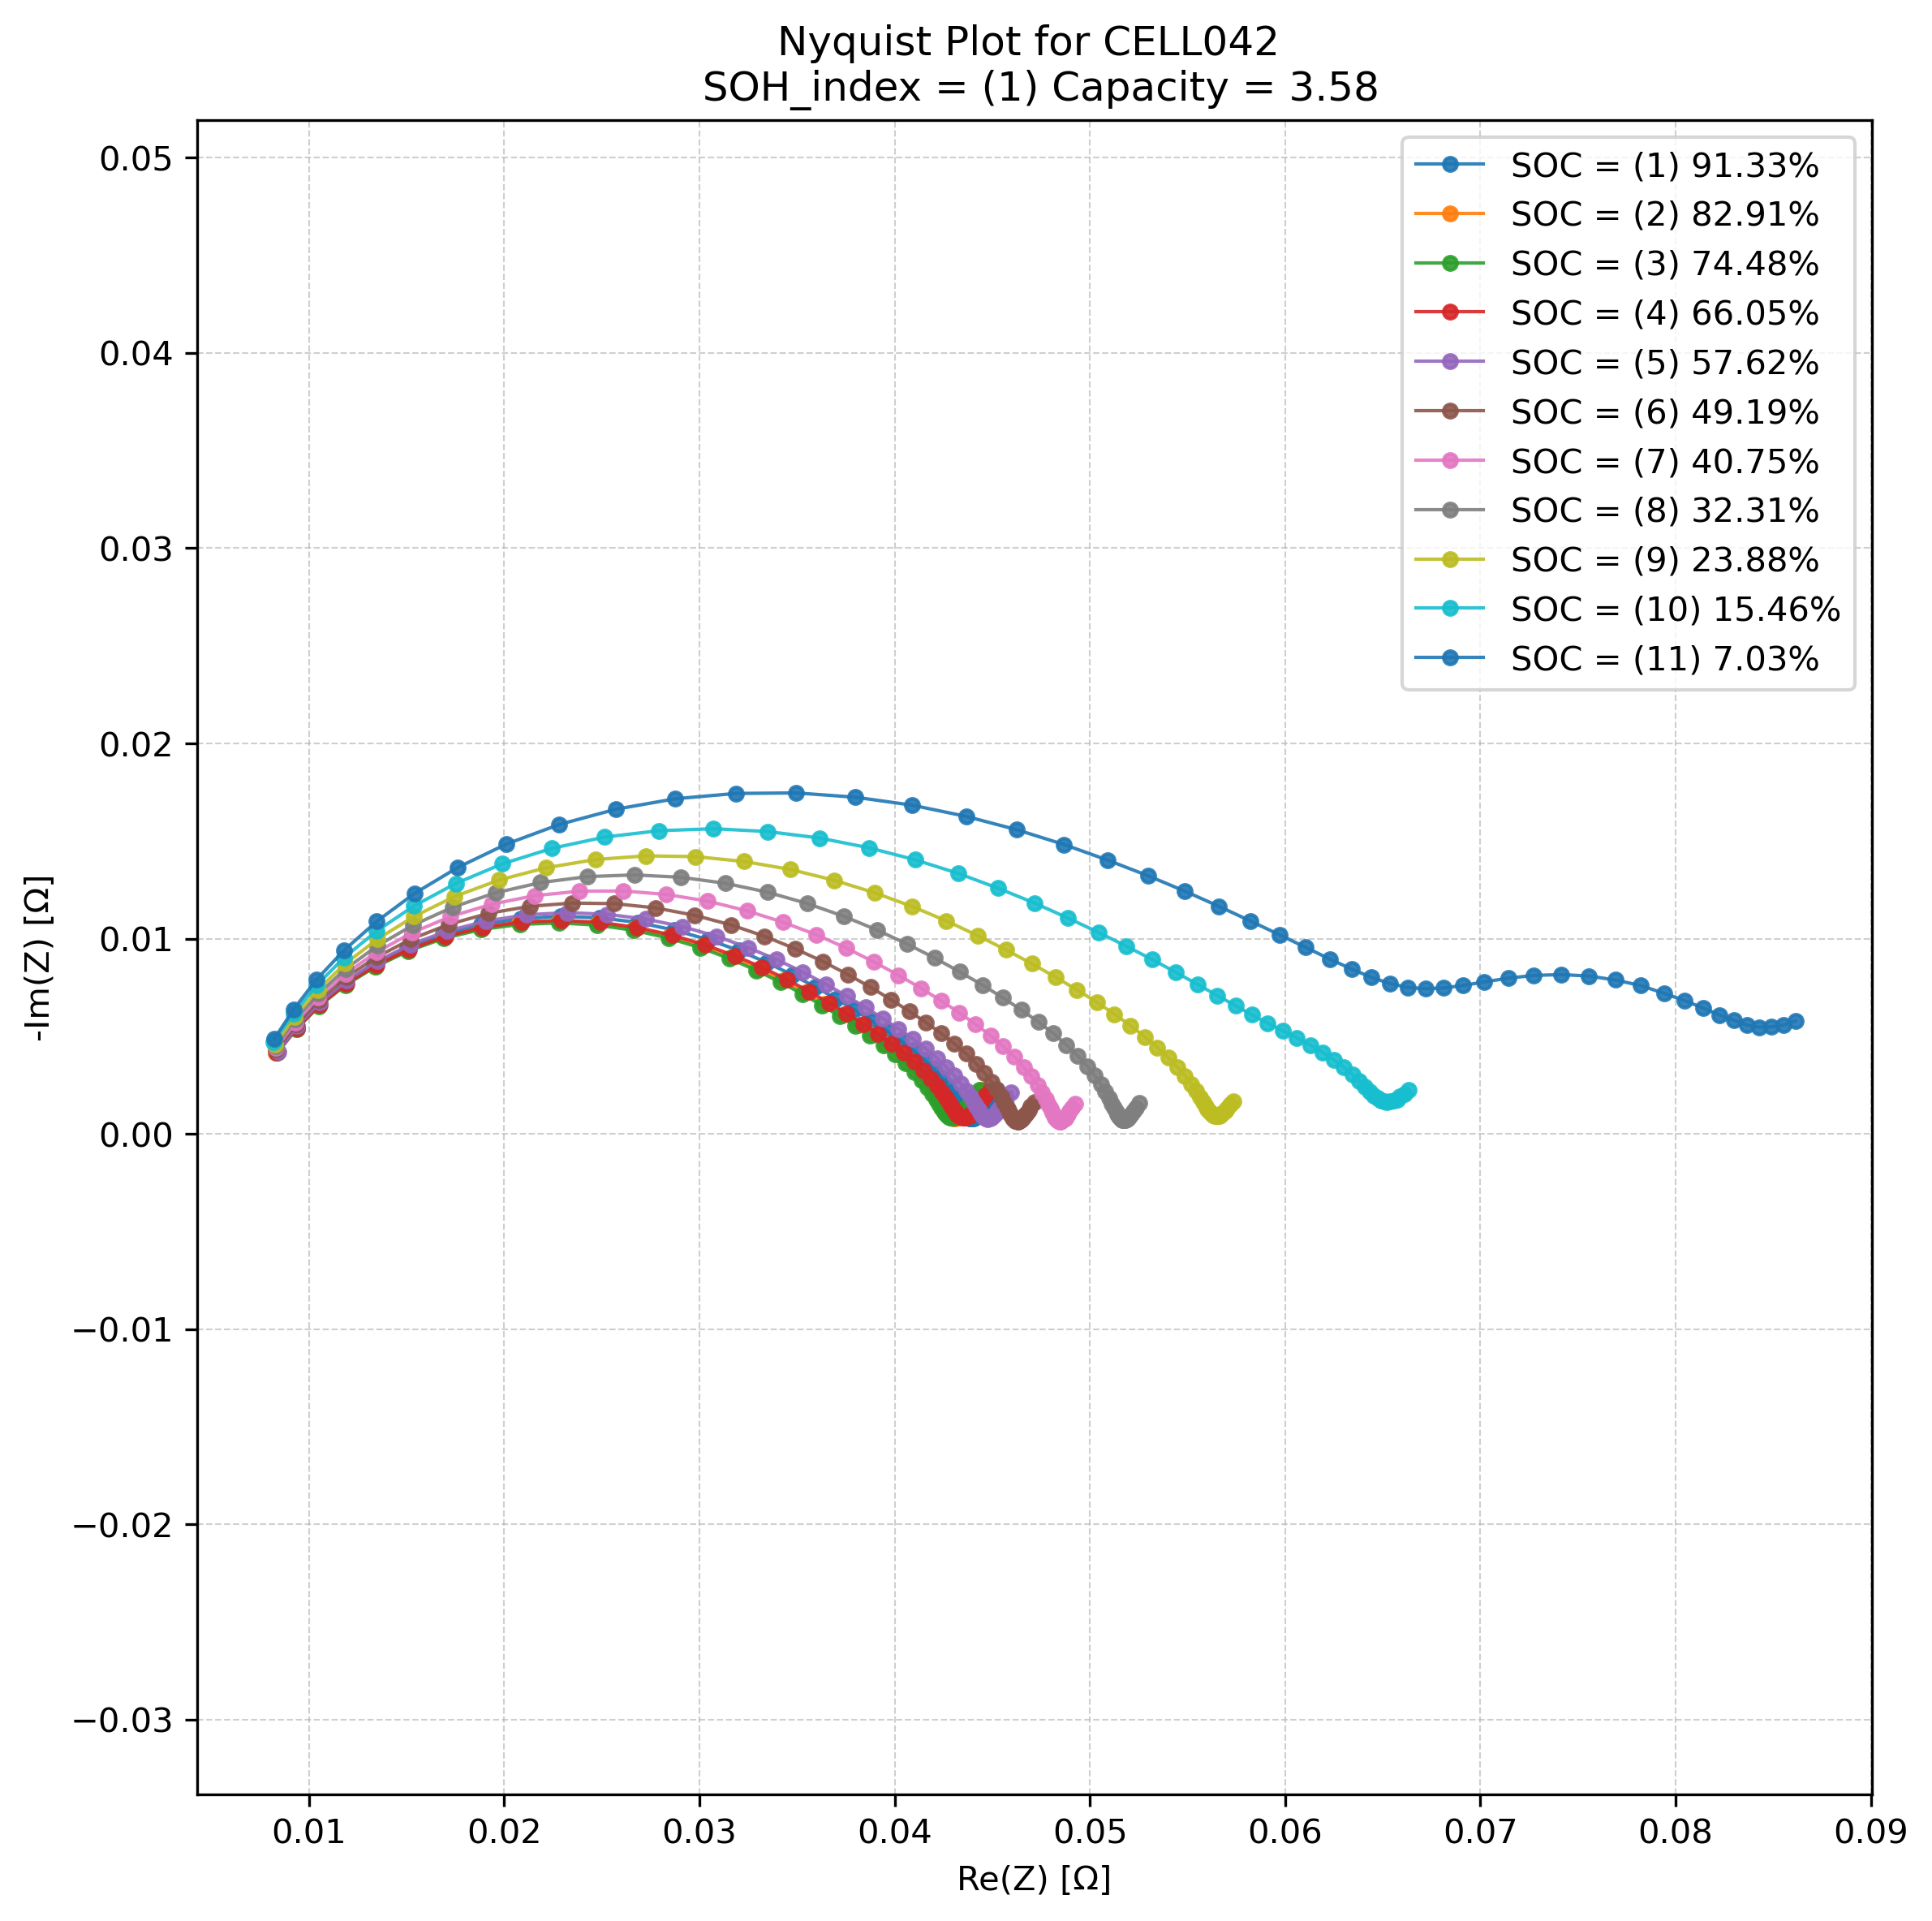

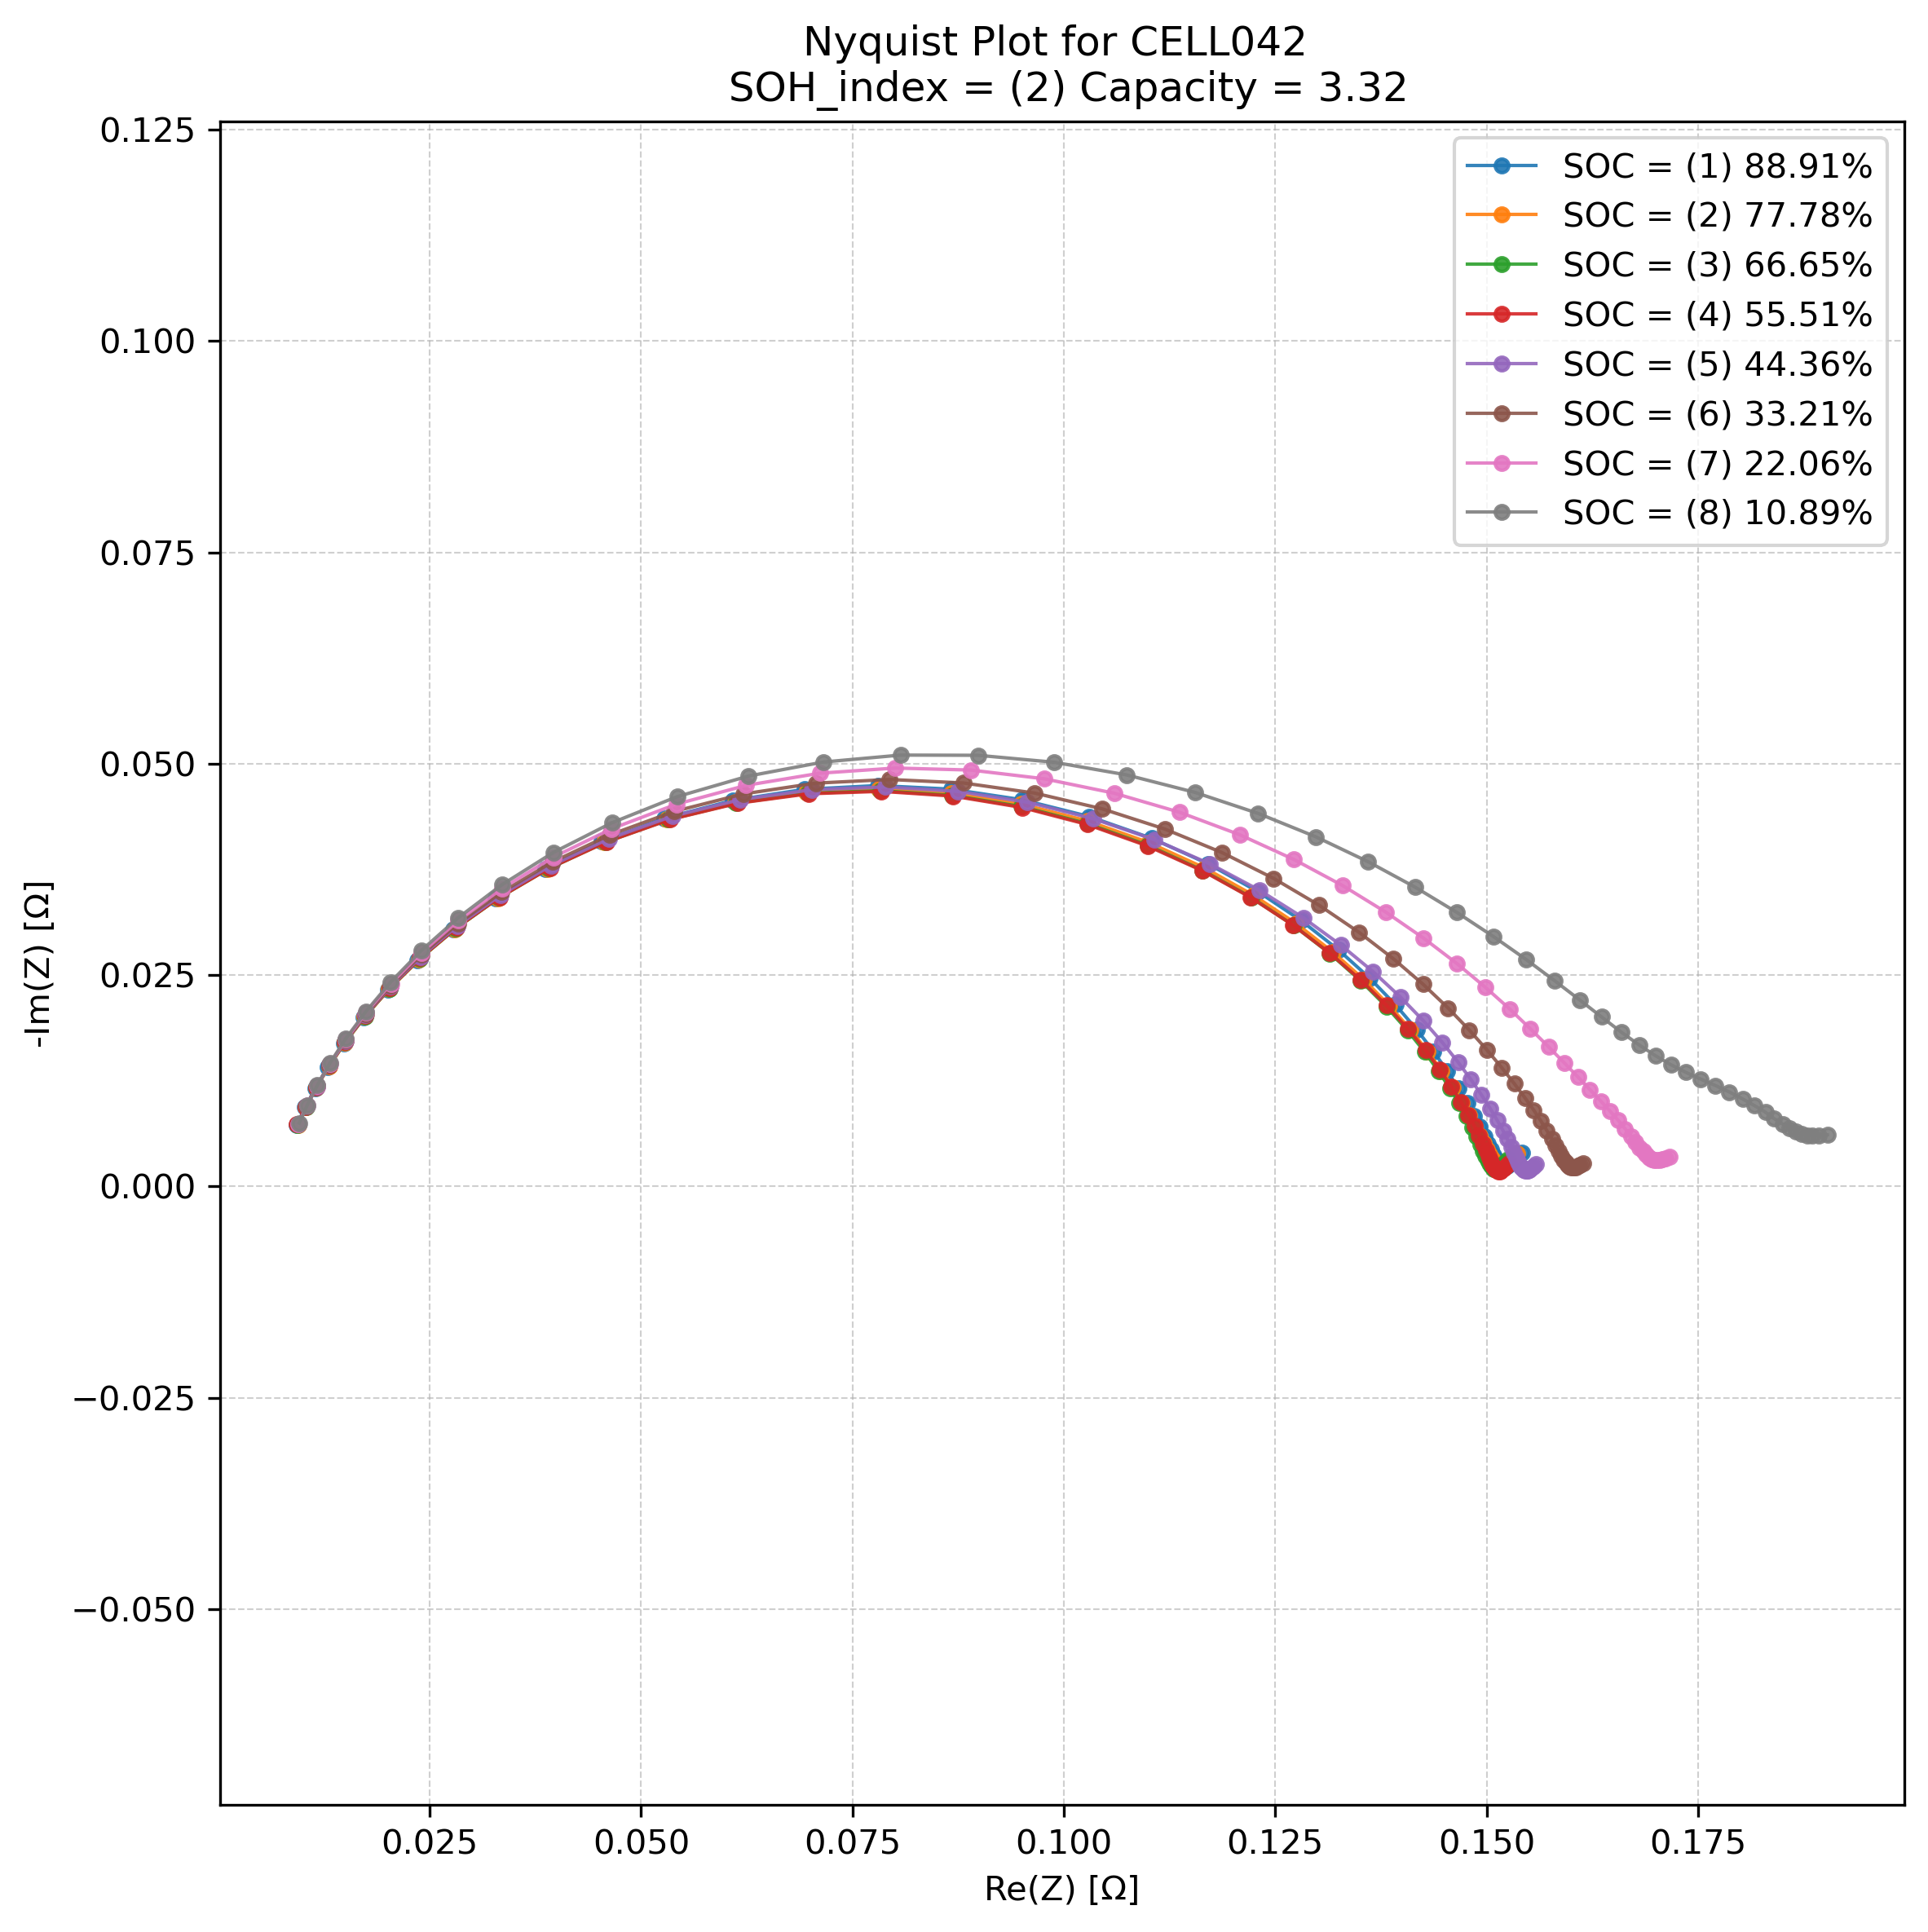

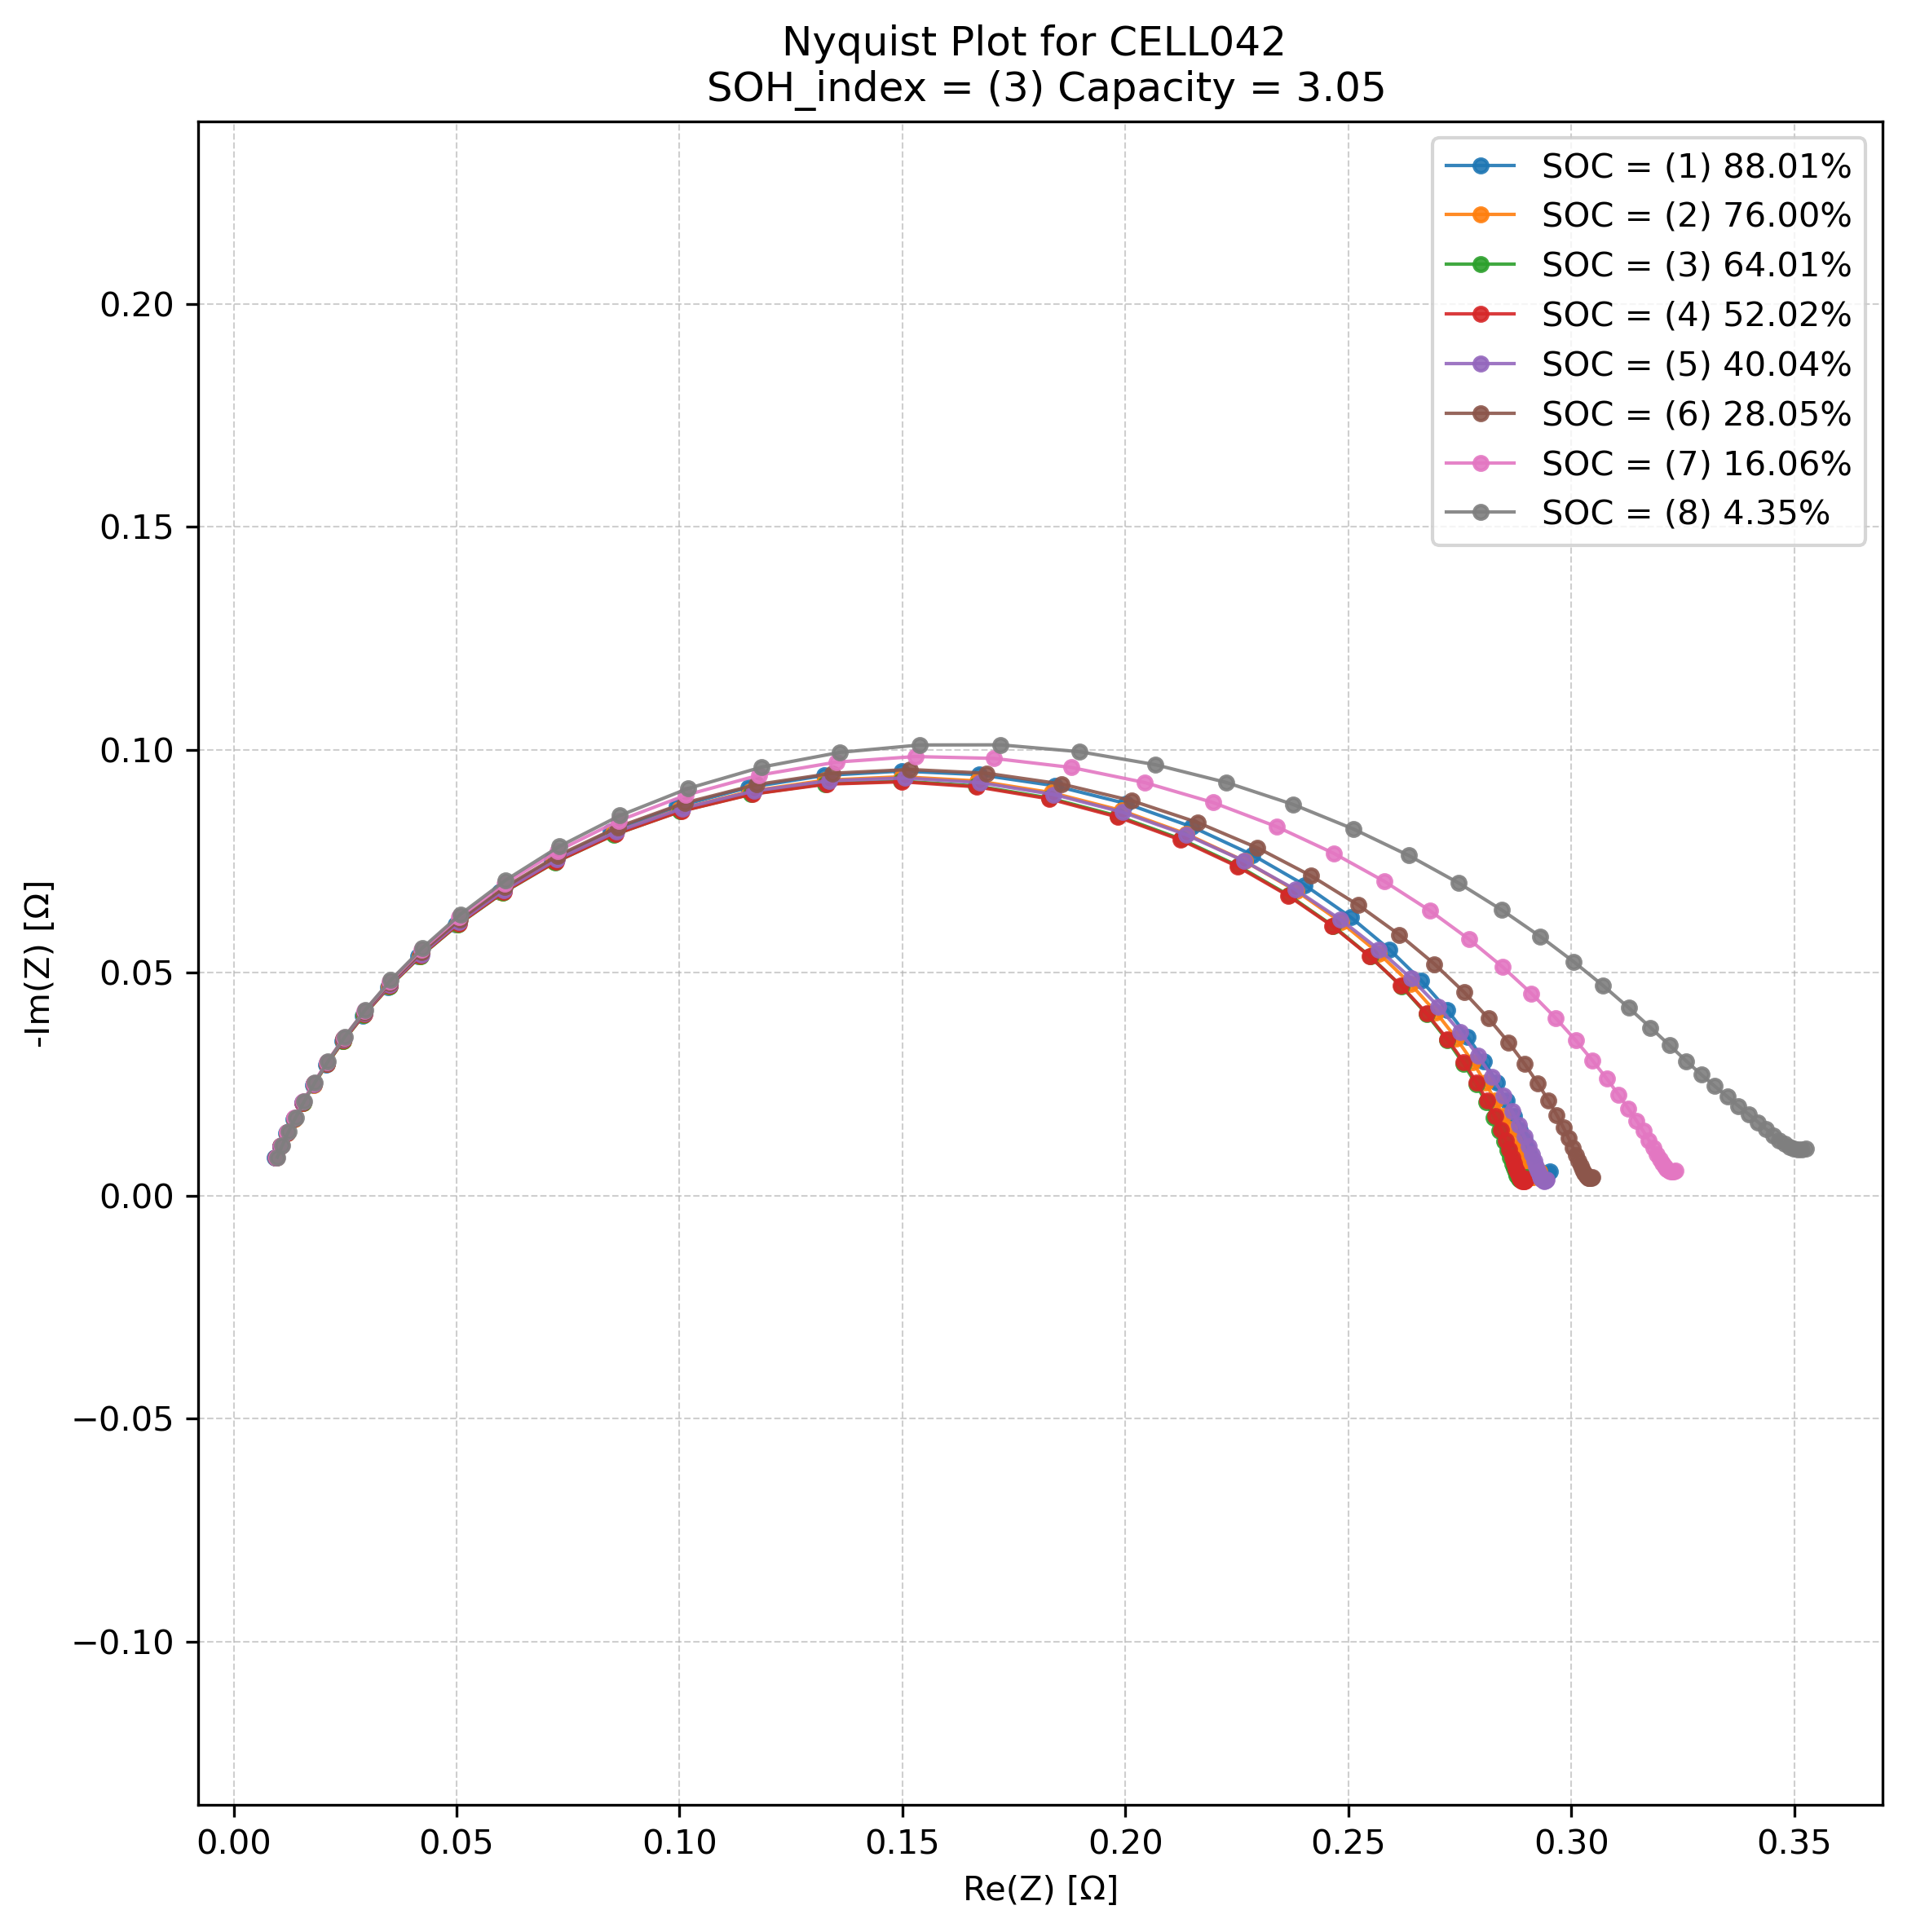

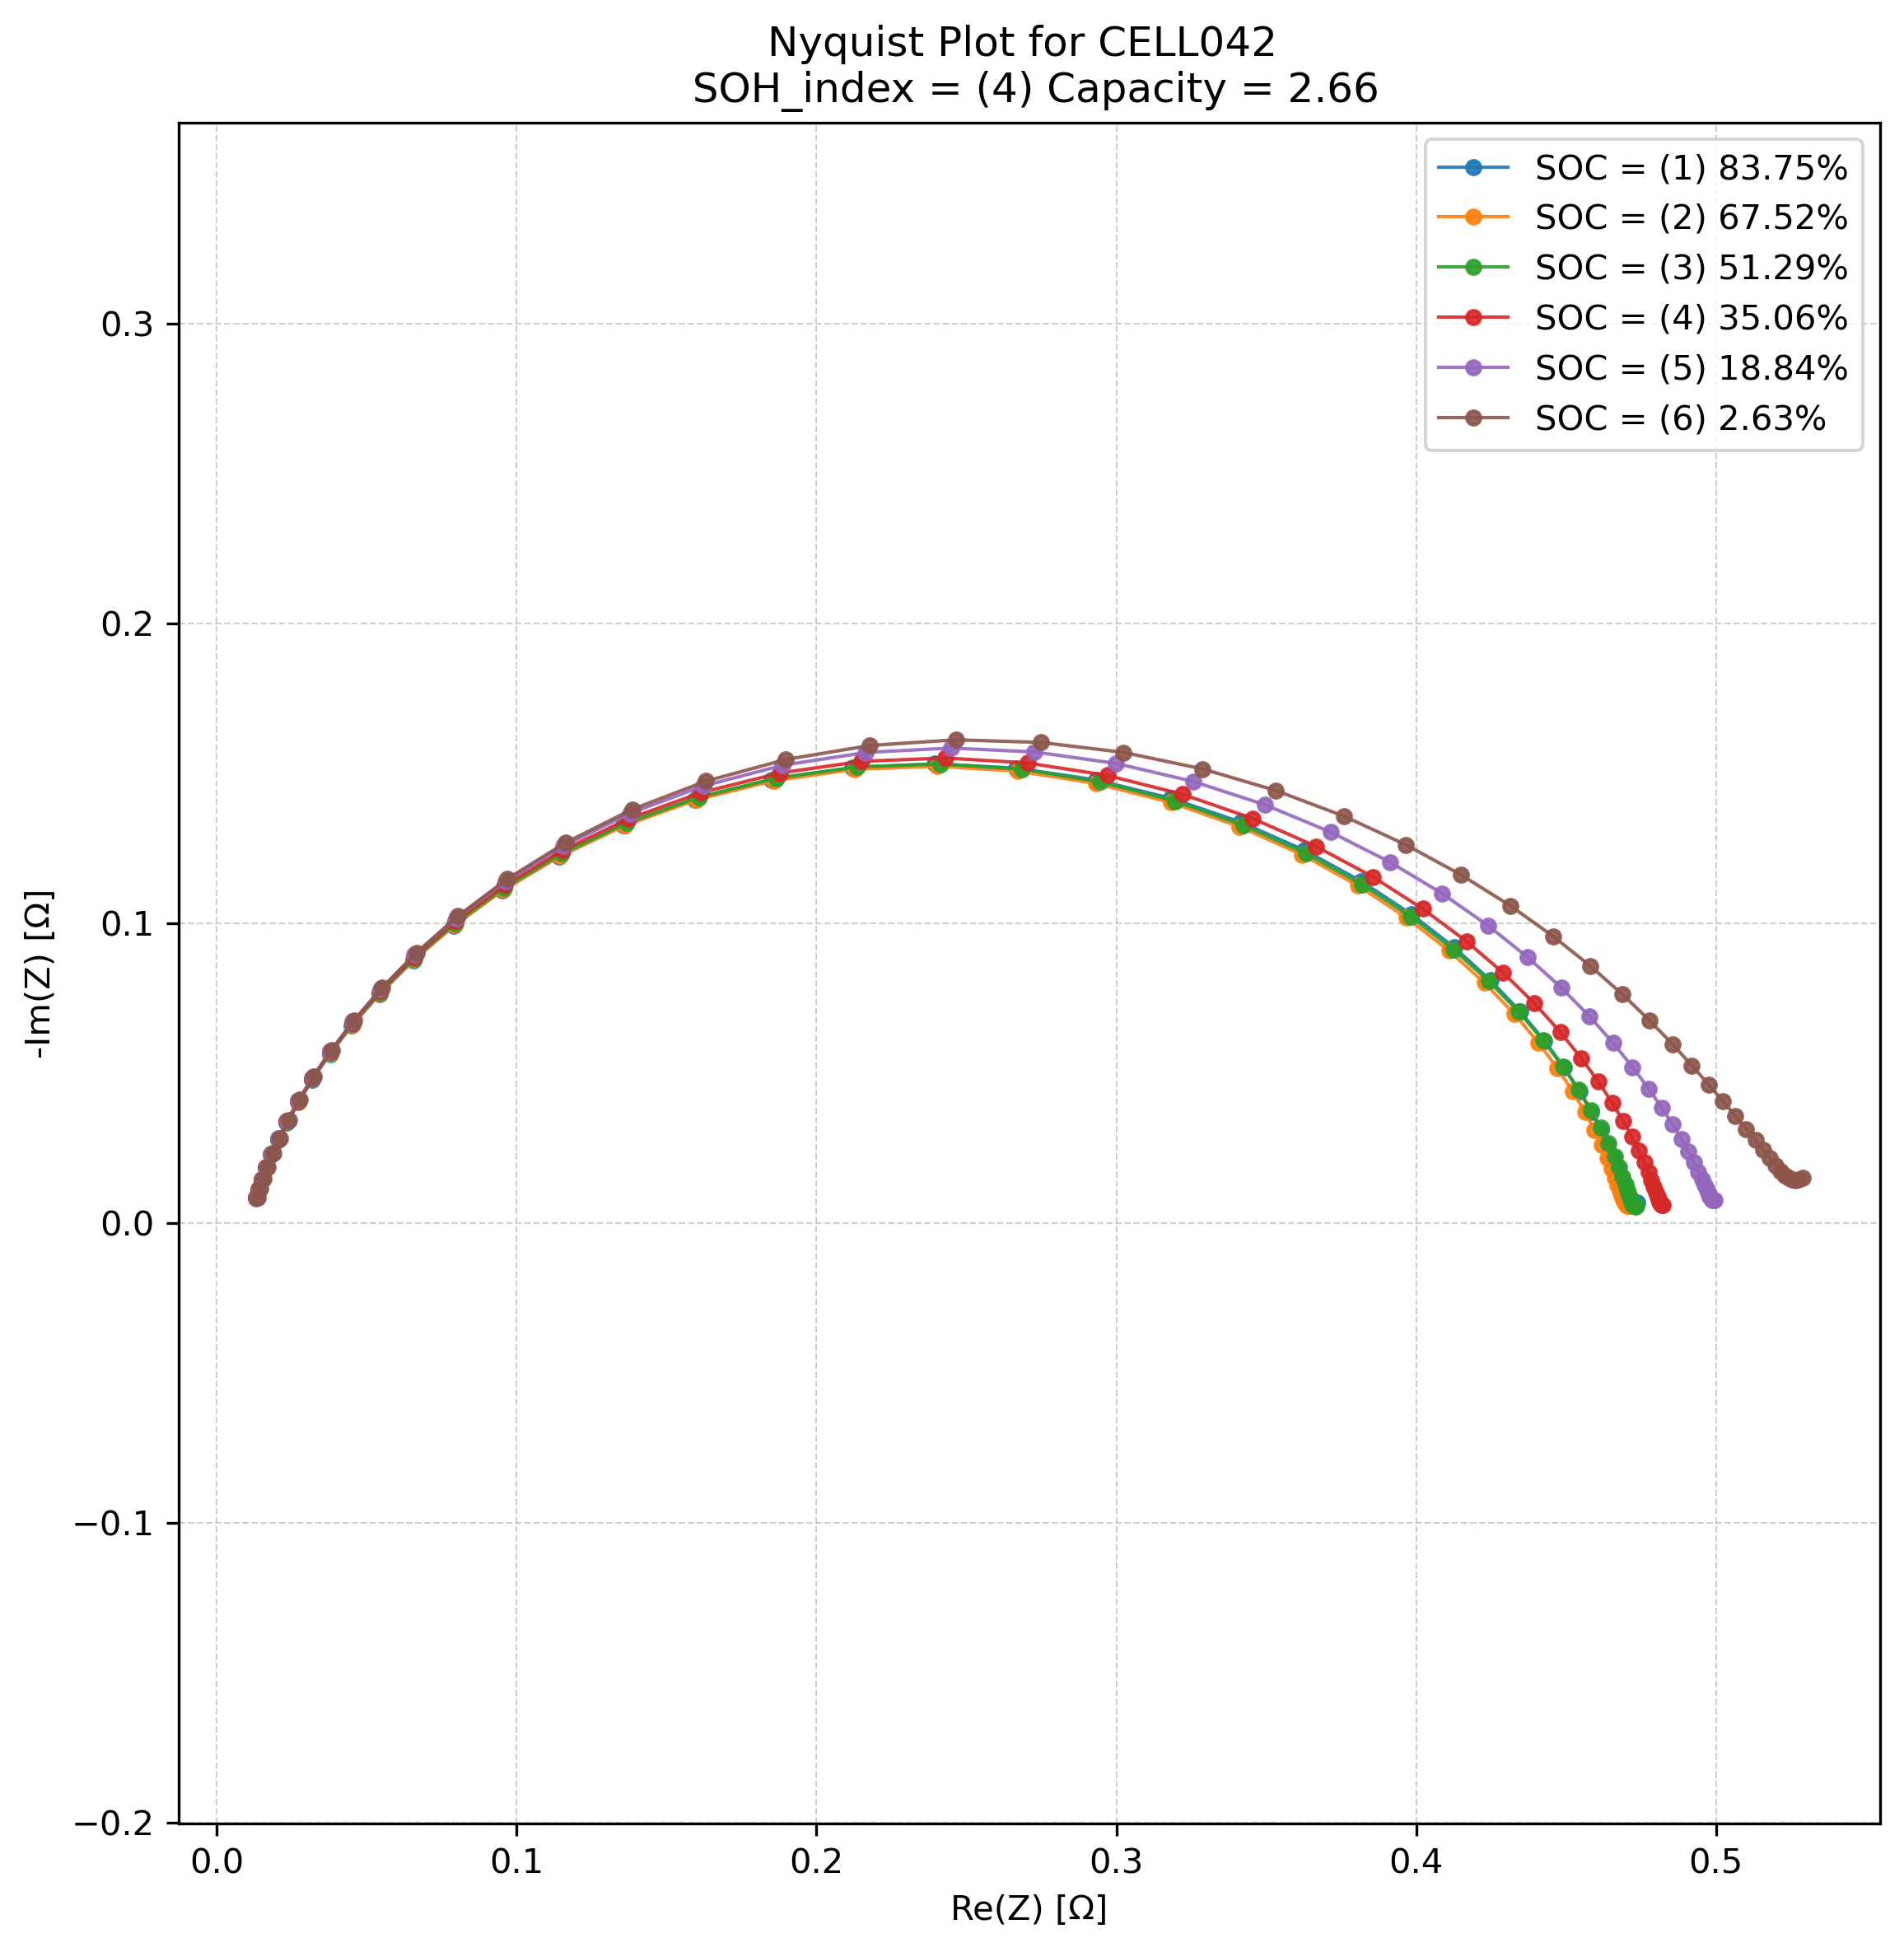

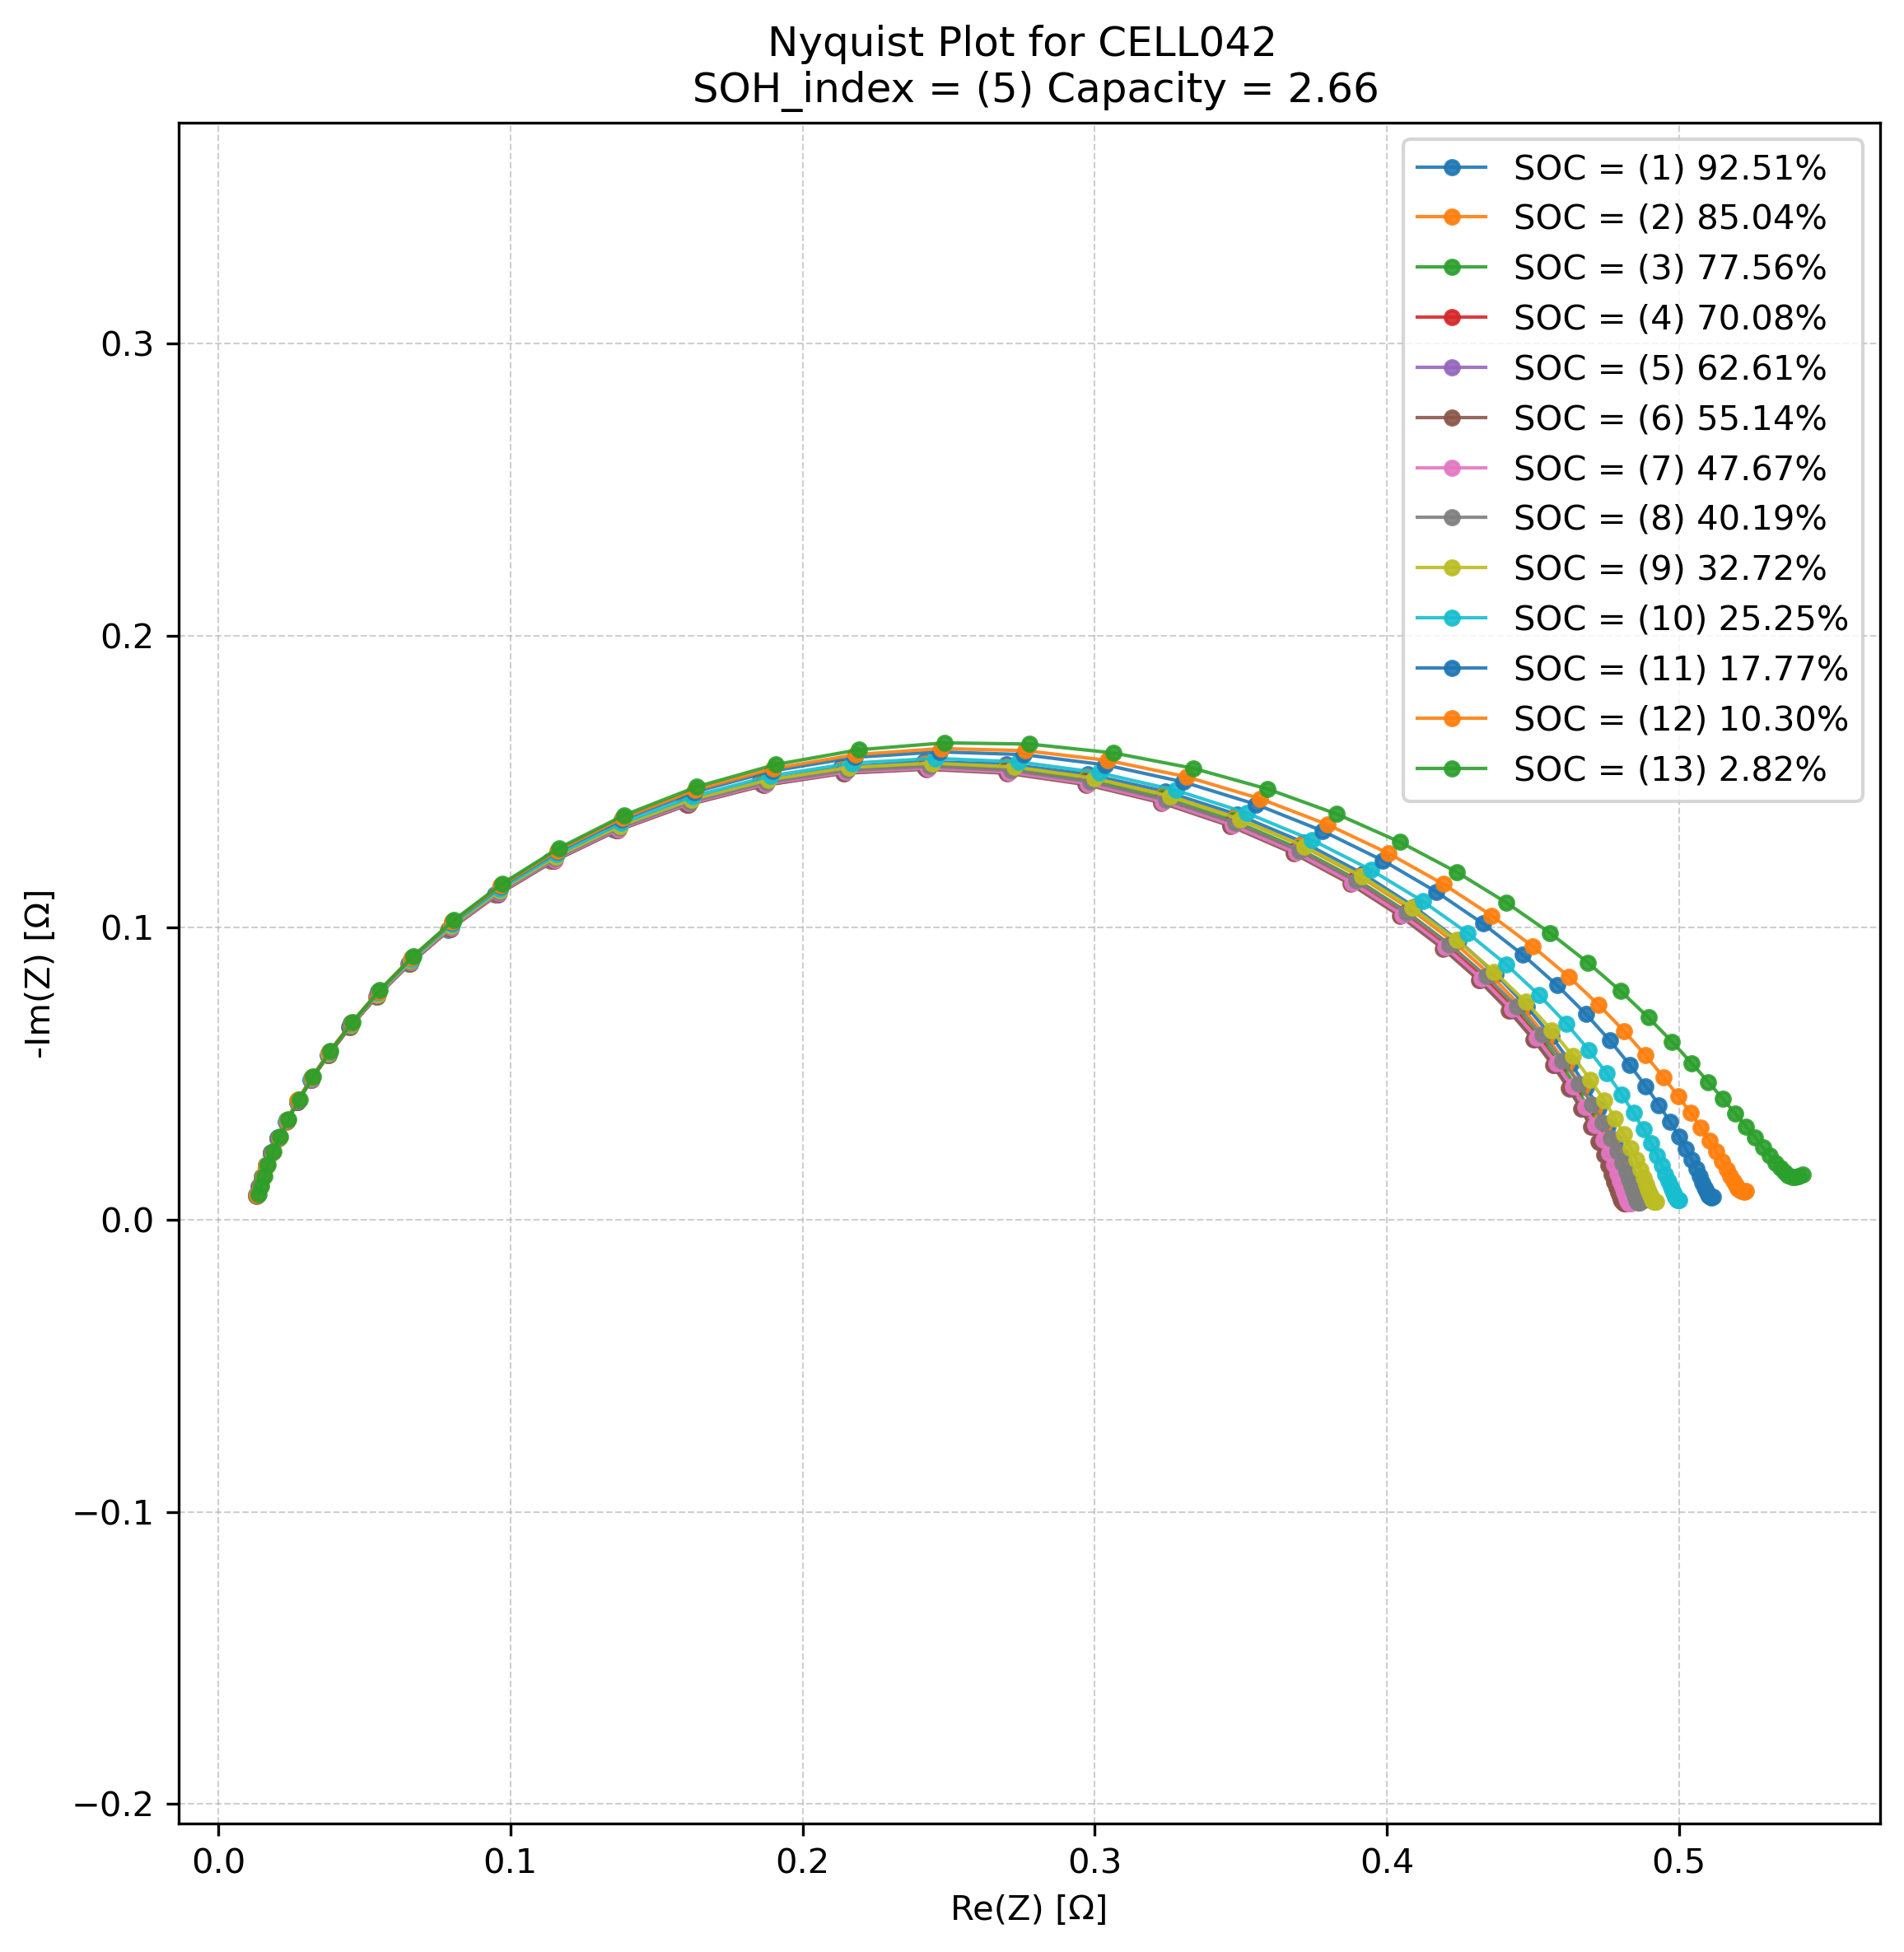

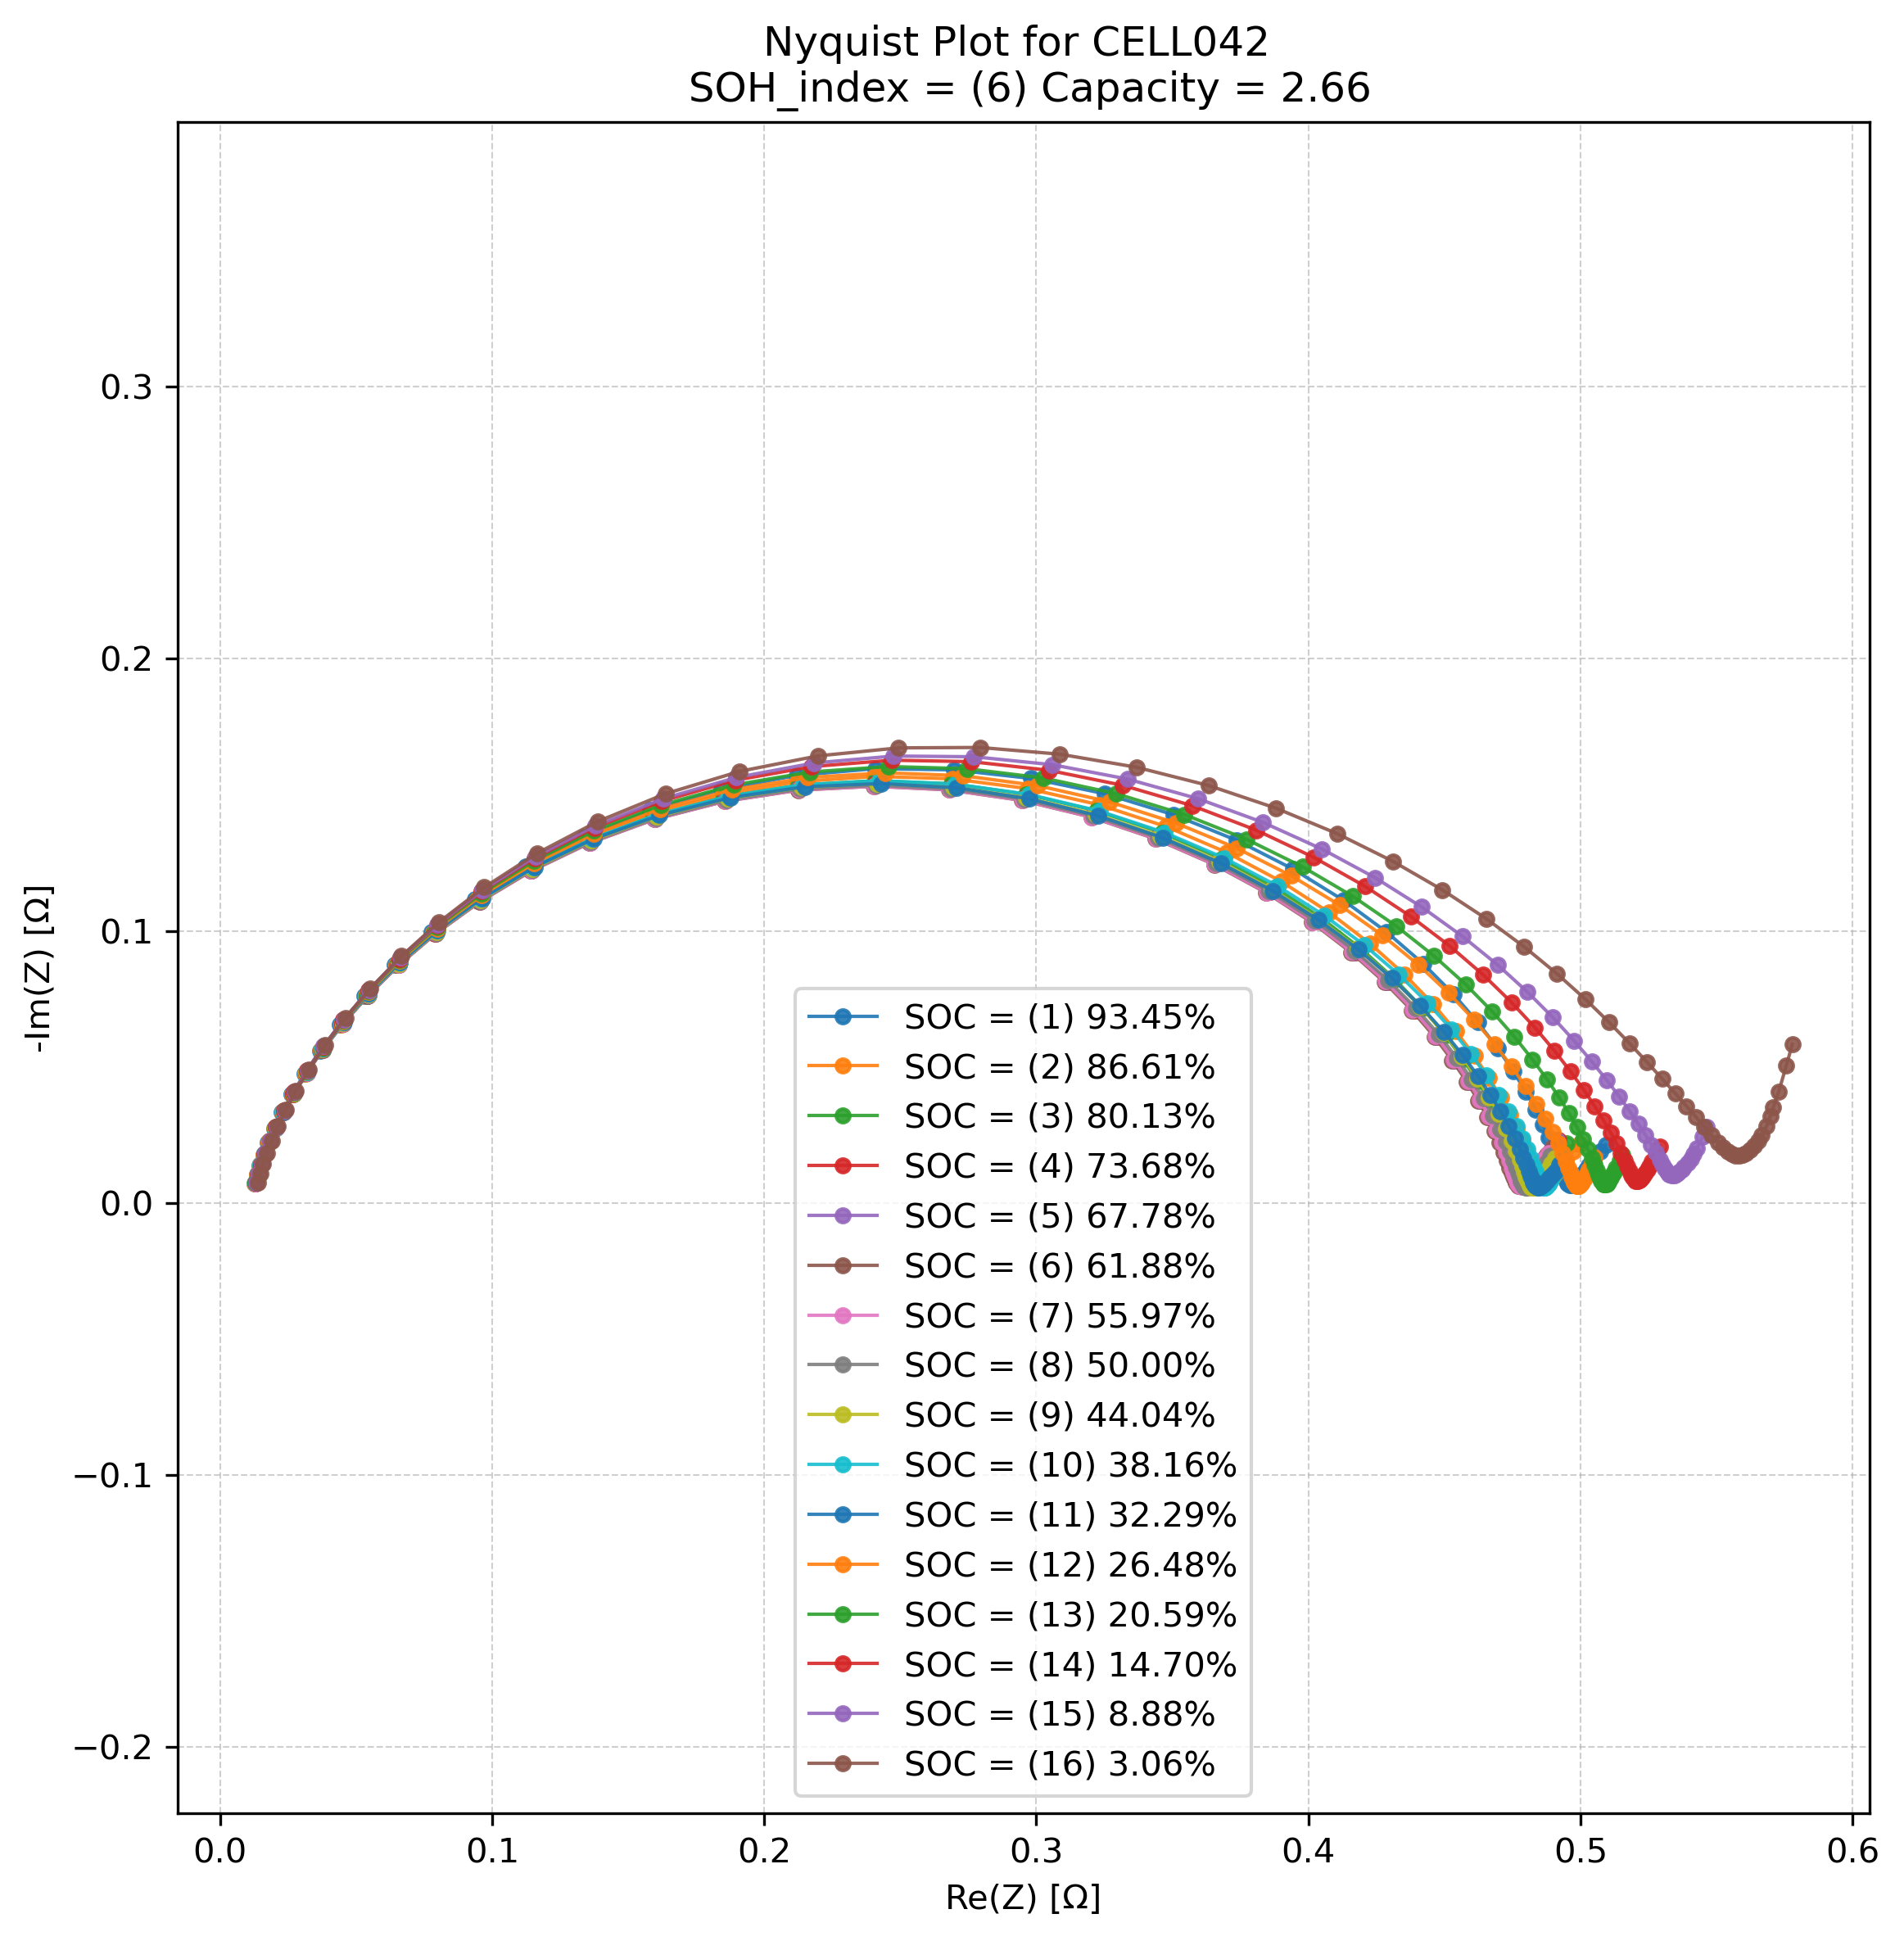

In [19]:
cell42_num_soh = cell42_metadata["num_soh"]

for soh_i in range(cell42_num_soh):
    num_soc = cell42_metadata["soh"][soh_i]["num_soc"]
    plot_input_list = [cell42_EISdata[soh_i][soc_i] for soc_i in range(num_soc)]
    plot_title = f"Nyquist Plot for CELL042 \n SOH_index = ({soh_i+1}) Capacity = {cell42_metadata["soh"][soh_i]["capacity"]:.2f}"
    labels = [f"SOC = ({soc_i+1}) {cell42_metadata["soh"][soh_i]["soc"][soc_i]*100:.2f}%" for soc_i in range(num_soc)]
    fig, ax = plot_EIS_Nyquist_multi(plot_input_list, labels, title=plot_title)
    plt.show()
        

#### ECM Fitting Algo

In [ ]:
ECM_parameter_estimation("v3CM9", "CELL042", cell42_metadata, cell42_EISdata, cost_func_name="RMSE_abs", trial_number=50)

#### Best Estimation Per Parameter Analysis

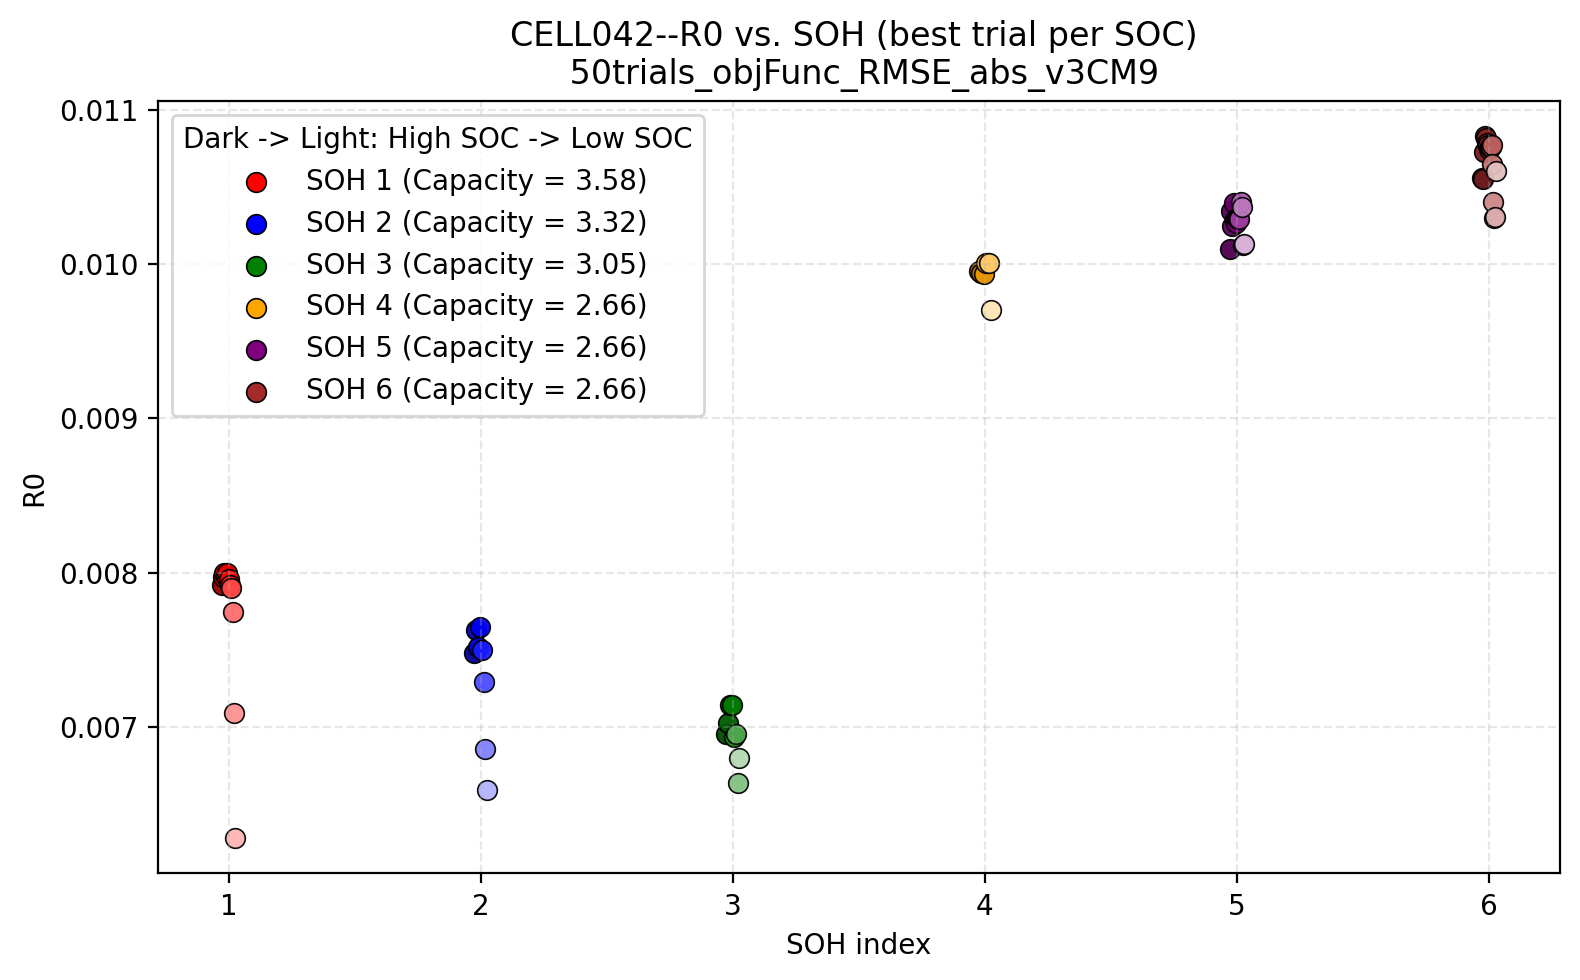

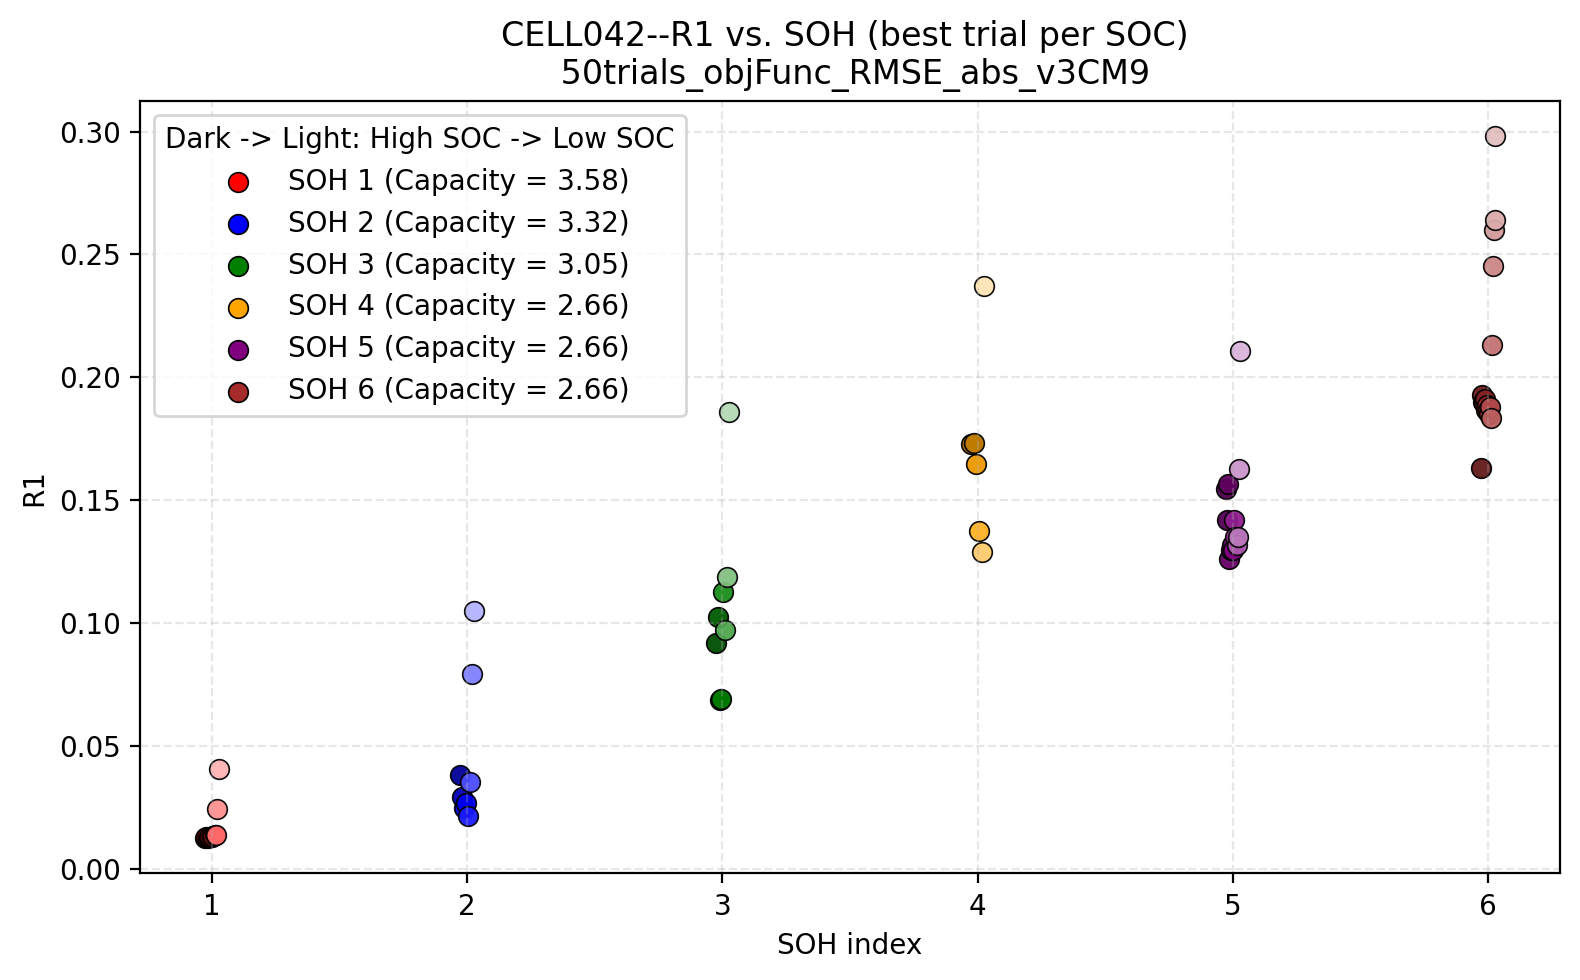

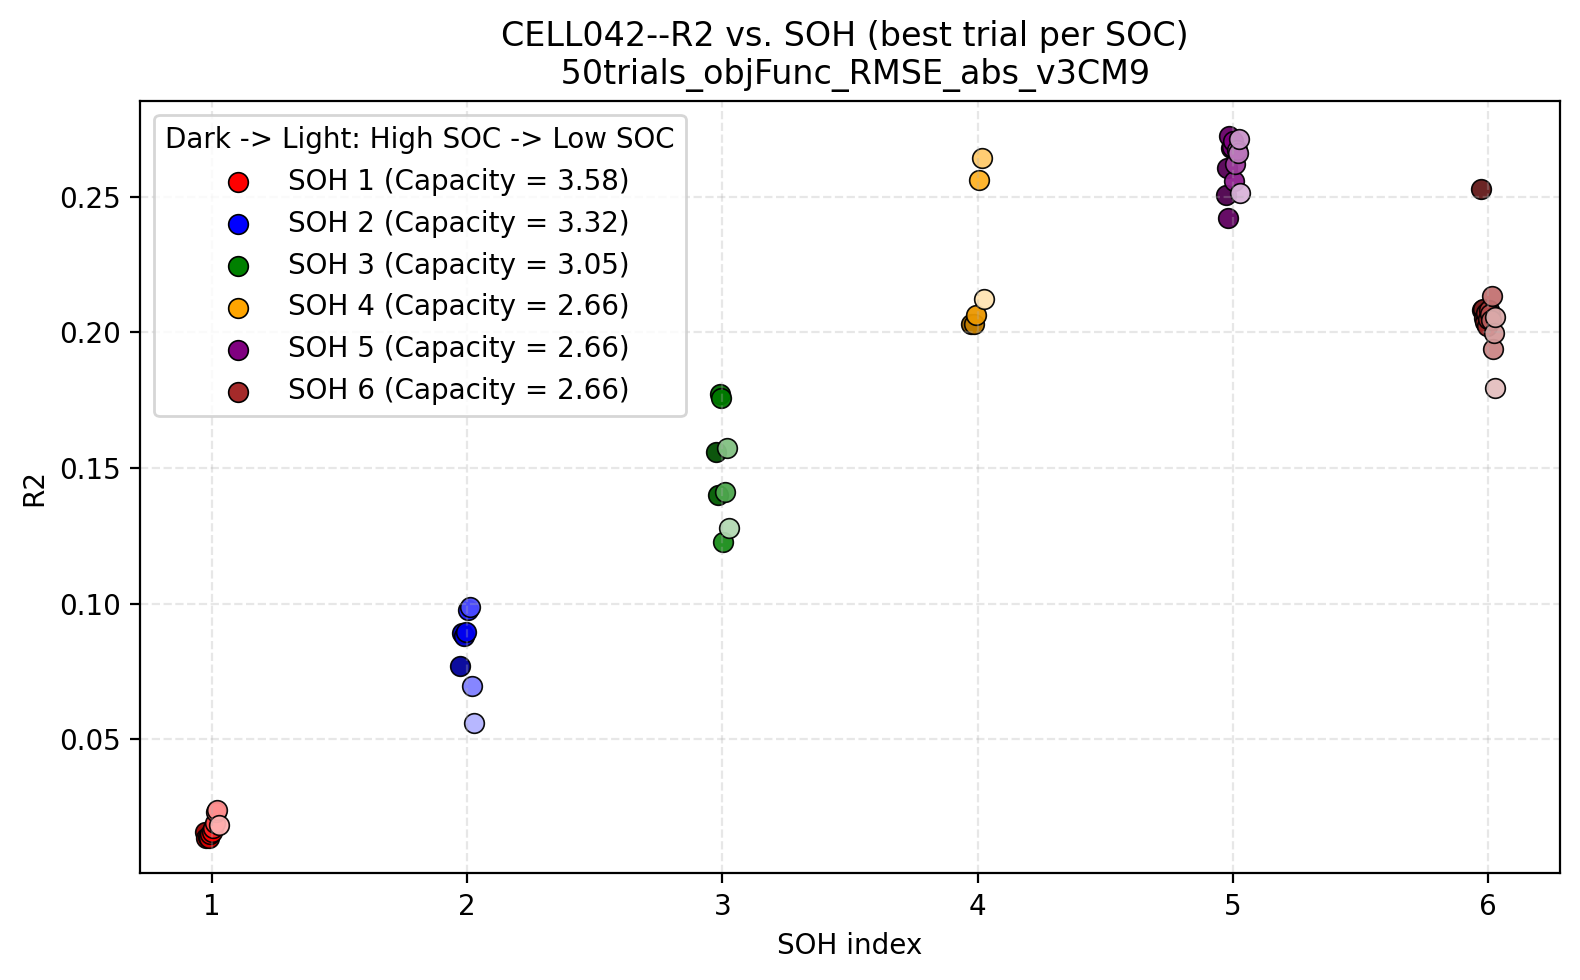

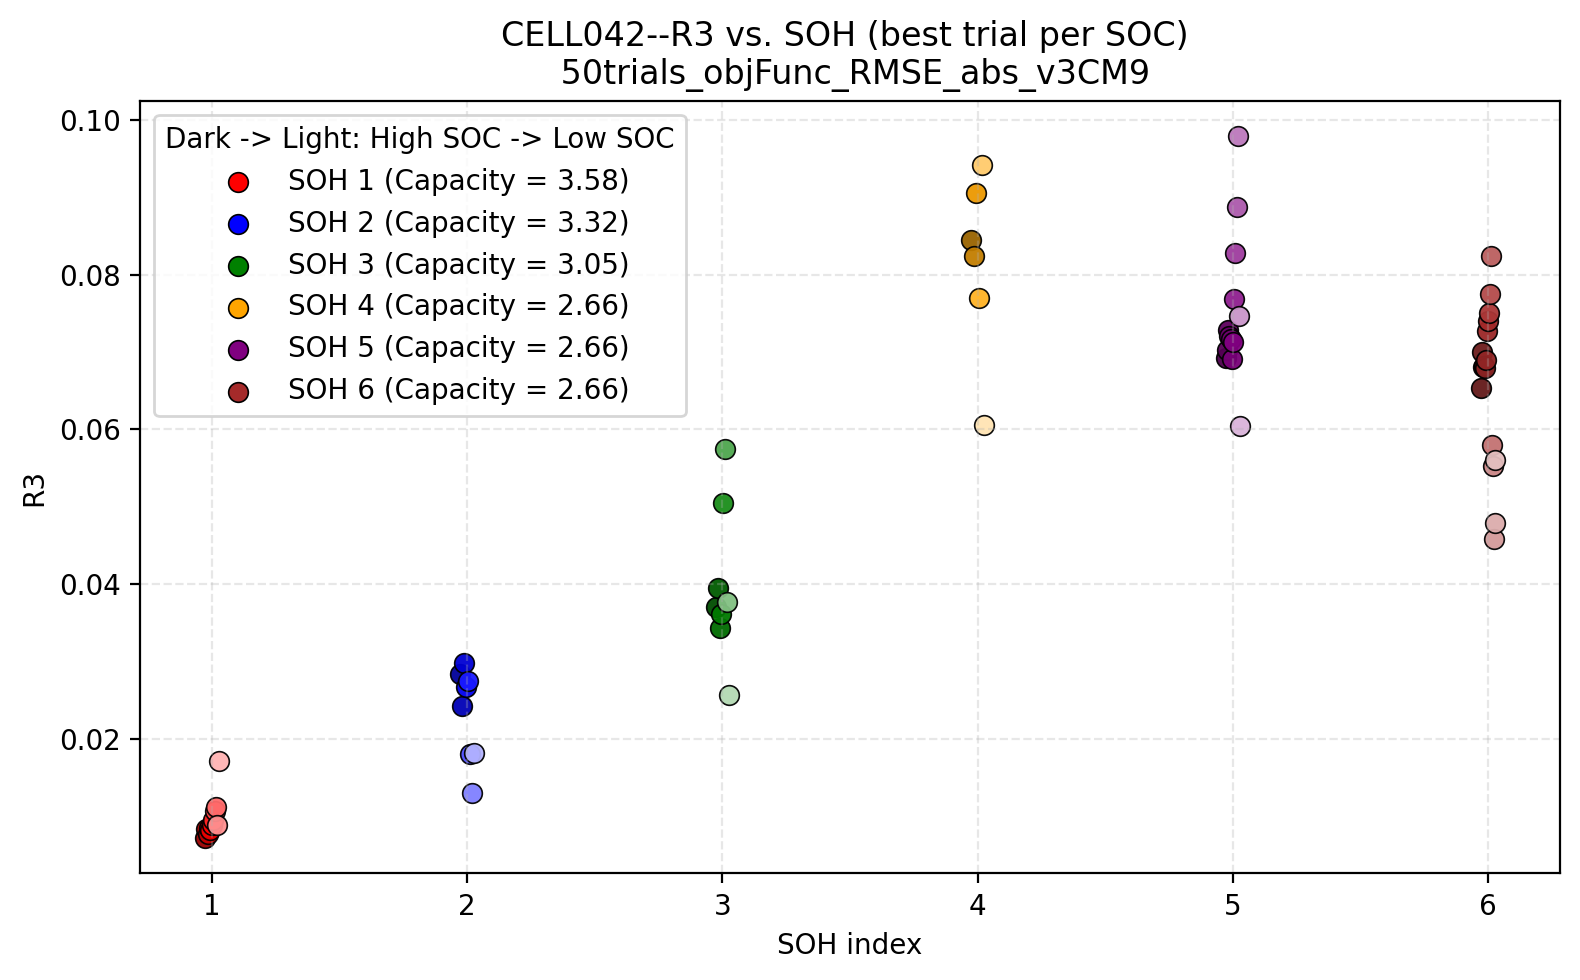

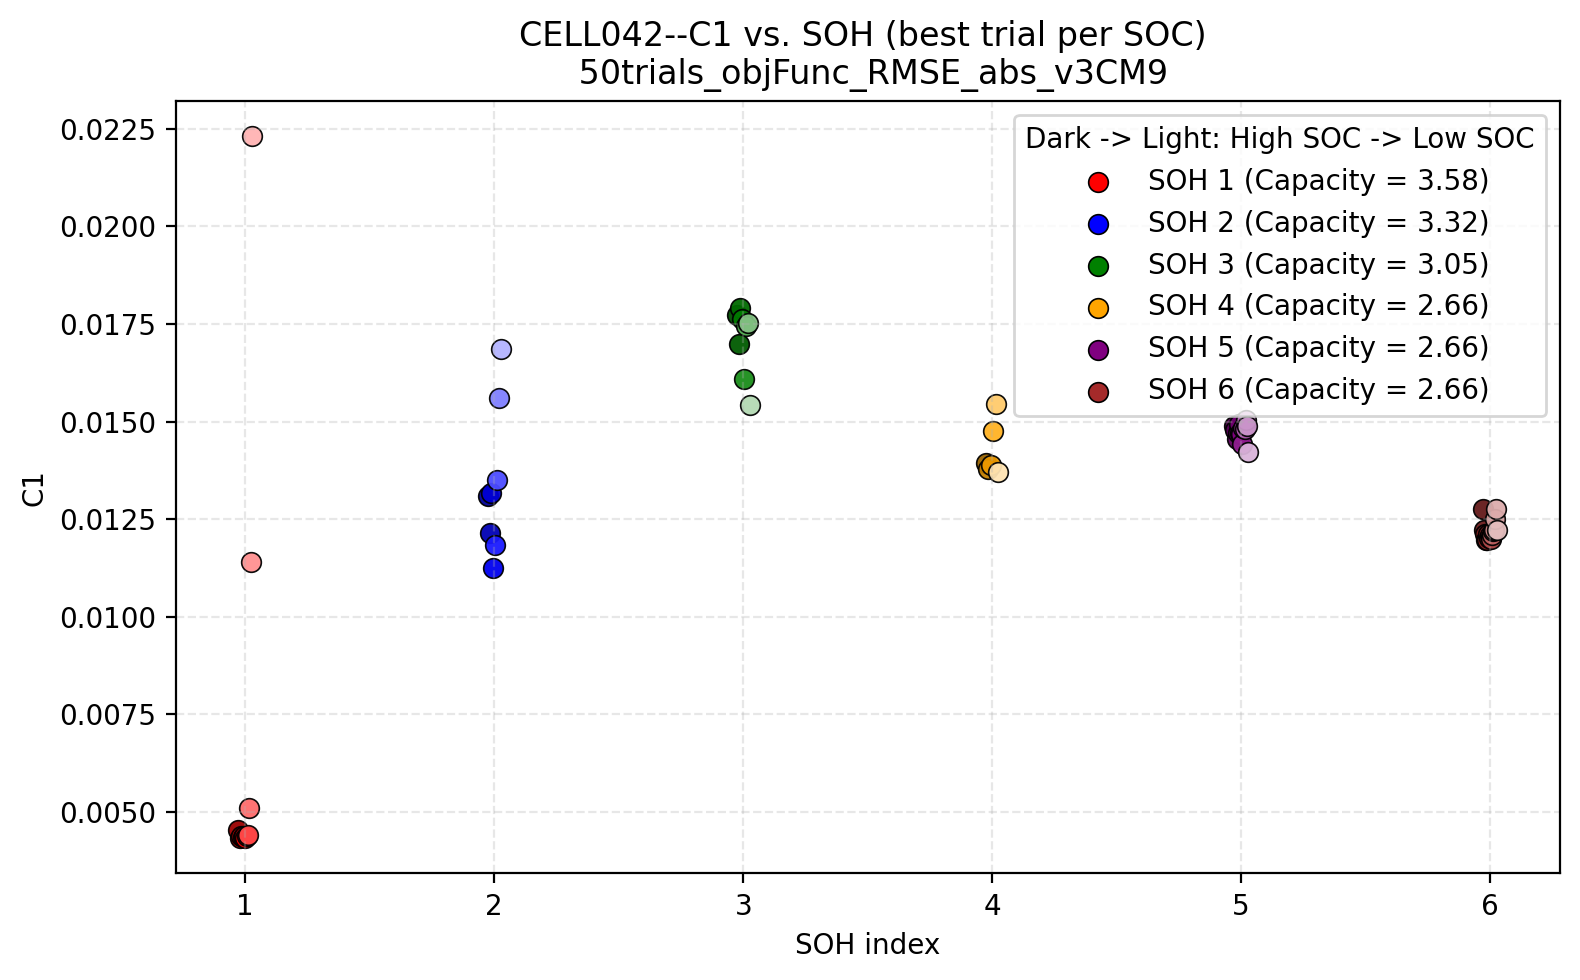

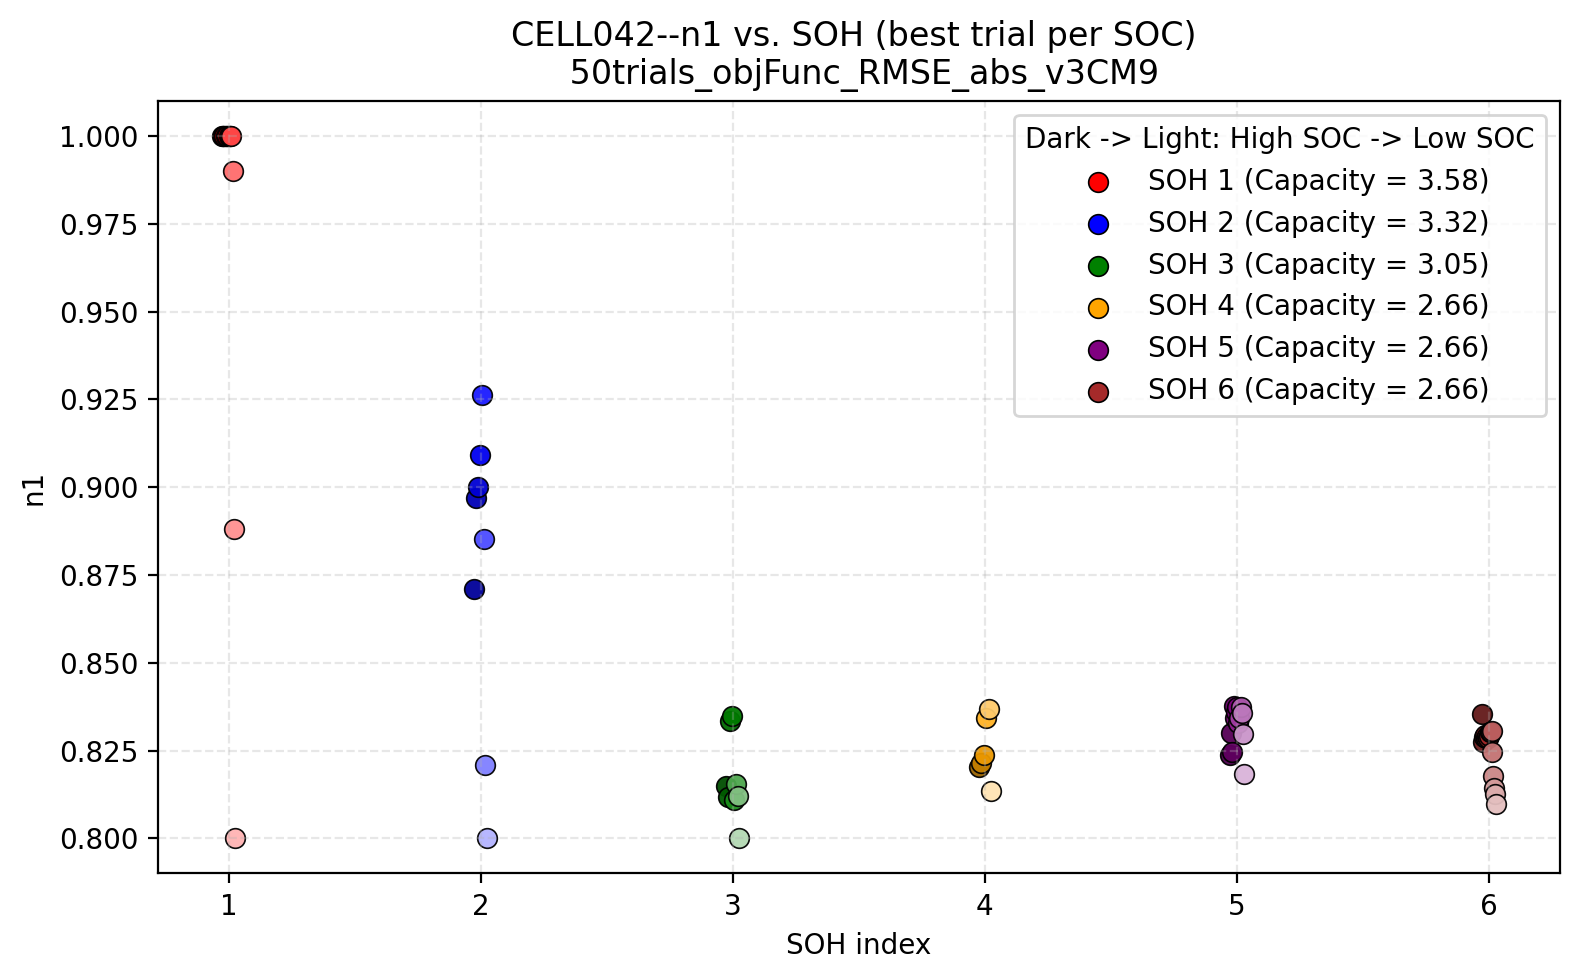

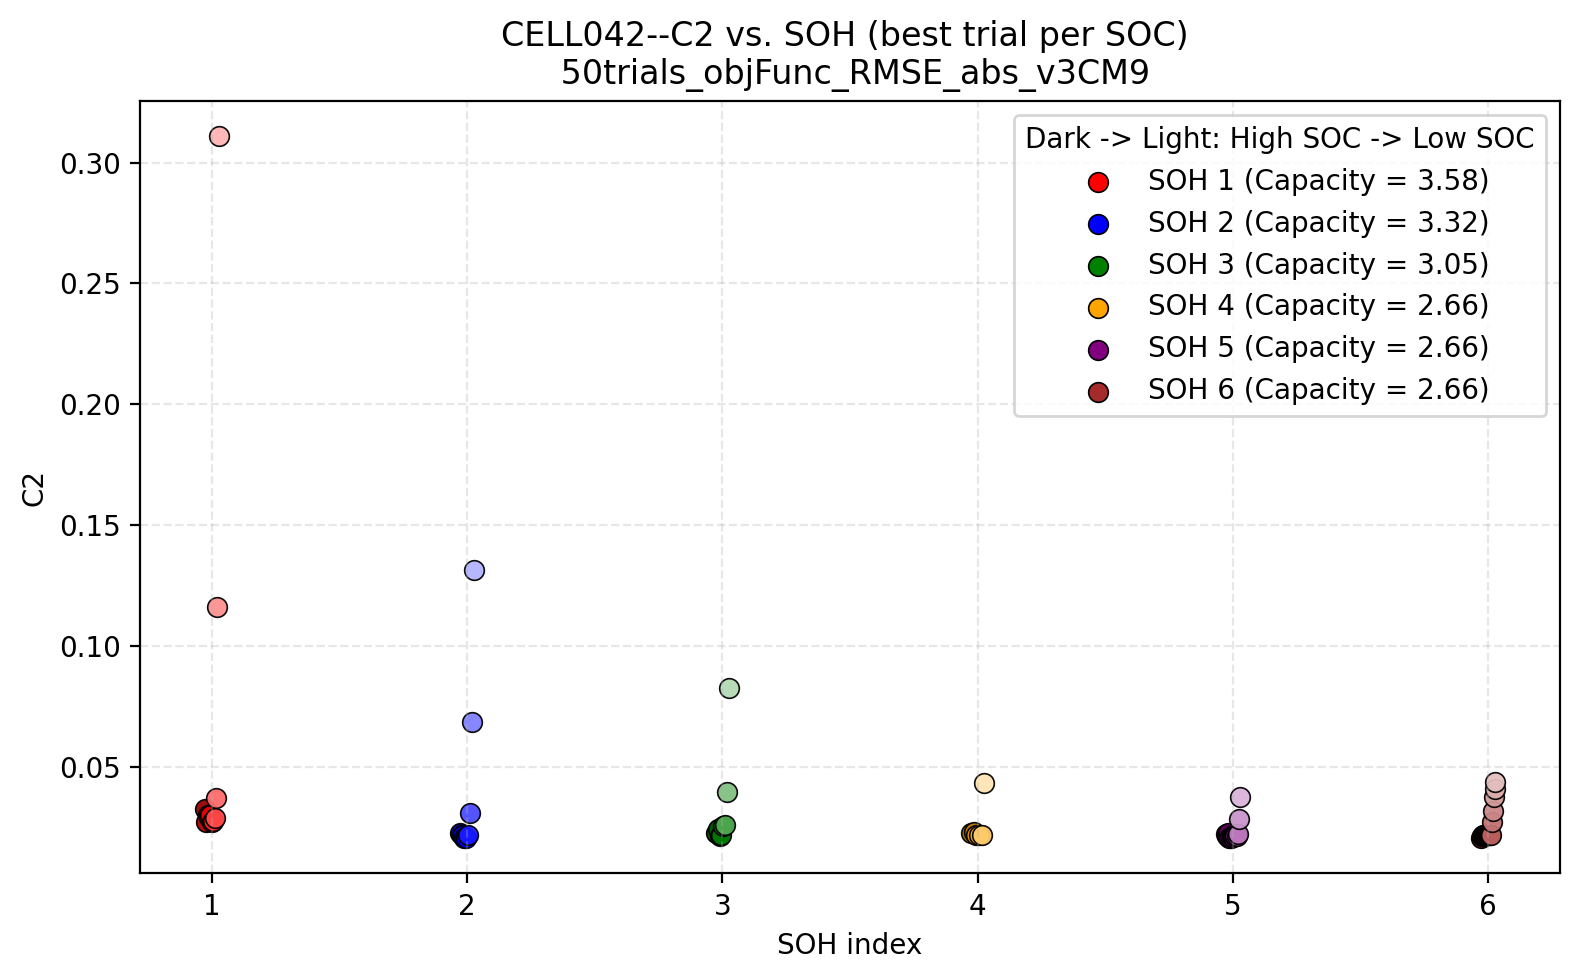

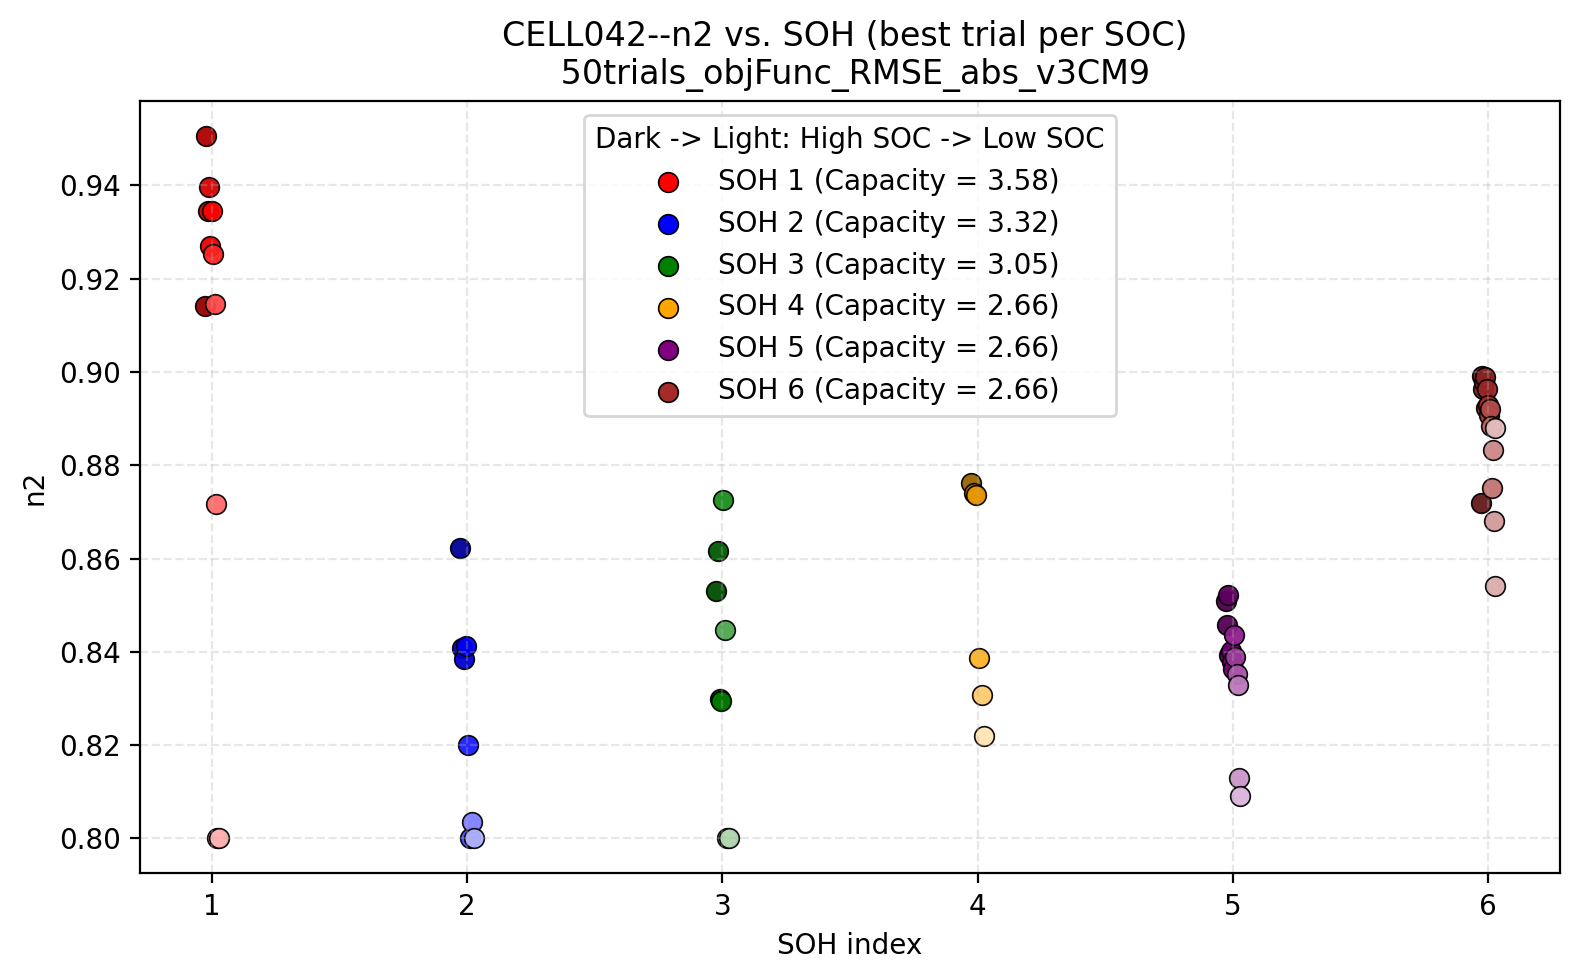

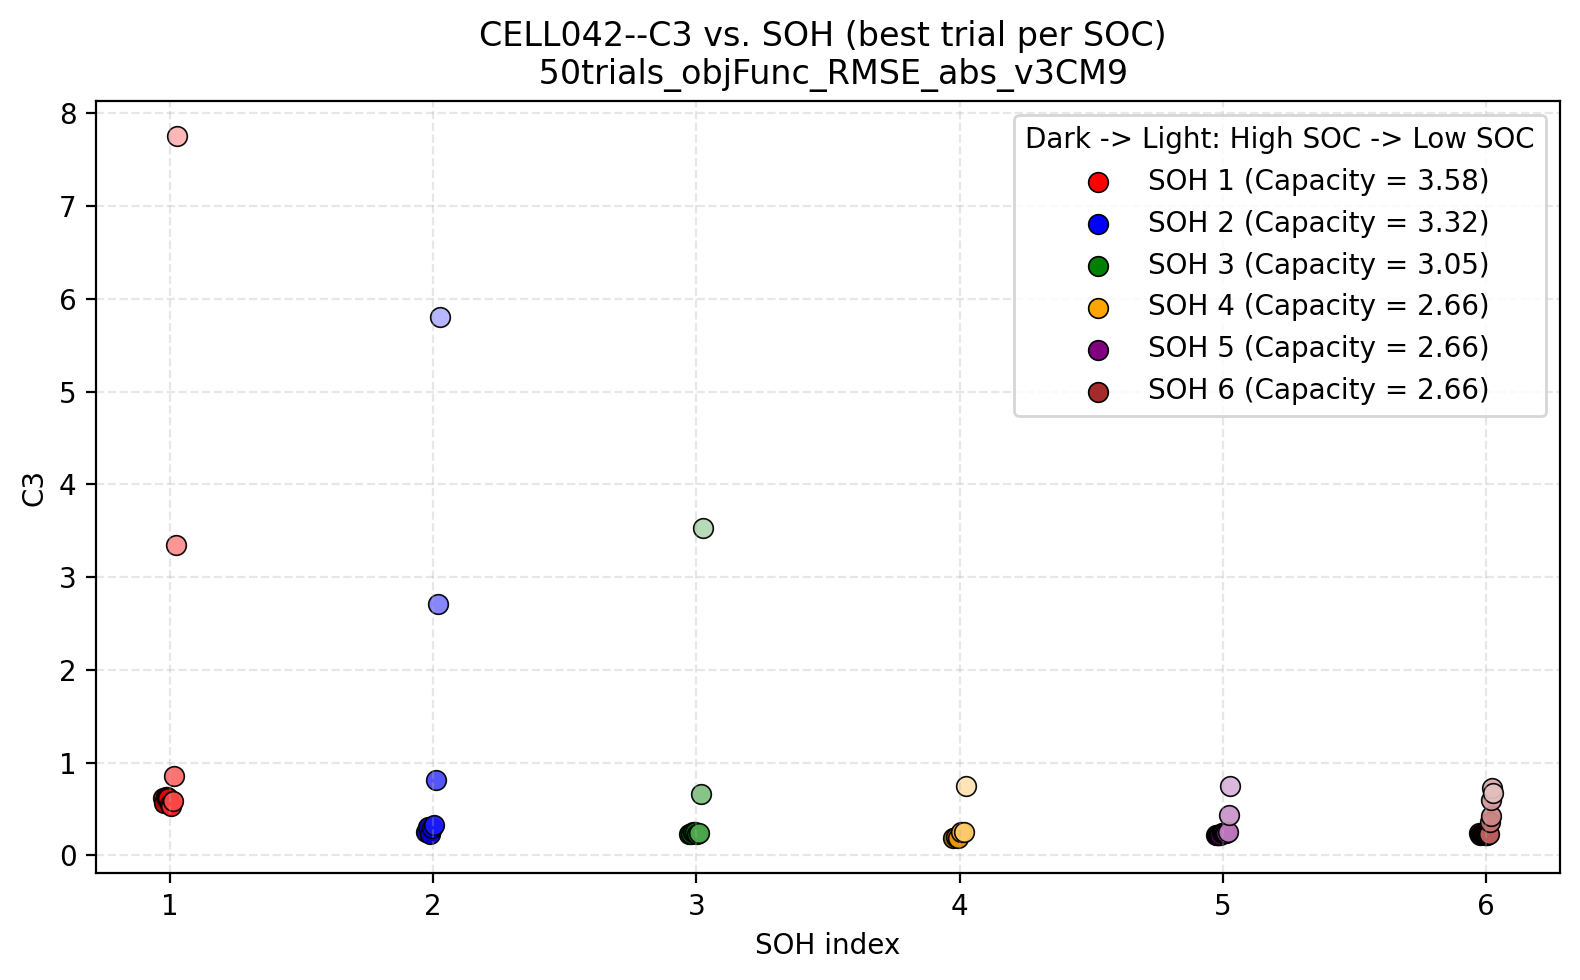

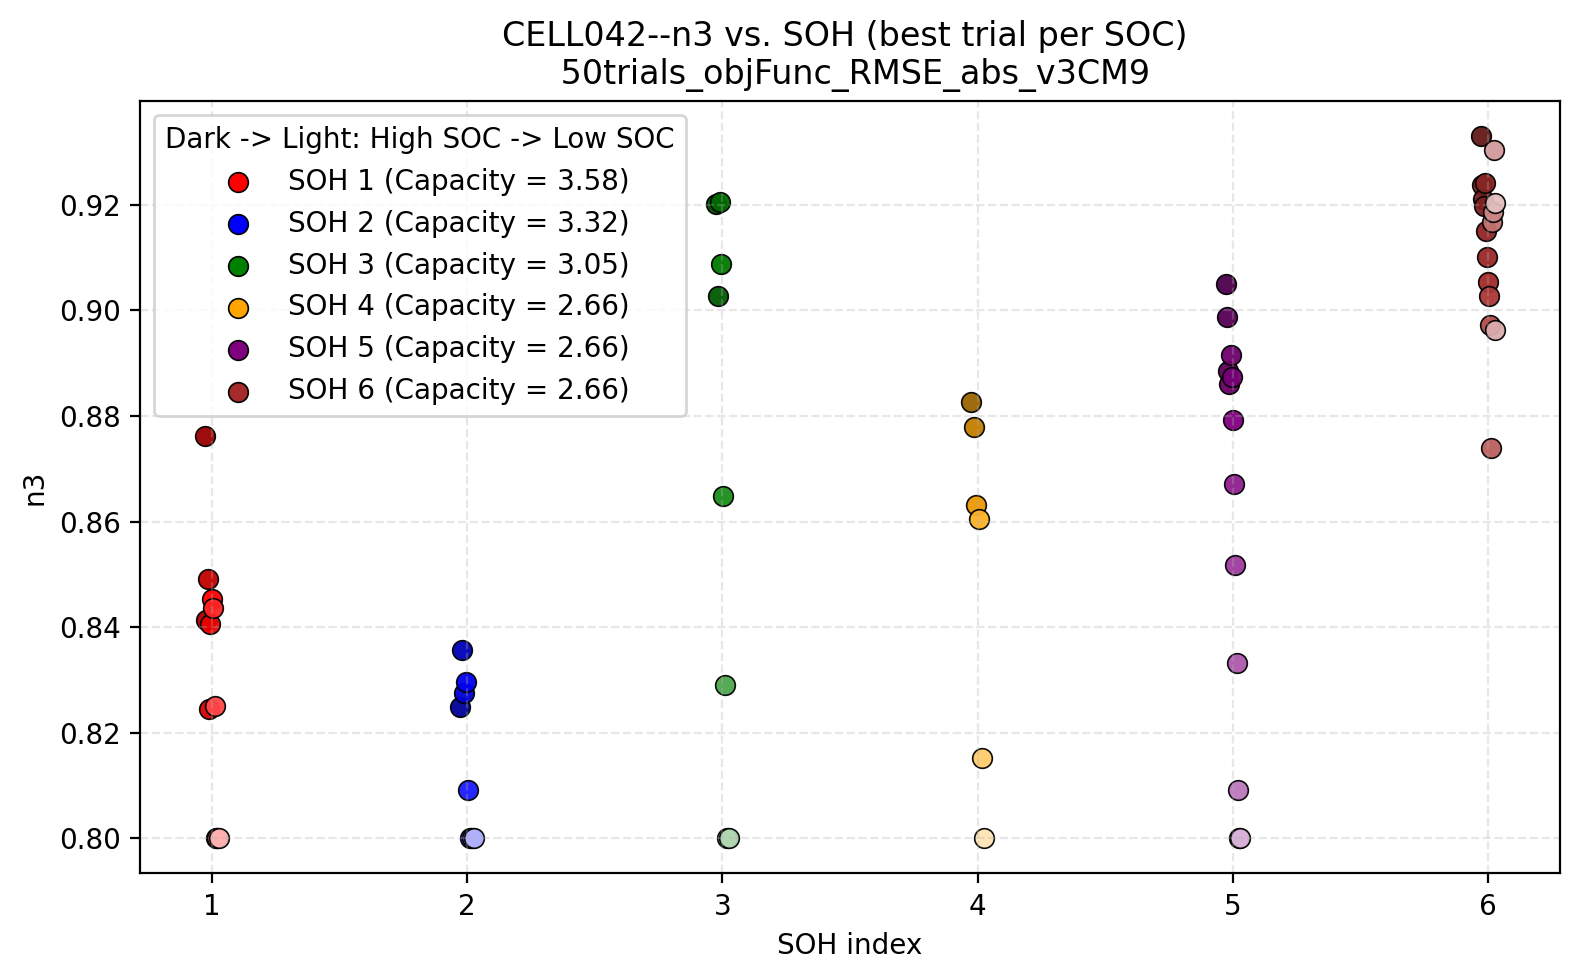

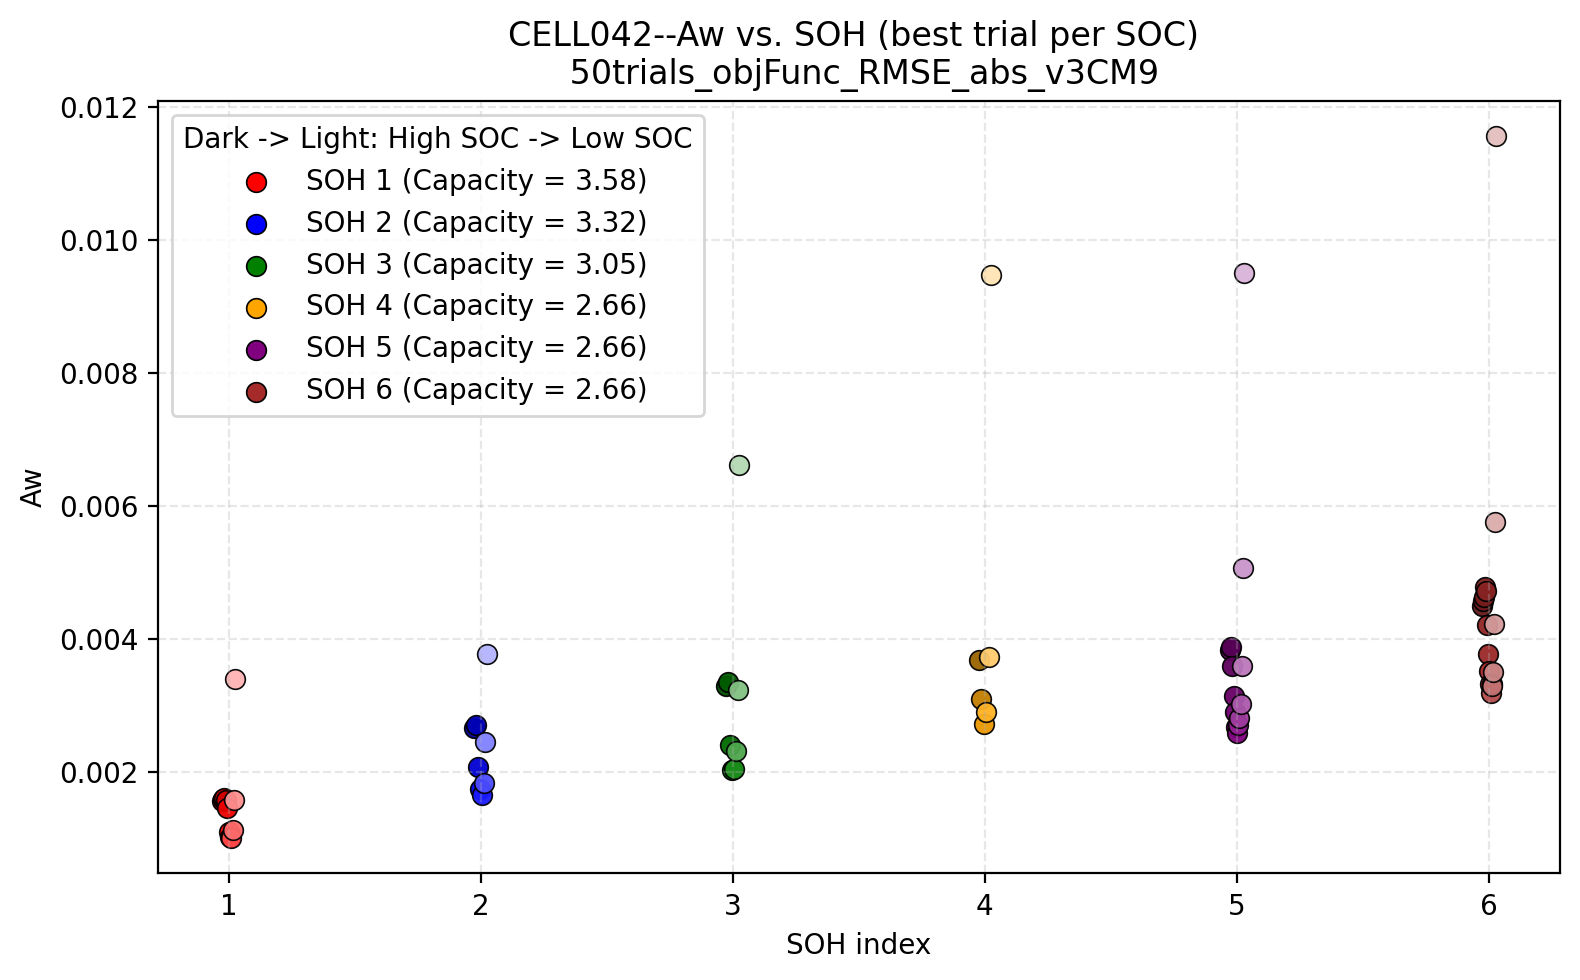

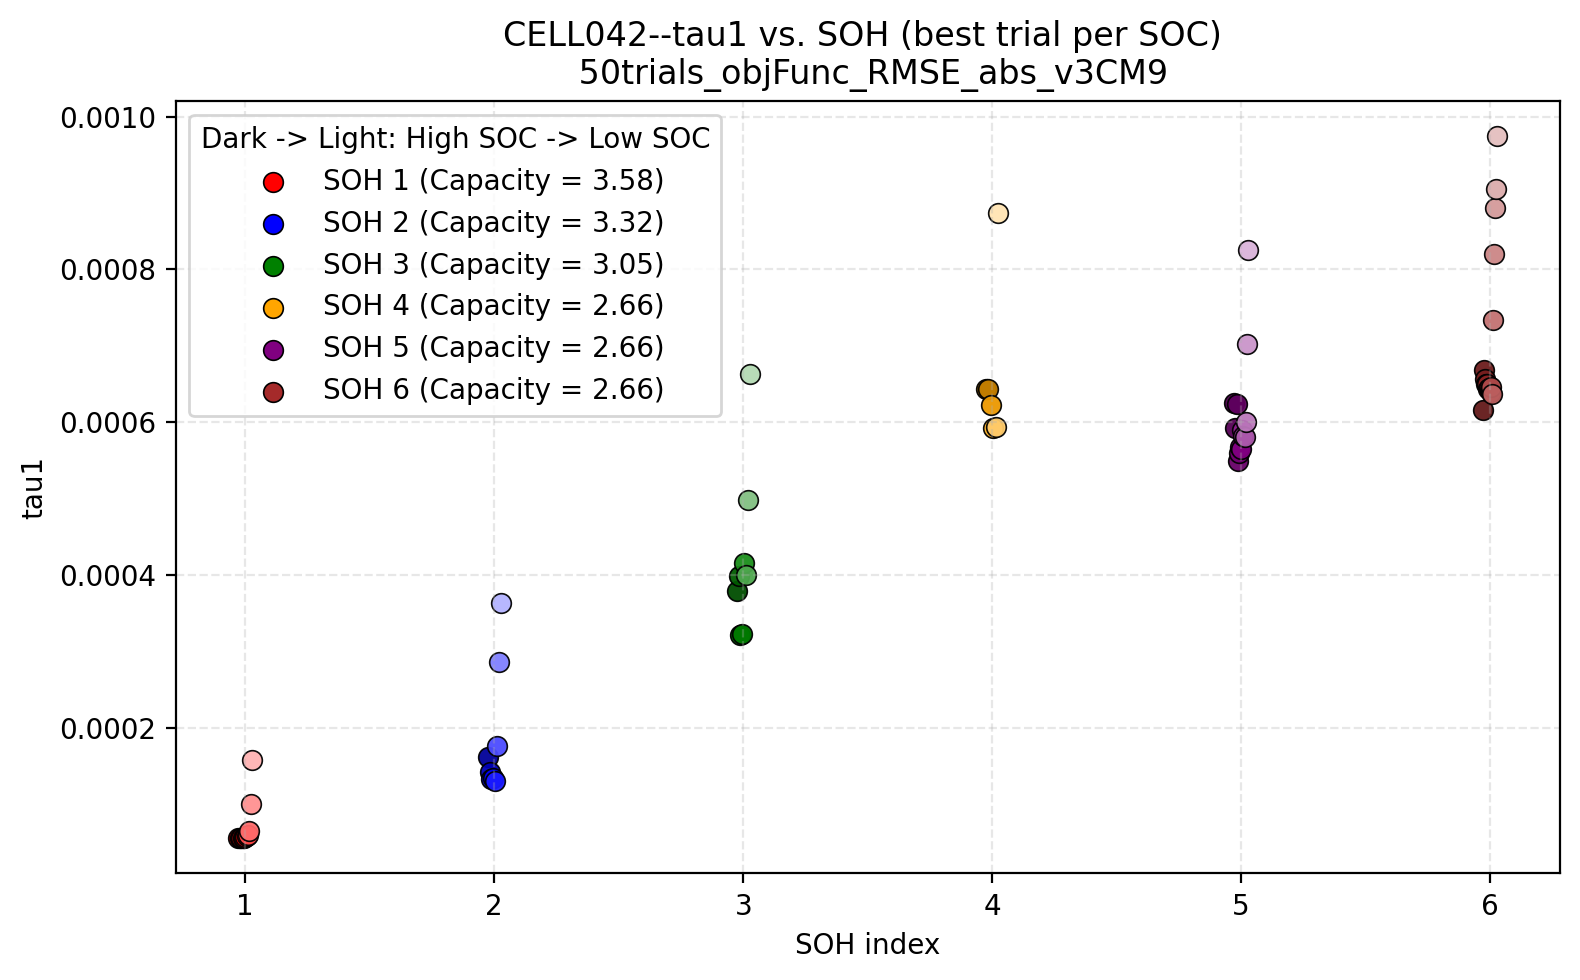

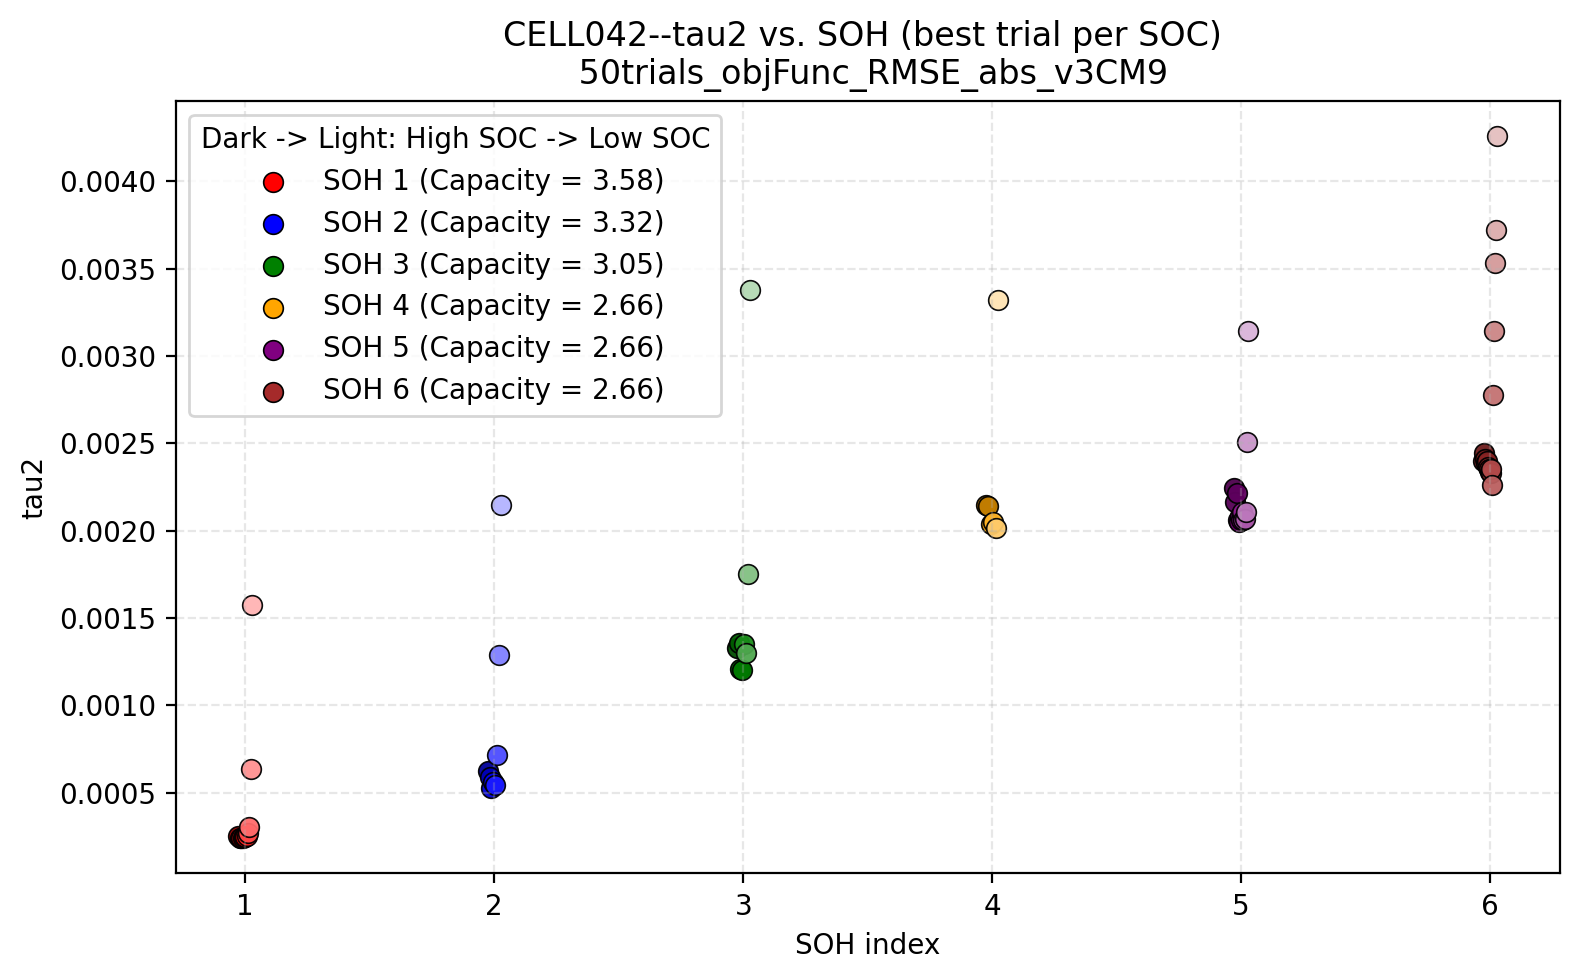

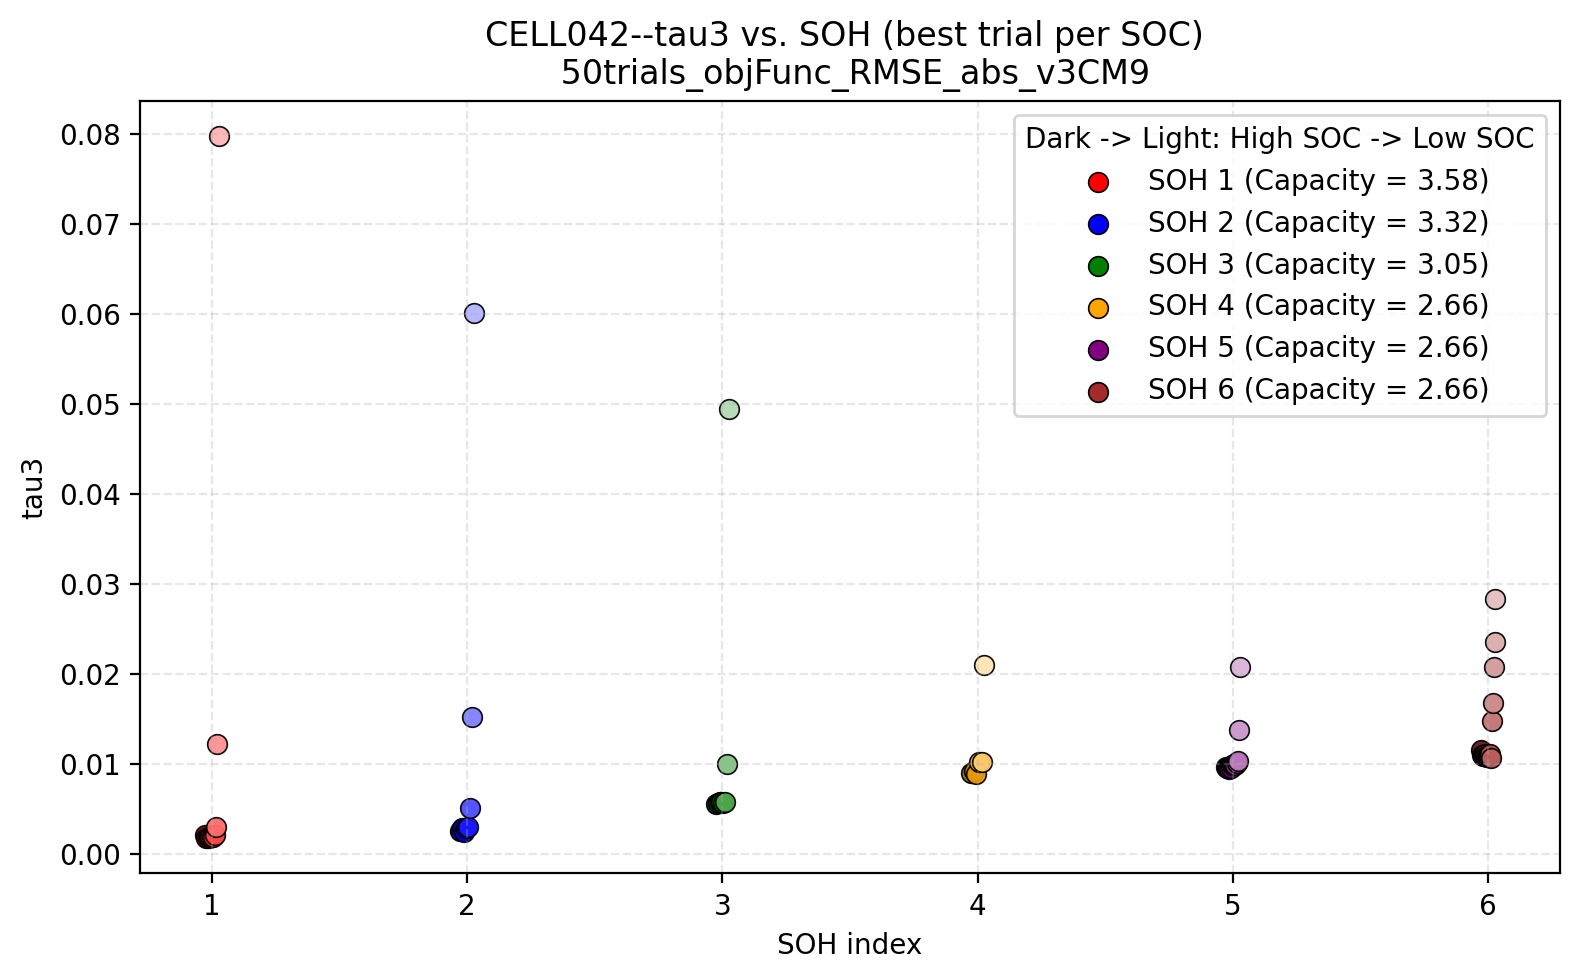

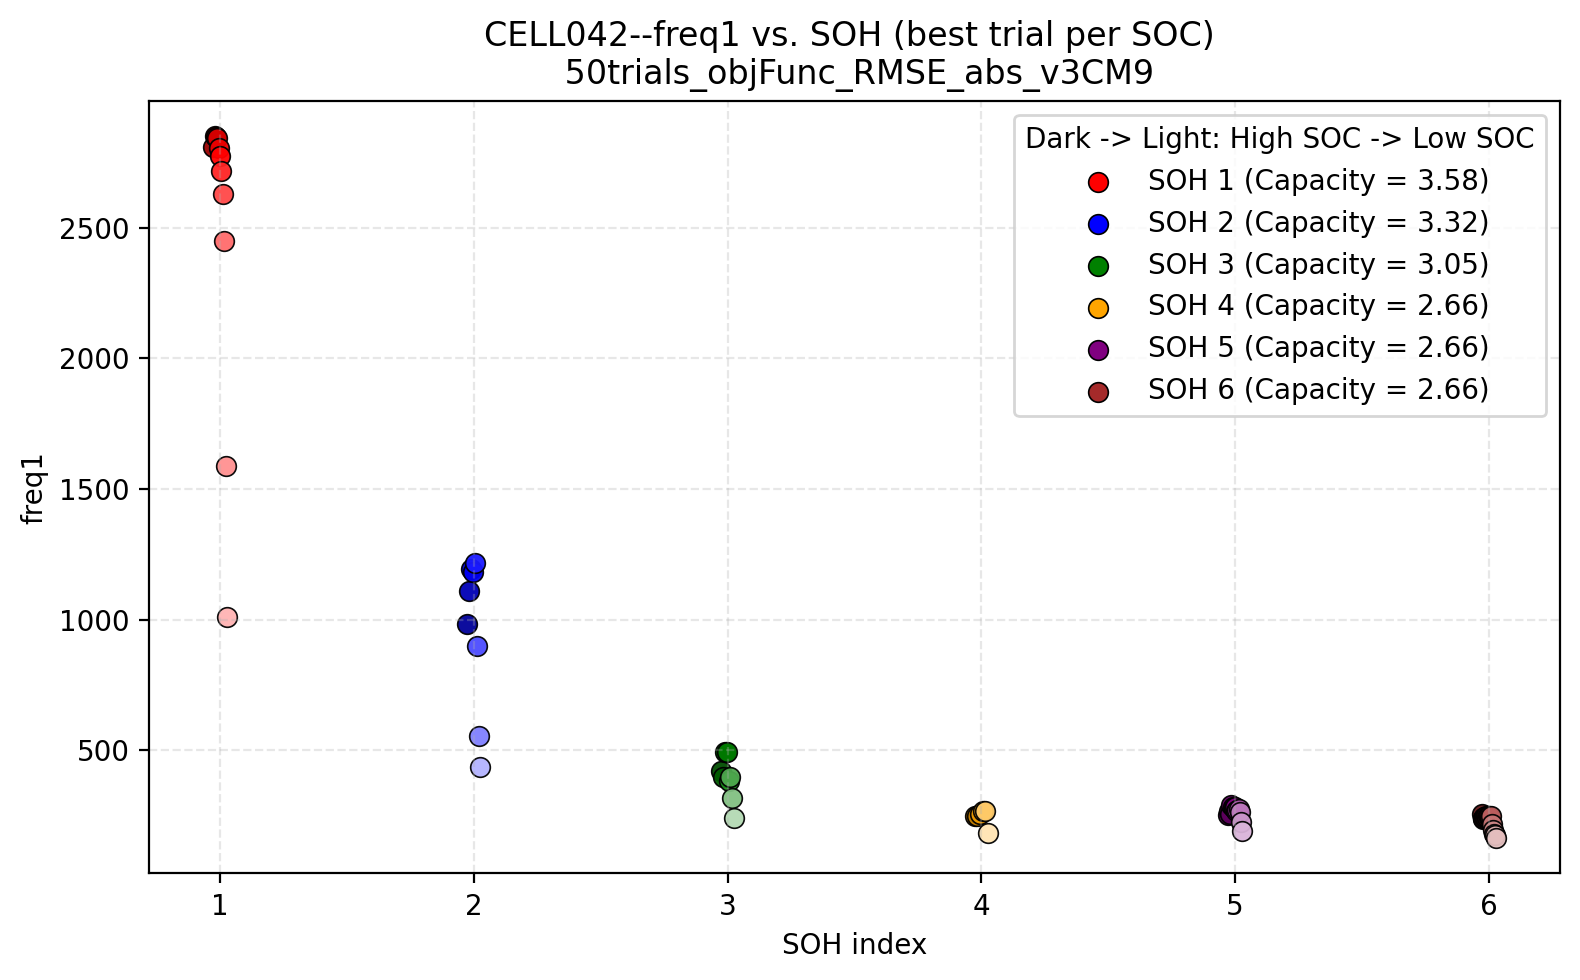

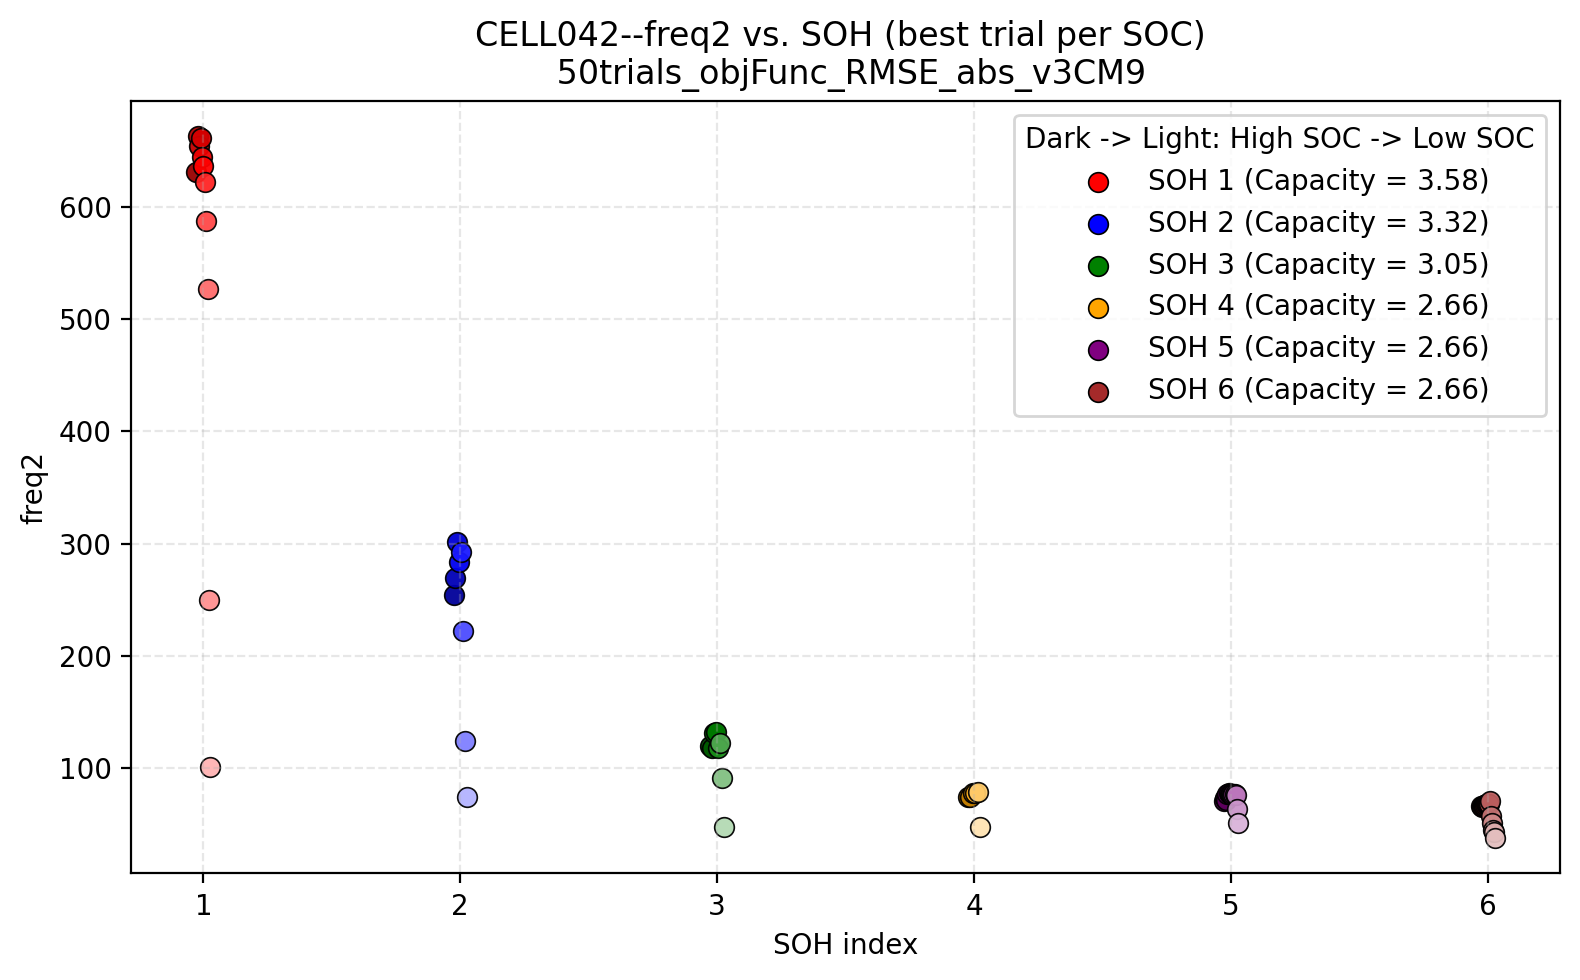

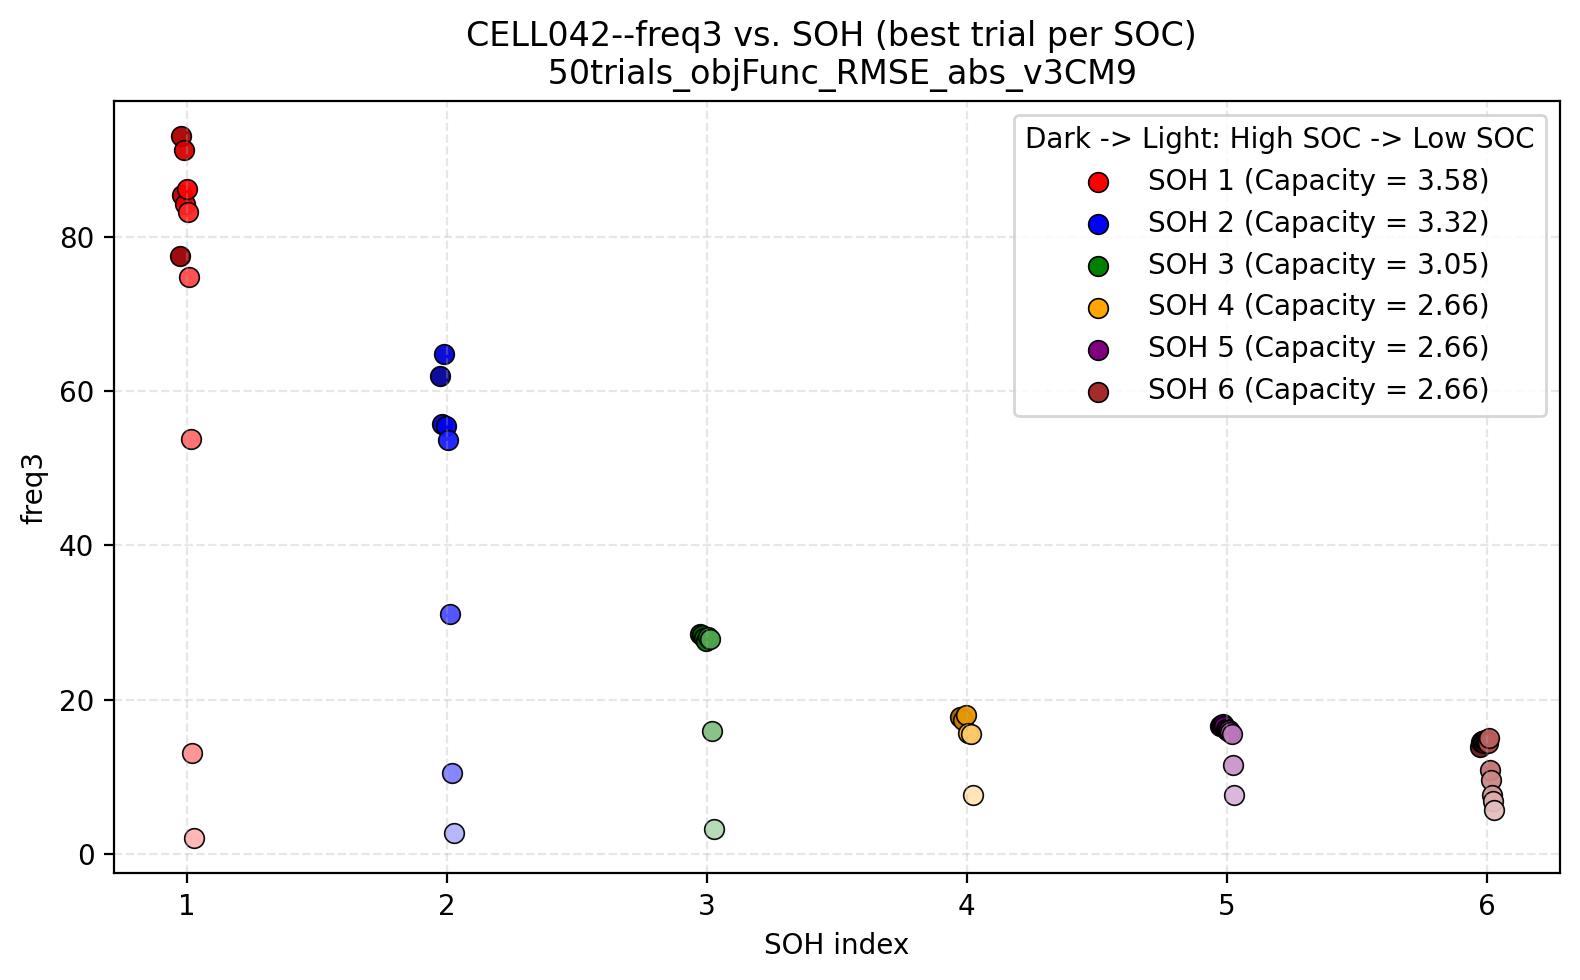

In [ ]:
obj_func = "RMSE_abs"
ECM_model_name = "v3CM9"
num_trials = 50

# ----------------------------------------------------------------------------------------
df = gather_best_trial_dataset("CELL042", obj_func, ECM_model_name, num_trials, cell42_metadata)

params_names = PARAMS_NAMES[ECM_model_name] + ["tau1", "tau2", "freq1", "freq2"]
if ECM_model_name == "v3CM9":
    params_names = PARAMS_NAMES[ECM_model_name] + ["tau1", "tau2",  "tau3", "freq1", "freq2", "freq3"]

# plot_param(df, "R0", cell42_metadata)
for p in params_names:
    plot_param(df,p, cell42_metadata, "CELL042", obj_func, ECM_model_name, num_trials)

#### EIS Reconstruction Nyquist Plot

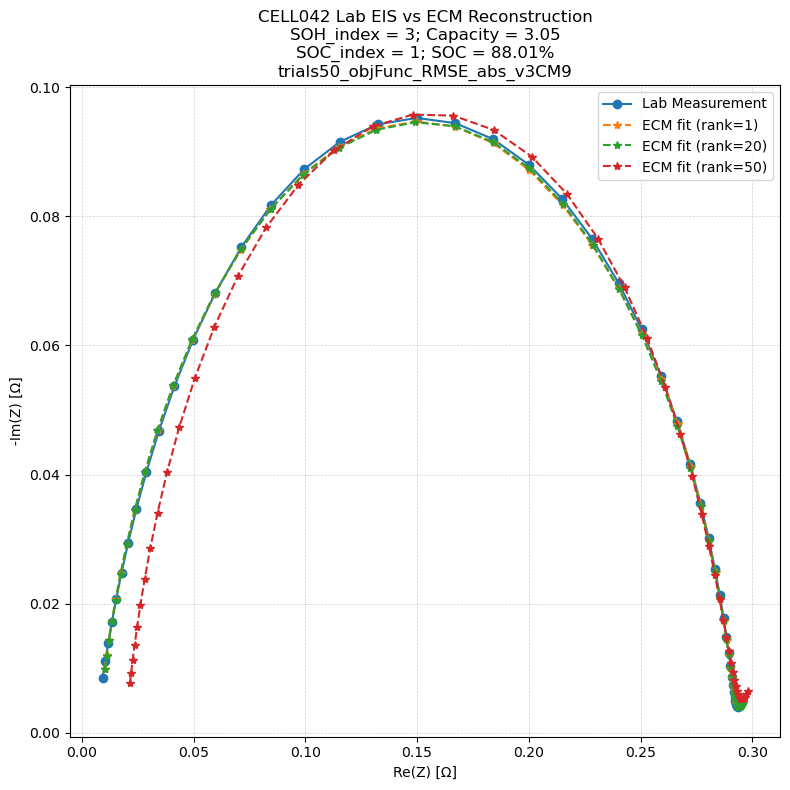

In [ ]:
battery_name = "CELL042"
soh_label = 3
soc_label = 1
ECM_name = "v3CM9"
obj_func = "RMSE_abs"
num_trials = 50

filepath = f"ECM_Params_Estimation/{battery_name}/{ECM_name}_{obj_func}_trials{num_trials}/soh{soh_label}/{battery_name}_soh{soh_label}_soc{soc_label}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}.csv"
subtitle = f"trials{num_trials}_objFunc_{obj_func}_{ECM_name}"

EIS_Nyquist_meas_vs_fit(battery_name, cell42_metadata, cell42_EISdata, soh_label, soc_label, ECM_name, filepath, select_est_ranks=[1,20,50], subtitle=subtitle)

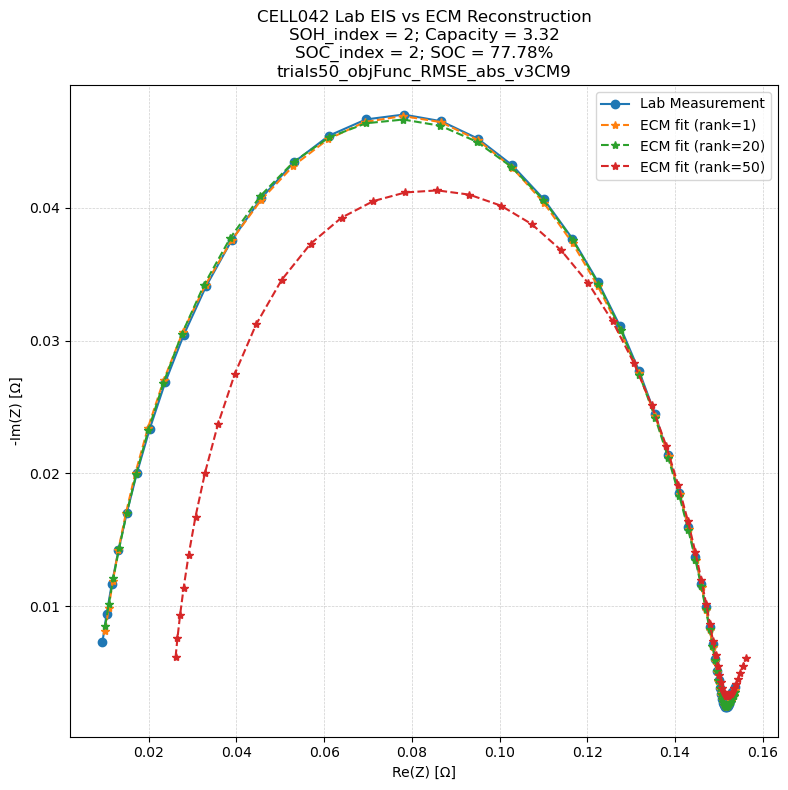

In [ ]:
battery_name = "CELL042"
soh_label = 2
soc_label = 2
ECM_name = "v3CM9"
obj_func = "RMSE_abs"
num_trials = 50

filepath = f"ECM_Params_Estimation/{battery_name}/{ECM_name}_{obj_func}_trials{num_trials}/soh{soh_label}/{battery_name}_soh{soh_label}_soc{soc_label}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}.csv"
subtitle = f"trials{num_trials}_objFunc_{obj_func}_{ECM_name}"

EIS_Nyquist_meas_vs_fit(battery_name, cell42_metadata, cell42_EISdata, soh_label, soc_label, ECM_name, filepath, select_est_ranks=[1,20,50], subtitle=subtitle)

#### Remove Outliers

In [ ]:
battery_name = "CELL042"
ECM_name = "v3CM7"
obj_func = "RMSE_abs"
num_trials = 50
param_col_names = PARAMS_NAMES[ECM_name]
output_dir =  f"ECM_Params_Estimation/{battery_name}/{ECM_name}_{obj_func}_trials{num_trials}_rmOutliers/"


for soh_i in range(cell42_metadata["num_soh"]):
    soh_data = cell42_metadata["soh"][soh_i]
    for soc_i in range(soh_data["num_soc"]):
        print(f" ---- SOH {soh_i+1}, SOC {soc_i+1} ----")
        subfolder = os.path.join(output_dir, f"soh{soh_i+1}")
        os.makedirs(subfolder, exist_ok=True)
        filepath = f"ECM_Params_Estimation/{battery_name}/{ECM_name}_{obj_func}_trials{num_trials}/soh{soh_i+1}/{battery_name}_soh{soh_i+1}_soc{soc_i+1}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}.csv"
        remove_outliers(filepath, param_col_names, subfolder)


 ---- SOH 1, SOC 1 ----
Step 1: 39 rows kept after freq1 <= 10kHz
Step 2: 39 rows kept after filtering parameters >= 1e-6
Step 3: 37 rows kept after RMSE_abs <= 0.008
Step 4: 37 rows kept after R2_magnitude >= 0.9998
Filtered data saved to: ECM_Params_Estimation/CELL042/v3CM7_RMSE_abs_trials50_rmOutliers/soh1\CELL042_soh1_soc1_trials50_objFunc_RMSE_abs_v3CM7_rmOutliers.csv
 ---- SOH 1, SOC 2 ----
Step 1: 40 rows kept after freq1 <= 10kHz
Step 2: 40 rows kept after filtering parameters >= 1e-6
Step 3: 40 rows kept after RMSE_abs <= 0.008
Step 4: 40 rows kept after R2_magnitude >= 0.9998
Filtered data saved to: ECM_Params_Estimation/CELL042/v3CM7_RMSE_abs_trials50_rmOutliers/soh1\CELL042_soh1_soc2_trials50_objFunc_RMSE_abs_v3CM7_rmOutliers.csv
 ---- SOH 1, SOC 3 ----
Step 1: 34 rows kept after freq1 <= 10kHz
Step 2: 34 rows kept after filtering parameters >= 1e-6
Step 3: 33 rows kept after RMSE_abs <= 0.008
Step 4: 33 rows kept after R2_magnitude >= 0.9998
Filtered data saved to: ECM_Par

Remaing EIS Reconstruction Check

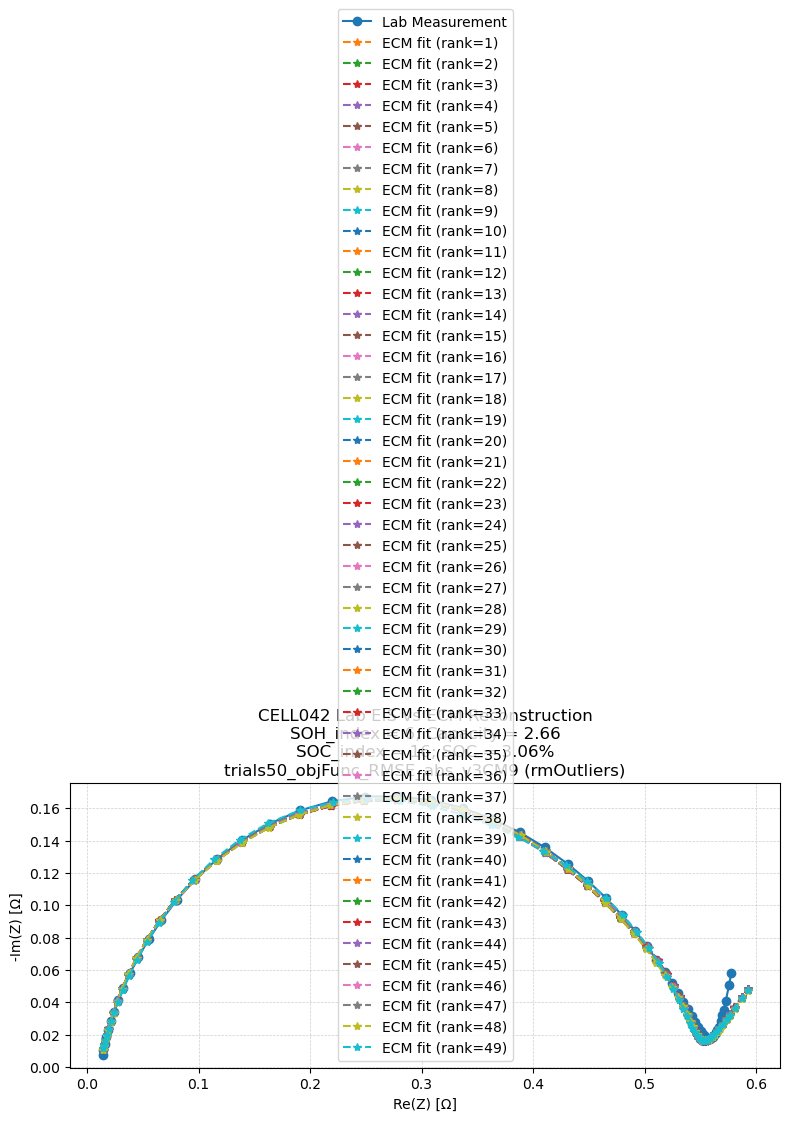

In [511]:
battery_name = "CELL042"
soh_label = 6
soc_label = 16
ECM_name = "v3CM9"
obj_func = "RMSE_abs"
num_trials = 50

filepath = f"ECM_Params_Estimation/{battery_name}/{ECM_name}_{obj_func}_trials{num_trials}_rmOutliers/soh{soh_label}/{battery_name}_soh{soh_label}_soc{soc_label}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}_rmOutliers.csv"
subtitle = f"trials{num_trials}_objFunc_{obj_func}_{ECM_name} (rmOutliers)"

df = pd.read_csv(filepath)
select_ranks = df["trial_rank"].values
# select_ranks = [1, 38,39,42, 44,45,46,47,48]
# print(select_ranks)
EIS_Nyquist_meas_vs_fit(battery_name, cell42_metadata, cell42_EISdata, soh_label, soc_label, ECM_name, filepath, select_est_ranks=select_ranks, subtitle=subtitle)

** For SOH=6, SOC=16, all results not good on warburg tail part

Manully Inspection Remove : This is relatively subjective

(try to remove <= 4 curves)

In [513]:
remove_EIS_check_v3CM7 = {
    (1, 1): [42,45,46,47],
    (1, 2): [44,47],
    (1, 3): [46],
    (1, 4): [43,44],
    (1, 5): [25, 39, 42],
    (1, 7): [27],
    (1, 8): [44, 45],
    (1, 9): [33, 38],
    (1, 10): [40, 41],
    (1, 11): [38],
    (2, 6): [47,48],
    (2,7): [45],
    (2,8): [33, 34],
    (3,2): [48, 49],
    (3,6): [48],
    (3,8): [46, 47],
    (4,6): [49],
    (6,7): [50]
}


remove_EIS_check_v3CM9 = {
    (1, 1): [40,41,42,45],
    (1, 2): [36,39,42,45],
    (1, 3): [38,41],
    (1, 4): [46],
    # (1, 5): [],
    (1,6): [40,41,43,44],
    (1, 7): [43, 44],
    (1, 8): [39],
    (1, 9): [38, 37],
    (1, 10): [30, 31],
    (1, 11): [30,31,32,33],
    (2, 1): [47],
    (2, 2): [41,42,43,45],
    (2, 4): [47,48],
    (2, 5): [44],
    (2, 6): [41,42,44,45],
    (2,7): [44, 45],
    (2,8): [39, 40],
    (3,1) : [49],
    (3,6): [48],
    (3,8): [45, 46],
    (4,1): [47],
    (5,1): [48],
    (5,2): [47, 48],
    (5,3): [47],
    (5,4): [49,50],
    (5,5): [48,49],
    (5,6): [47, 48,49],
    (5,7): [46, 47, 48],
    (5,8): [49],
    (5,10): [48],
    (5,11): [50],
    (5,13): [47,48],
    (6,1): [48],
    (6,2): [50],
    (6,4): [47],
    (6,7): [49],
    (6,9): [50],
    (6,11): [50],
    (6,13): [48,49],
    (6,14): [48]
}


In [514]:
# (soh, soc): [ranks to be removed]
remove_EIS_check = remove_EIS_check_v3CM9
battery_name = "CELL042"
ECM_name = "v3CM9"
obj_func = "RMSE_abs"
num_trials = 50
param_col_names = PARAMS_NAMES[ECM_name]
input_dir = f"ECM_Params_Estimation/{battery_name}/{ECM_name}_{obj_func}_trials{num_trials}_rmOutliers/"

print("===== Manully Remove after inspection =====")
for soh_i in range(cell42_metadata["num_soh"]):
    soh_data = cell42_metadata["soh"][soh_i]
    for soc_i in range(soh_data["num_soc"]):
        print(f" ---- SOH {soh_i + 1}, SOC {soc_i + 1} ----")

        folder = os.path.join(input_dir, f"soh{soh_i + 1}")
        filepath = os.path.join(
            folder,
            f"{battery_name}_soh{soh_i + 1}_soc{soc_i + 1}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}_rmOutliers.csv"
        )

        if os.path.exists(filepath):
            df = pd.read_csv(filepath)

            # Remove specified trial ranks
            key = (soh_i + 1, soc_i + 1)
            if key in remove_EIS_check:
                ranks_to_remove = remove_EIS_check[key]
                print(f"For SOH = {soh_i + 1}, SOC = {soc_i+1}, Remove trial_rank = {ranks_to_remove}")
                df = df[~df["trial_rank"].isin(ranks_to_remove)]

            # Overwrite the original file
            df.to_csv(filepath, index=False)
        else:
            print(f"File not found: {filepath}")


===== Manully Remove after inspection =====
 ---- SOH 1, SOC 1 ----
For SOH = 1, SOC = 1, Remove trial_rank = [40, 41, 42, 45]
 ---- SOH 1, SOC 2 ----
For SOH = 1, SOC = 2, Remove trial_rank = [36, 39, 42, 45]
 ---- SOH 1, SOC 3 ----
For SOH = 1, SOC = 3, Remove trial_rank = [38, 41]
 ---- SOH 1, SOC 4 ----
For SOH = 1, SOC = 4, Remove trial_rank = [46]
 ---- SOH 1, SOC 5 ----
 ---- SOH 1, SOC 6 ----
For SOH = 1, SOC = 6, Remove trial_rank = [40, 41, 43, 44]
 ---- SOH 1, SOC 7 ----
For SOH = 1, SOC = 7, Remove trial_rank = [43, 44]
 ---- SOH 1, SOC 8 ----
For SOH = 1, SOC = 8, Remove trial_rank = [39]
 ---- SOH 1, SOC 9 ----
For SOH = 1, SOC = 9, Remove trial_rank = [38, 37]
 ---- SOH 1, SOC 10 ----
For SOH = 1, SOC = 10, Remove trial_rank = [30, 31]
 ---- SOH 1, SOC 11 ----
For SOH = 1, SOC = 11, Remove trial_rank = [30, 31, 32, 33]
 ---- SOH 2, SOC 1 ----
For SOH = 2, SOC = 1, Remove trial_rank = [47]
 ---- SOH 2, SOC 2 ----
For SOH = 2, SOC = 2, Remove trial_rank = [41, 42, 43, 45]


#### Marge all SOC all SOH Dataframes

In [515]:
build_merged_df("CELL042", cell42_metadata, "v3CM9", 50, "RMSE_abs", suffix="rmOutliers")

Merged CSV files saved.


(   trial_rank  trial_id                                      initial_guess  \
 0           1        30  [0.006758359374681835, 0.004579243591337637, 0...   
 0           1         6  [0.002766812725585402, 0.005370588027460066, 0...   
 0           1        49  [0.004758665743457377, 0.004377174165839289, 0...   
 0           1        32  [0.007249029956768133, 0.006632034988146707, 0...   
 0           1        43  [0.003233961867086216, 0.0038214874136345035, ...   
 0           1        48  [0.0033736007505446126, 0.005353579257731282, ...   
 0           1        29  [0.005462559343828983, 0.004061349188509585, 0...   
 0           1        48  [0.0033736007505446126, 0.005353579257731282, ...   
 0           1        20  [0.00709366717816803, 0.004474378064617775, 0....   
 0           1        14  [0.003106717278703687, 0.0027227593927238087, ...   
 0           1        36  [0.00381086541886456, 0.006250862066489964, 0....   
 0           1        34  [0.005207796894436867, 0.0

In [592]:
build_merged_df_option("CELL042", cell42_metadata, "v3CM9", 50, "RMSE_abs", suffix="rmOutliers", stats="all", soc_range="G25")

Merged CSV files saved to ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_allSOH_all_G25SOC.csv.


,R0,R1,R2,R3,C1,n1,C2,n2,C3,n3,Aw,SOH,SOC
0,0.007920,0.012510,0.015891,0.007098,0.004531,1.000000,0.032362,0.914055,0.622835,0.876141,0.001567,3.57712,0.913348
1,0.007903,0.012350,0.016029,0.007167,0.004591,1.000000,0.033847,0.906892,0.671642,0.859518,0.001546,3.57712,0.913348
2,0.007896,0.012117,0.015137,0.008308,0.004574,1.000000,0.029150,0.923371,0.568205,0.842519,0.001541,3.57712,0.913348
3,0.007960,0.013042,0.015060,0.007357,0.004406,1.000000,0.031080,0.928278,0.611696,0.870479,0.001576,3.57712,0.913348
4,0.008027,0.013012,0.014683,0.007699,0.004408,1.000000,0.028673,0.938912,0.571017,0.869437,0.001565,3.57712,0.913348
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,0.009176,0.001930,0.315089,0.173009,0.560962,0.831168,0.013724,0.800000,0.090697,0.800000,0.002691,2.65746,0.252472
1236,0.009271,0.310722,0.009716,0.169444,0.013587,0.800000,0.460064,0.913883,0.094321,0.800000,0.002721,2.65746,0.252472
1237,0.009256,0.305897,0.020082,0.163937,0.013768,0.800000,0.379929,0.824743,0.097712,0.800000,0.002709,2.65746,0.252472
1238,0.009220,0.001091,0.314583,0.174297,0.686866,0.867656,0.013672,0.800000,0.089651,0.800000,0.002701,2.65746,0.252472


#### Boxplots

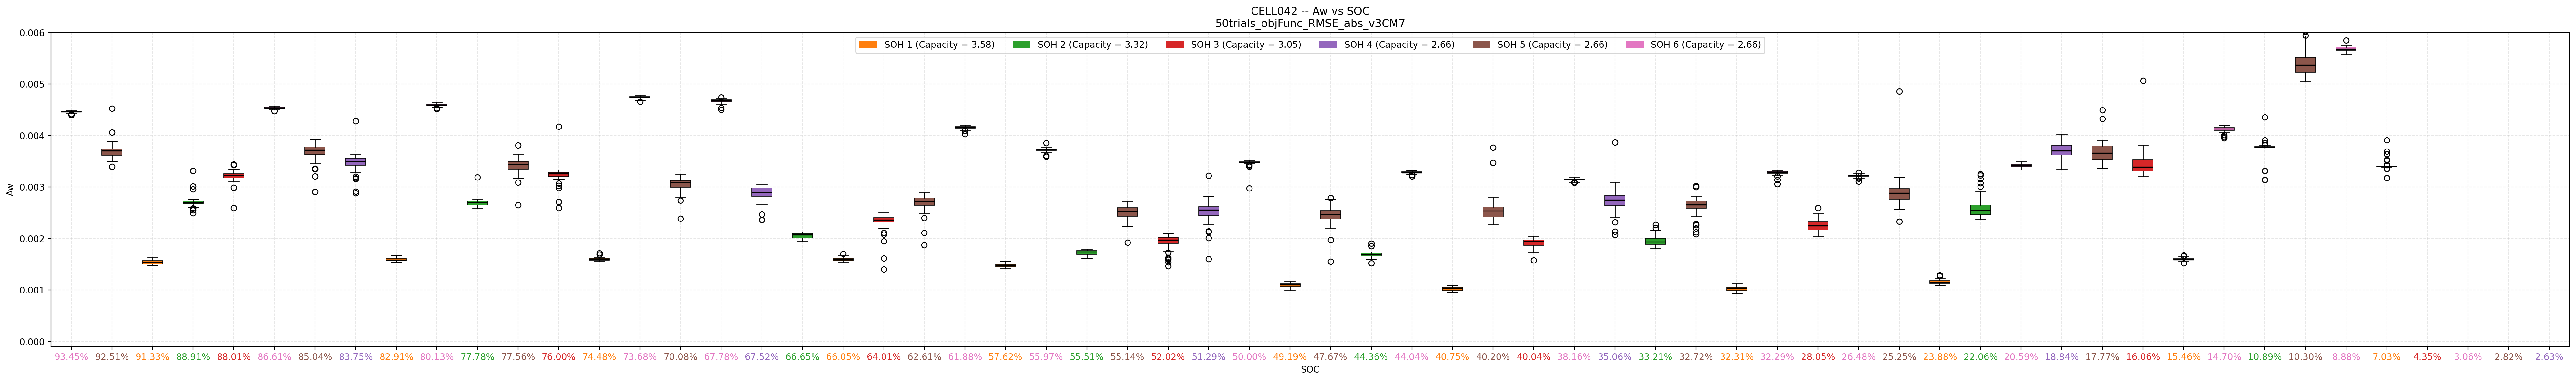

In [203]:
obj_func = "RMSE_abs"
ECM_model_name = "v3CM7"
num_trials = 50

# ----------------------------------------------------------------------------------------
df = gather_all_trials_dataset("CELL042", obj_func, ECM_model_name, num_trials, cell42_metadata, "rmOutliers")
# print(df["soc"].unique())
# print("Number of unique SOC values:", df["soc"].nunique())
# group_counts = df.groupby(["soh_label", "soc"]).size().reset_index(name="count")
# print(group_counts.sort_values(by="count"))

params_names = PARAMS_NAMES[ECM_model_name] + ["tau1", "tau2", "freq1", "freq2"]
if ECM_model_name == "v3CM9":
    params_names = PARAMS_NAMES[ECM_model_name] + ["tau1", "tau2",  "tau3", "freq1", "freq2", "freq3"]

# plot_param(df, "R0", cell42_metadata)
for p in ["Aw"]:
    plot_param_boxplot_by_soc(df, p, cell42_metadata, "CELL042", obj_func, ECM_model_name, num_trials)

#### Linear Regression

Linear Regression Model

                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     5490.
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           5.77e-36
Time:                        22:51:40   Log-Likelihood:                 77.532
No. Observations:                  30   AIC:                            -149.1
Df Residuals:                      27   BIC:                            -144.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6256      0.007    552.375      0.0

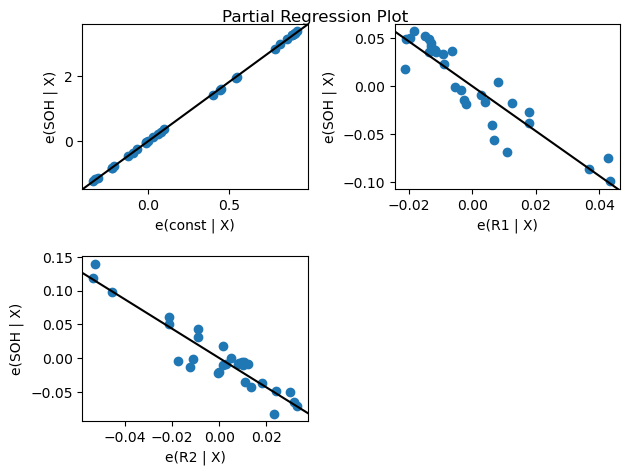

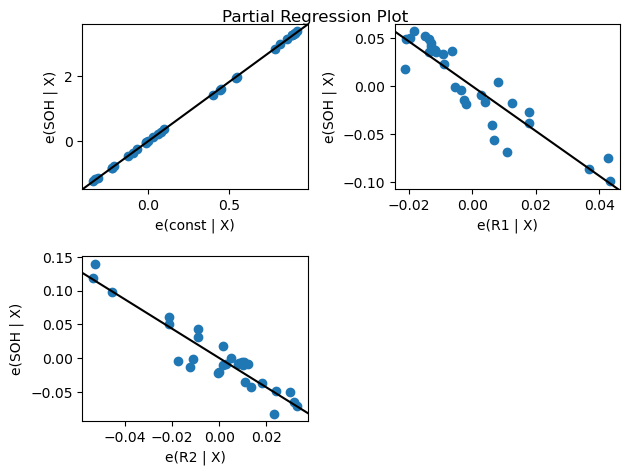

In [518]:
import statsmodels.api as sm

# Load Dataframe
df = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")

# Add constant term (intercept)
X = sm.add_constant(df[["R1", "R2"]])
# e = np.random.normal(size=X.shape[0])
y = df["SOH"]


# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())
sm.graphics.plot_partregress_grid(model)



In [257]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


df_subset = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM7_RMSE_abs_trials50_rmOutliers/CELL042_v3CM7_trials50_median_socG25_allSOH.csv")
# R3-only model
model_r3 = smf.ols("SOH ~ R0+R1+R2", data=df_subset).fit()

# R1 + R2 + R3 model
model_full = smf.ols("SOH ~ R1 + R2 + R3", data=df_subset).fit()

# Compare with F-test
f_test = model_full.compare_f_test(model_r3)
print("F statistic:", f_test[0])
print("p-value:", f_test[1])
print("df_diff:", f_test[2])


F statistic: -inf
p-value: nan
df_diff: 0.0


c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\statsmodels\regression\linear_model.py:2284: RuntimeWarning: divide by zero encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full


correlation matrix

          SOC        R0        R1        R2        R3
SOC  1.000000 -0.012377 -0.040075 -0.093258 -0.237835
R0  -0.012377  1.000000  0.704804  0.829987  0.677096
R1  -0.040075  0.704804  1.000000  0.970736  0.930563
R2  -0.093258  0.829987  0.970736  1.000000  0.940092
R3  -0.237835  0.677096  0.930563  0.940092  1.000000


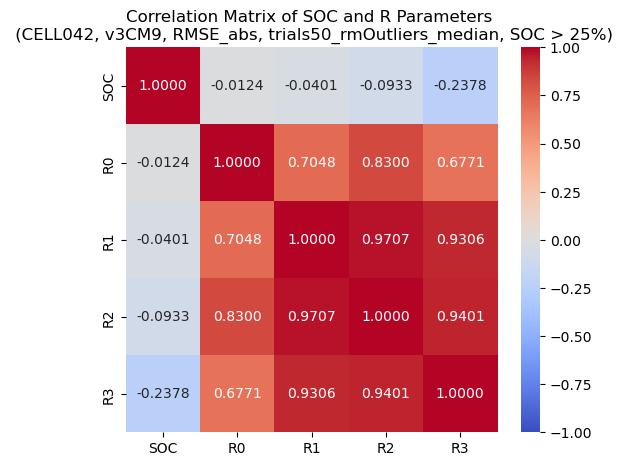

          SOC        R0        R1        R2        R3
SOC  1.000000 -0.143440 -0.485930 -0.330933 -0.439608
R0  -0.143440  1.000000  0.634301  0.878389  0.780727
R1  -0.485930  0.634301  1.000000  0.889229  0.928406
R2  -0.330933  0.878389  0.889229  1.000000  0.959759
R3  -0.439608  0.780727  0.928406  0.959759  1.000000


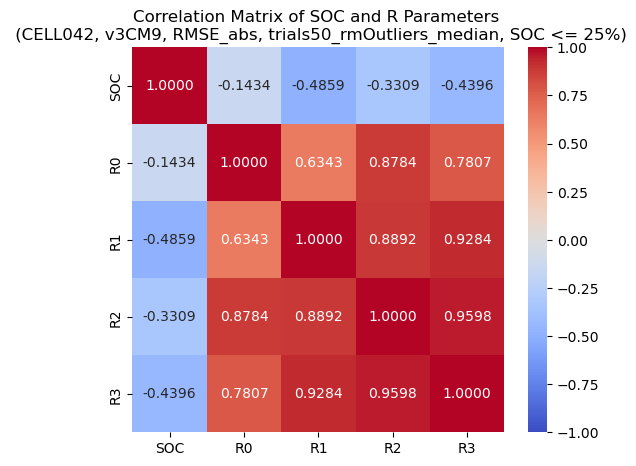

          SOC        R0        R1        R2        R3
SOC  1.000000  0.007710 -0.091359 -0.064615 -0.334915
R0   0.007710  1.000000  0.681590  0.843155  0.672042
R1  -0.091359  0.681590  1.000000  0.947425  0.879389
R2  -0.064615  0.843155  0.947425  1.000000  0.891828
R3  -0.334915  0.672042  0.879389  0.891828  1.000000


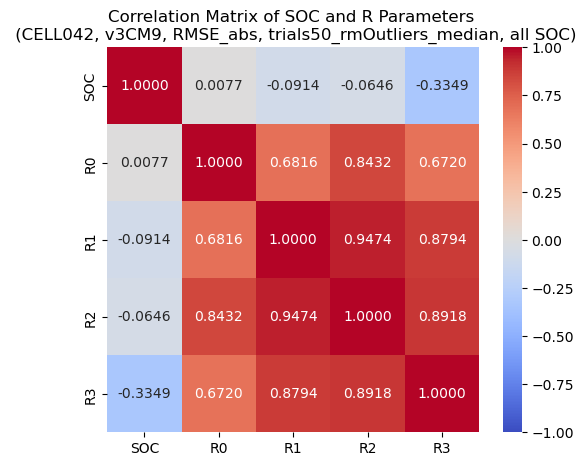

In [517]:
df_g25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")
df_leq25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socLEQ25_allSOH.csv")
df_allsoc = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_allSOH_allSOC.csv")

corr_matrix_g25 = df_g25[["SOC", "R0", "R1", "R2", "R3"]].corr()
print(corr_matrix_g25)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix_g25, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".4f")
plt.title("Correlation Matrix of SOC and R Parameters \n (CELL042, v3CM9, RMSE_abs, trials50_rmOutliers_median, SOC > 25%)")
plt.show()

corr_matrix_leq25 = df_leq25[["SOC", "R0", "R1", "R2", "R3"]].corr()
print(corr_matrix_leq25)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix_leq25, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".4f")
plt.title("Correlation Matrix of SOC and R Parameters \n (CELL042, v3CM9, RMSE_abs, trials50_rmOutliers_median, SOC <= 25%)")
plt.show()


corr_matrix = df_allsoc[["SOC", "R0", "R1", "R2", "R3"]].corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".4f")
plt.title("Correlation Matrix of SOC and R Parameters \n (CELL042, v3CM9, RMSE_abs, trials50_rmOutliers_median, all SOC)")
plt.show()

In [525]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

df_g25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")
X = df_g25[["SOC", "R0", "R1", "R2", "R3"]]

# Add constant for statsmodels
X = sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
print(X.columns)
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)


Index(['const', 'SOC', 'R0', 'R1', 'R2', 'R3'], dtype='object')
  feature         VIF
0   const  379.145317
1     SOC    1.482310
2      R0   11.746964
3      R1   52.211937
4      R2  122.589030
5      R3   15.813866


In [522]:
# Fit model
model = smf.ols("SOH ~ SOC + R0 + R1 + R2 + R3", data=df_g25).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     3525.
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           1.45e-33
Time:                        23:15:47   Log-Likelihood:                 86.381
No. Observations:                  30   AIC:                            -160.8
Df Residuals:                      24   BIC:                            -152.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.7521      0.054     69.457      0.0

In [521]:
# Fit model
model = smf.ols("SOH ~ SOC + R0 + R1 + R3", data=df_g25).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     2366.
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           7.73e-32
Time:                        23:15:21   Log-Likelihood:                 76.461
No. Observations:                  30   AIC:                            -142.9
Df Residuals:                      25   BIC:                            -135.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.9836      0.032    126.115      0.0

In [277]:

X = df_g25[["SOC", "R0", "R1", "R3"]]

# Add constant for statsmodels
X = sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
print(X.columns)
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

Index(['const', 'SOC', 'R0', 'R1', 'R3'], dtype='object')
  feature         VIF
0   const  194.380004
1     SOC    1.327356
2      R0    9.120394
3      R1   57.260163
4      R3   92.684736


In [ ]:
m_base = smf.ols("SOH ~ SOC + R0 + R1 + R2 + R3", data=df_g25).fit()
m_full = smf.ols("SOH ~ SOC + R0 + R1 + R3 ", data=df_g25).fit()
# print(m_full.compare_f_test(m_base))
# print(m_base.compare_f_test(m_full))



(np.float64(22.497602204883915), np.float64(7.978915819669009e-05), np.float64(1.0))


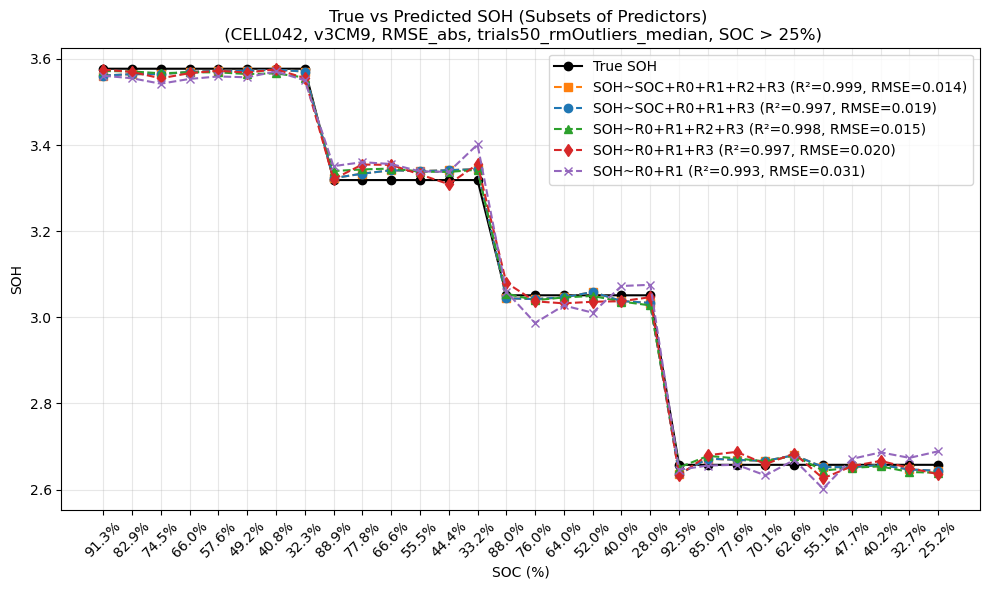

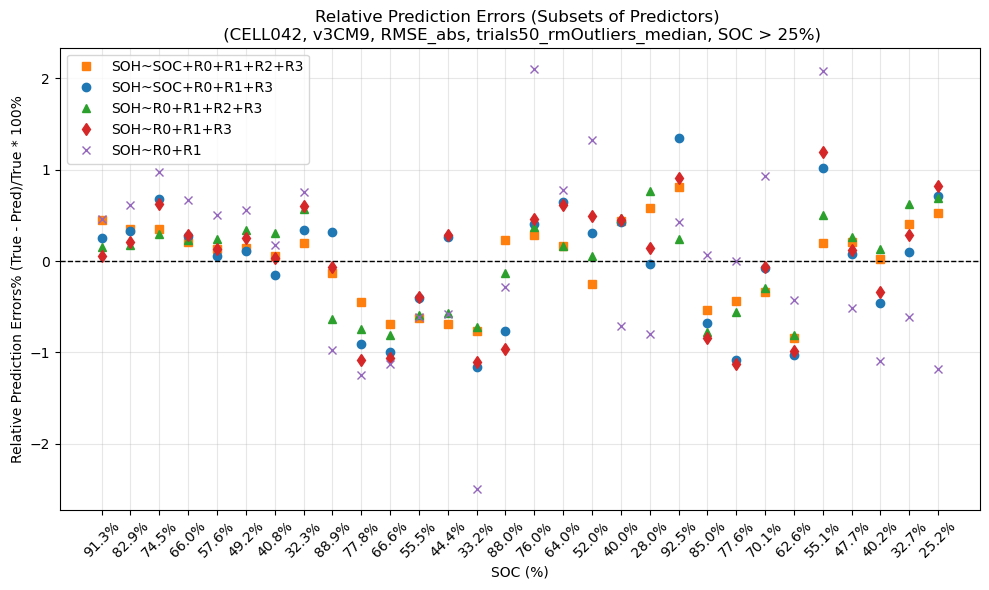

In [553]:
df_g25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")
model_full = smf.ols("SOH ~ SOC + R0 + R1 + R2 + R3", data=df_g25).fit()
model_dr2 = smf.ols("SOH ~ SOC + R0 + R1 + R3", data=df_g25).fit()

model_Rs = smf.ols("SOH ~ R0 + R1 + R2 + R3", data=df_g25).fit()
model_R03 = smf.ols("SOH ~ R0 + R1 + R3", data=df_g25).fit()
model_R01 = smf.ols("SOH ~ R0 + R1", data=df_g25).fit()


y = df_g25["SOH"].values
idx = np.arange(1, len(y)+1)
idx_label = df_g25["SOC"].values *100   

# =========================
# Plot 1: True vs Predicted
# =========================
yhat_full = model_full.predict(df_g25)
yhat_dr2 = model_dr2.predict(df_g25)

yhat_r = model_Rs.predict(df_g25)
yhat_r03 = model_R03.predict(df_g25)
yhat_r01 = model_R01.predict(df_g25)

# Calculate R² and RMSE
from sklearn.metrics import mean_squared_error, r2_score
rmse_o = np.sqrt(mean_squared_error(y, yhat_full))
r2_o = r2_score(y, yhat_full)
rmse_dr2 = np.sqrt(mean_squared_error(y, yhat_dr2))
r2_dr2 = r2_score(y, yhat_dr2)
rmse_r = np.sqrt(mean_squared_error(y, yhat_r))
r2_r = r2_score(y, yhat_r)
rmse_r03 = np.sqrt(mean_squared_error(y, yhat_r03))
r2_r03 = r2_score(y, yhat_r03)
rmse_r01 = np.sqrt(mean_squared_error(y, yhat_r01))
r2_r01 = r2_score(y, yhat_r01)


plt.figure(figsize=(10,6))
plt.plot(idx, y, "o-", color="black", label="True SOH")
plt.plot(idx, yhat_full,   "s--", color="tab:orange", label=f"SOH~SOC+R0+R1+R2+R3 (R²={r2_o:.3f}, RMSE={rmse_o:.3f})")
plt.plot(idx, yhat_full,   "o--", color="tab:blue", label=f"SOH~SOC+R0+R1+R3 (R²={r2_dr2:.3f}, RMSE={rmse_dr2:.3f})")
plt.plot(idx, yhat_r, "^--", color="tab:green",  label=f"SOH~R0+R1+R2+R3 (R²={r2_r:.3f}, RMSE={rmse_r:.3f})")
plt.plot(idx, yhat_r03, "d--", color="tab:red",    label=f"SOH~R0+R1+R3 (R²={r2_r03:.3f}, RMSE={rmse_r03:.3f})")
plt.plot(idx, yhat_r01,  "x--", color="tab:purple", label=f"SOH~R0+R1 (R²={r2_r01:.3f}, RMSE={rmse_r01:.3f})")
plt.xlabel("SOC (%)")
plt.xticks(idx, [f"{val:.1f}%" for val in idx_label], rotation=45)
plt.ylabel("SOH")
plt.title(f"True vs Predicted SOH (Subsets of Predictors) \n (CELL042, v3CM9, RMSE_abs, trials50_rmOutliers_median, SOC > 25%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# Plot 2: Relative Prediction Errors
# e = True SOH - Predicted
# =========================
err_full   = ((y - yhat_full)/y) * 100
err_dr2   = ((y - yhat_dr2)/y) * 100
err_r    = ((y - yhat_r)/y) * 100
err_r03  = ((y - yhat_r03)/y) * 100
err_r01  = ((y - yhat_r01)/y) * 100


plt.figure(figsize=(10,6))
plt.plot(idx, err_full,   "s", color="tab:orange", label="SOH~SOC+R0+R1+R2+R3")
plt.plot(idx, err_dr2,   "o", color="tab:blue", label="SOH~SOC+R0+R1+R3")
plt.plot(idx, err_r, "^", color="tab:green",  label="SOH~R0+R1+R2+R3")
plt.plot(idx, err_r03, "d", color="tab:red",    label="SOH~R0+R1+R3")
plt.plot(idx, err_r01,  "x", color="tab:purple", label="SOH~R0+R1")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.xlabel("SOC (%)")
plt.xticks(idx, [f"{val:.1f}%" for val in idx_label], rotation=45)

plt.ylabel("Relative Prediction Errors% (True - Pred)/True * 100%")
plt.title(f"Relative Prediction Errors (Subsets of Predictors) \n (CELL042, v3CM9, RMSE_abs, trials50_rmOutliers_median, SOC > 25%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Regularized Regression

In [282]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# G25 subset

X = df_g25[["SOC","R0","R1","R2","R3"]].values
y = df_g25["SOH"].values

# Try on SOC > 25% subset too:

# Ridge (alphas grid)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4,4,41), cv=5))
ridge.fit(X, y)
print("Ridge alpha:", ridge.named_steps["ridgecv"].alpha_)
print("Ridge coefs:", ridge.named_steps["ridgecv"].coef_)

# Lasso
lasso = make_pipeline(StandardScaler(), LassoCV(alphas=None, cv=5, max_iter=20000))
lasso.fit(X, y)
print("Lasso alpha:", lasso.named_steps["lassocv"].alpha_)
print("Lasso coefs:", lasso.named_steps["lassocv"].coef_)

# Elastic Net
enet = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.2,.5,.8], cv=5, max_iter=20000))
enet.fit(X, y)
print("ENet l1_ratio:", enet.named_steps["elasticnetcv"].l1_ratio_)
print("ENet alpha:", enet.named_steps["elasticnetcv"].alpha_)
print("ENet coefs:", enet.named_steps["elasticnetcv"].coef_)


Ridge alpha: 0.0001
Ridge coefs: [-0.00695534 -0.01640904 -0.2391681  -0.04625976 -0.07131417]
Lasso alpha: 0.00036770643425942224
Lasso coefs: [-0.00580124 -0.01629504 -0.23331209 -0.05744996 -0.0655837 ]
ENet l1_ratio: 0.2
ENet alpha: 0.0018385321712971112
ENet coefs: [-0.00484182 -0.01223155 -0.20438185 -0.08596361 -0.06906268]


c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1632: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


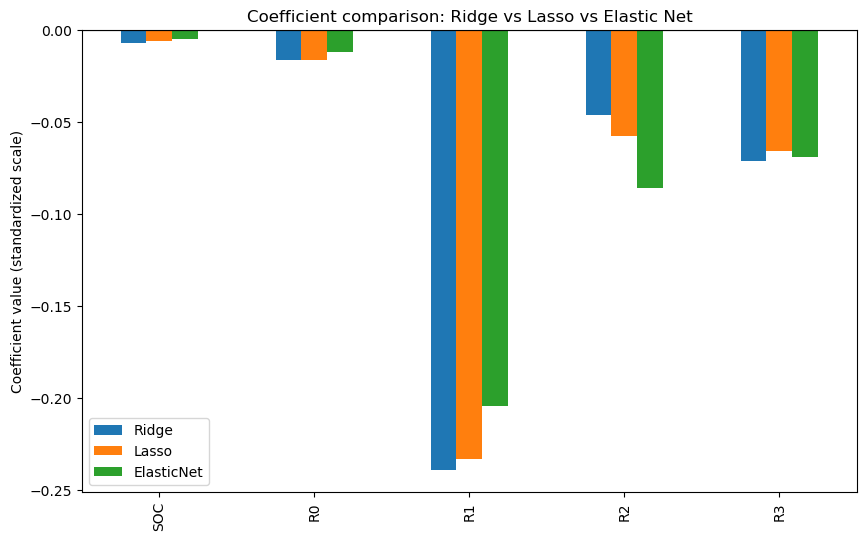

In [281]:
import matplotlib.pyplot as plt
import numpy as np

features = ["SOC","R0","R1","R2","R3"]

ridge_coefs = ridge.named_steps["ridgecv"].coef_
lasso_coefs = lasso.named_steps["lassocv"].coef_
enet_coefs  = enet.named_steps["elasticnetcv"].coef_

coef_df = pd.DataFrame({
    "Ridge": ridge_coefs,
    "Lasso": lasso_coefs,
    "ElasticNet": enet_coefs
}, index=features)

coef_df.plot(kind="bar", figsize=(10,6))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Coefficient comparison: Ridge vs Lasso vs Elastic Net")
plt.ylabel("Coefficient value (standardized scale)")
plt.show()


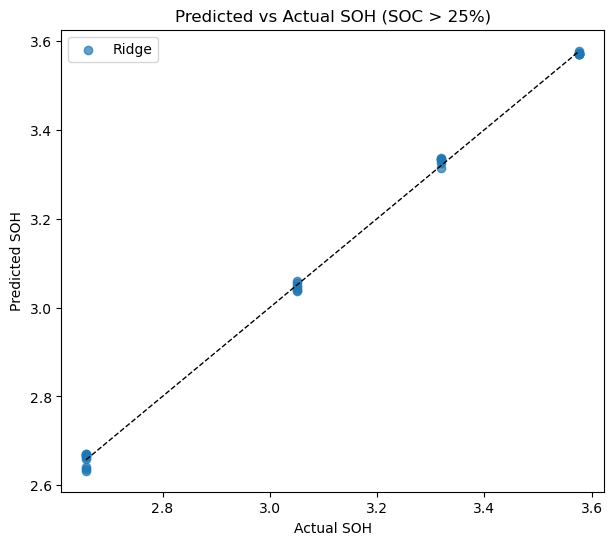

In [284]:
y_pred_ridge = ridge.predict(X)
y_pred_lasso = lasso.predict(X)
y_pred_enet  = enet.predict(X)


import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y, y_pred_ridge, label="Ridge", alpha=0.7)
# plt.scatter(y, y_pred_lasso, label="Lasso", alpha=0.7)
# plt.scatter(y, y_pred_enet,  label="ElasticNet", alpha=0.7)

# 45-degree line (perfect prediction)
lims = [min(y), max(y)]
plt.plot(lims, lims, "k--", linewidth=1)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs Actual SOH (SOC > 25%)")
plt.legend()
plt.show()


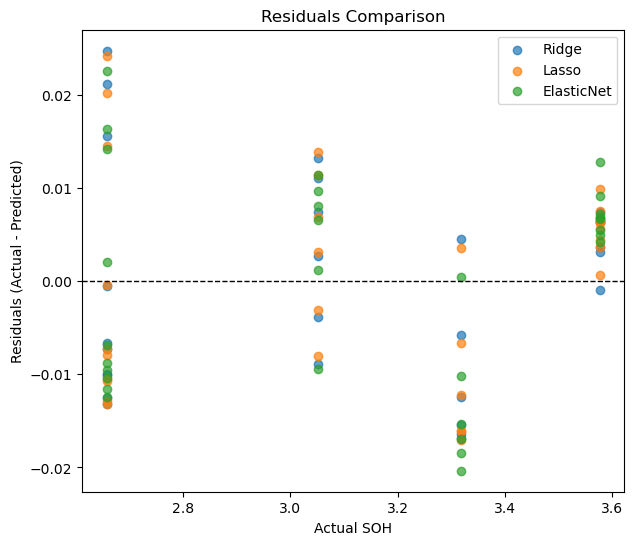

In [285]:
plt.figure(figsize=(7,6))
plt.scatter(y, y - y_pred_ridge, label="Ridge", alpha=0.7)
plt.scatter(y, y - y_pred_lasso, label="Lasso", alpha=0.7)
plt.scatter(y, y - y_pred_enet,  label="ElasticNet", alpha=0.7)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Actual SOH")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Comparison")
plt.legend()
plt.show()


Multicandidates

In [314]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

In [544]:
feature_sets = {
    "S1:full": ["SOC","R0","R1", "R2", "R3"],
    "S2:SOC_R0_R1_R3": ["SOC","R0","R1","R3"],
    "S3:R0_R1_R2_R3": ["R0","R1","R2","R3"],
}

df_g25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")

# SOC > 25% subset
# mask = df["SOC"] > 0.25
X_full = df_g25[["SOC","R0","R1","R2","R3"]]
y = df_g25["SOH"]

# outer_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=40) # repeats 10 times, each with random split of data into 5 folds
outer_cv = KFold(n_splits=5, shuffle=True, random_state=40)

alphas = np.logspace(-4, 4, 41)

# Lasso and EN automatically generate alphas (100 values) if alphas=None [a_max * 1e-3, a_max]
models = {
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5)),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=20000, random_state=0)),
    "ElasticNet": make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.2,.5,.8,.95, 1],
                                                              cv=5, max_iter=20000, random_state=0))
}

fitted = {name: pipe.fit(X_full, y) for name, pipe in models.items()}

results = []
for subset_name, cols in feature_sets.items():
    X = X_full[cols].values
    for model_name, pipe in models.items():
        rmse_scores = (-cross_val_score(pipe, X, y, scoring="neg_mean_squared_error", cv=outer_cv))**0.5
        r2_scores = cross_val_score(pipe, X, y, scoring="r2", cv=outer_cv)
        results.append({
            "subset": subset_name,
            "model": model_name,
            "rmse_mean": rmse_scores.mean(),
            "rmse_std": rmse_scores.std(ddof=1),
            "r2_mean": r2_scores.mean(),
            "r2_std": r2_scores.std(ddof=1),
        })

cv_table = pd.DataFrame(results).sort_values(["rmse_mean", "rmse_std"])
print(cv_table)


            subset       model  rmse_mean  rmse_std   r2_mean    r2_std
0          S1:full       Ridge   0.016340  0.002630  0.997152  0.002379
6   S3:R0_R1_R2_R3       Ridge   0.017023  0.001738  0.997317  0.001427
1          S1:full       Lasso   0.017116  0.005206  0.995627  0.006229
2          S1:full  ElasticNet   0.017155  0.004973  0.995677  0.006099
8   S3:R0_R1_R2_R3  ElasticNet   0.018361  0.002551  0.995879  0.004779
7   S3:R0_R1_R2_R3       Lasso   0.018494  0.002953  0.995667  0.005231
5  S2:SOC_R0_R1_R3  ElasticNet   0.021408  0.004075  0.994468  0.006306
4  S2:SOC_R0_R1_R3       Lasso   0.021444  0.004458  0.994221  0.007020
3  S2:SOC_R0_R1_R3       Ridge   0.021745  0.004230  0.994622  0.005354


Lasso should automatically select the predictors to keep

In [ ]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Features and target
df_g25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")

X_full = df_g25[["SOC","R0","R1","R2","R3"]]
y = df_g25["SOH"]

# Standardize predictors (important for Lasso!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# LassoCV automatically tunes alpha using cross-validation
lasso = LassoCV(cv=5, random_state=0)
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)

# Coefficients
coef = pd.Series(lasso.coef_, index=X_full.columns)
print("Lasso selected predictors (normalized):")
print(coef[coef != 0])

# print("Best alpha (λ):", lasso.alpha_)


# ---- Equation Result ----
beta = lasso.coef_          # coefficients on standardized features
beta0 = lasso.intercept_    # intercept on standardized feature space

mu = scaler.mean_
sd = scaler.scale_

beta_tilde = beta / sd
beta0_tilde = beta0 - np.sum(beta * (mu / sd))

final_coefs = pd.Series(beta_tilde, index=X_full.columns)
final_intercept = beta0_tilde

print("Final equation (original units):")
kept = final_coefs[final_coefs != 0]
terms = " + ".join([f"{coef:.4f}*{name}" for name, coef in kept.items()])
print(f"SOH_hat = {final_intercept:.4f} + {terms}")

Lasso selected predictors (normalized):
R1   -0.119767
R2   -0.149566
dtype: float64
Final equation (original units):
SOH_hat = 3.4848 + -1.6405*R1 + -1.6168*R2


In [545]:
def get_equation(pipe, feature_names):
    """Return intercept and coefficients in original feature units."""
    scaler = pipe.named_steps["standardscaler"]
    model  = list(pipe.named_steps.values())[-1]  # RidgeCV, LassoCV, or ElasticNetCV
    
    means = scaler.mean_
    scales = scaler.scale_
    
    # Transform coefficients back to original scale
    coefs = model.coef_ / scales
    intercept = model.intercept_ - np.sum((means / scales) * model.coef_)
    
    # Build equation string
    terms = [f"{coef:.4f}*{name}" for coef, name in zip(coefs, feature_names)]
    eqn = f"SOH = {intercept:.4f} + " + " + ".join(terms)
    return eqn


df_g25 = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_median_socG25_allSOH.csv")

feature_cols = ["SOC","R0","R1","R2","R3"]
X = df_g25[feature_cols].values
y = df_g25["SOH"].values
for name, pipe in fitted.items():
    eqn = get_equation(pipe, feature_names=feature_cols)  # get_equation should NOT call .fit()
    print(f"{name} regression equation:\n  {eqn}\n")

Ridge regression equation:
  SOH = 3.7522 + -0.0432*SOC + -9.8878*R0 + -2.3442*R1 + -1.5748*R2 + -3.1834*R3

Lasso regression equation:
  SOH = 3.7471 + -0.0402*SOC + -9.6054*R0 + -2.3496*R1 + -1.5832*R2 + -3.0909*R3

ElasticNet regression equation:
  SOH = 3.7575 + -0.0413*SOC + -10.8115*R0 + -2.3622*R1 + -1.5304*R2 + -3.2705*R3



In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


df_subset = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM7_RMSE_abs_trials50_rmOutliers/CELL042_v3CM7_trials50_median_socG25_allSOH.csv")
# R3-only model
model_r3 = smf.ols("SOH ~ R0+R1+R2", data=df_subset).fit()

# R1 + R2 + R3 model
model_full = smf.ols("SOH ~ R1 + R2 + R3", data=df_subset).fit()

# Compare with F-test
f_test = model_full.compare_f_test(model_r3)
print("F statistic:", f_test[0])
print("p-value:", f_test[1])
print("df_diff:", f_test[2])


F statistic: -inf
p-value: nan
df_diff: 0.0


c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\statsmodels\regression\linear_model.py:2284: RuntimeWarning: divide by zero encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full


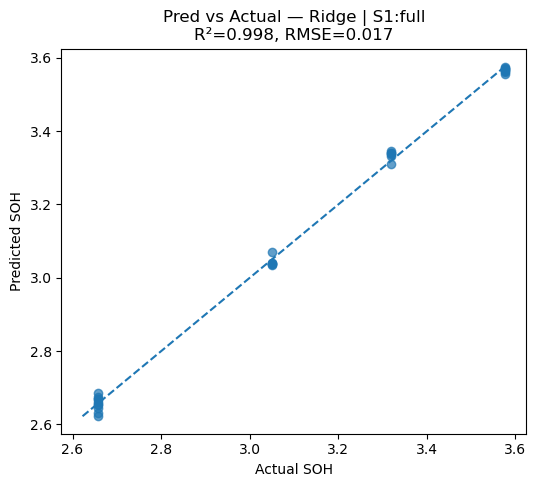

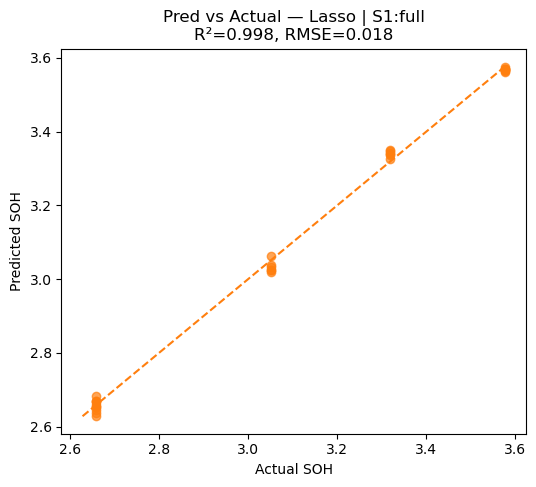

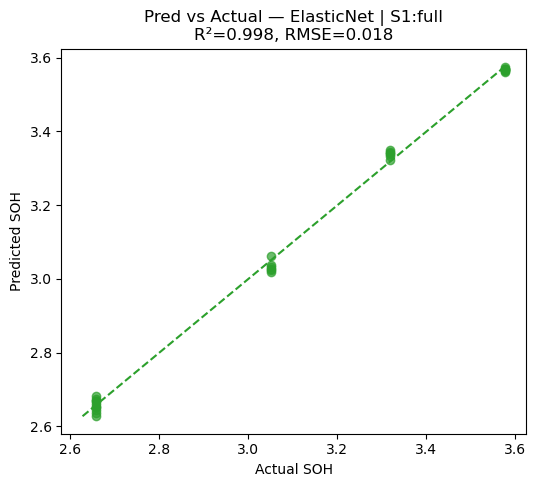

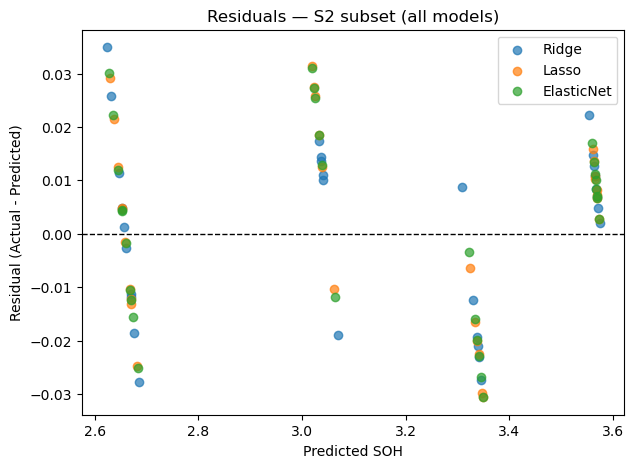

In [550]:
from itertools import product
from sklearn.model_selection import KFold, cross_val_predict
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=40)

def plot_cv_pred(pipe, X, y, title, cv, color):
    yhat = cross_val_predict(pipe, X, y, cv=cv)
    r2  = r2_score(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))

    plt.figure(figsize=(6,5))
    plt.scatter(y, yhat, alpha=0.7, color=color)
    lo, hi = min(y.min(), yhat.min()), max(y.max(), yhat.max())
    plt.plot([lo, hi], [lo, hi], "--", color=color) # 45-degree line
    plt.title(f"{title}\nR²={r2:.3f}, RMSE={rmse:.3f}")
    plt.xlabel("Actual SOH"); plt.ylabel("Predicted SOH")
    plt.show()

def residuals_all(models, X, y, title, cv, colors):
    fig, ax = plt.subplots(figsize=(7,5))
    
    for (name, pipe), color in zip(models.items(), colors):
        yhat = cross_val_predict(pipe, X, y, cv=cv)
        res = y - yhat
        ax.scatter(yhat, res, alpha=0.7, color=color, label=name)
    
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_xlabel("Predicted SOH")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(title)
    ax.legend()
    plt.show()


# example:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
cols = feature_sets["S1:full"]
X = X_full[cols].values
i=0
for name, pipe in models.items():
    plot_cv_pred(pipe, X, y, f"Pred vs Actual — {name} | S1:full", cv=kf , color = colors[i])
    i += 1

residuals_all(models, X, y, "Residuals — S2 subset (all models)", cv=kf,
              colors=["tab:blue", "tab:orange", "tab:green"])




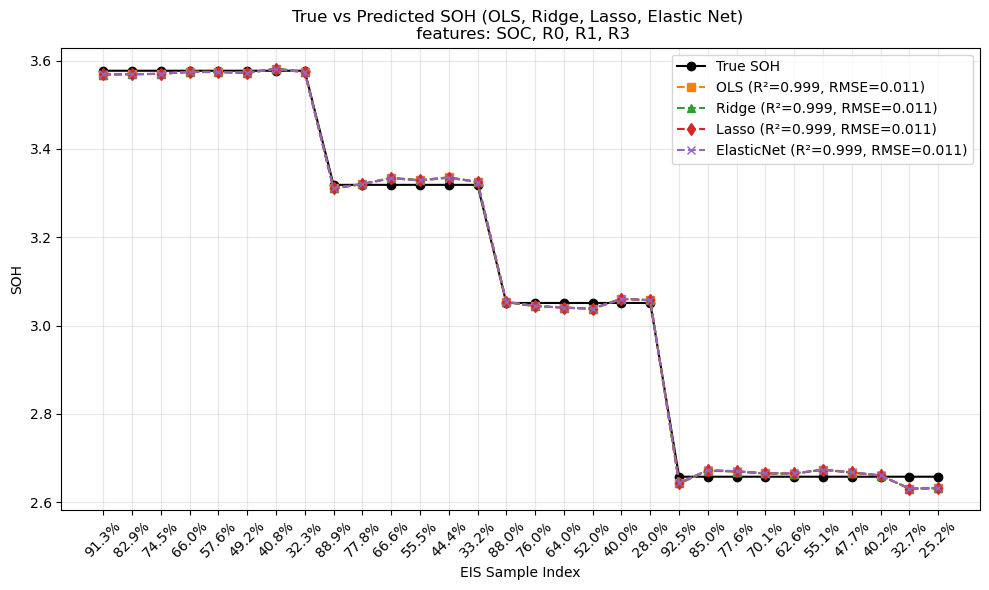

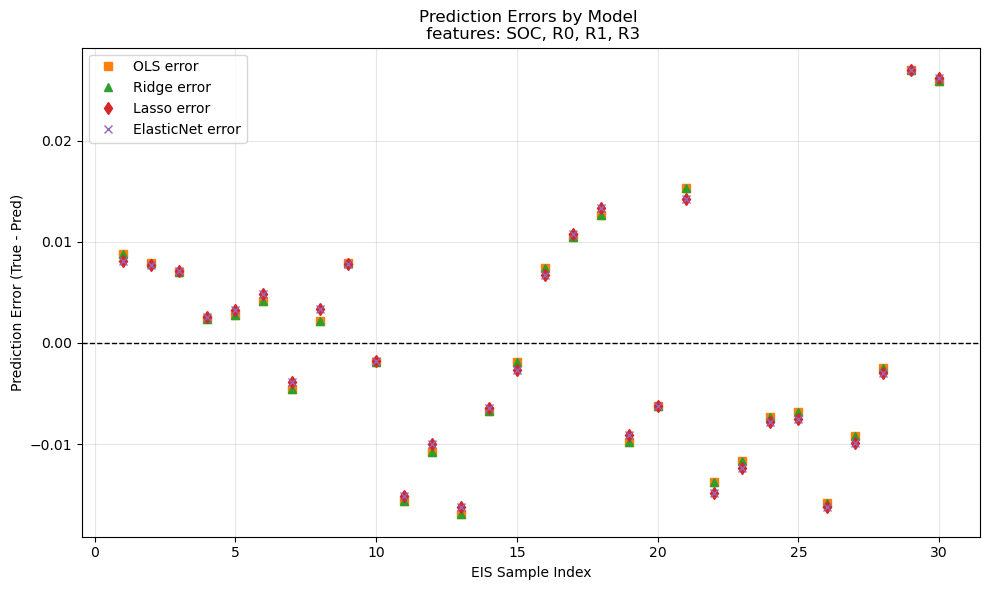

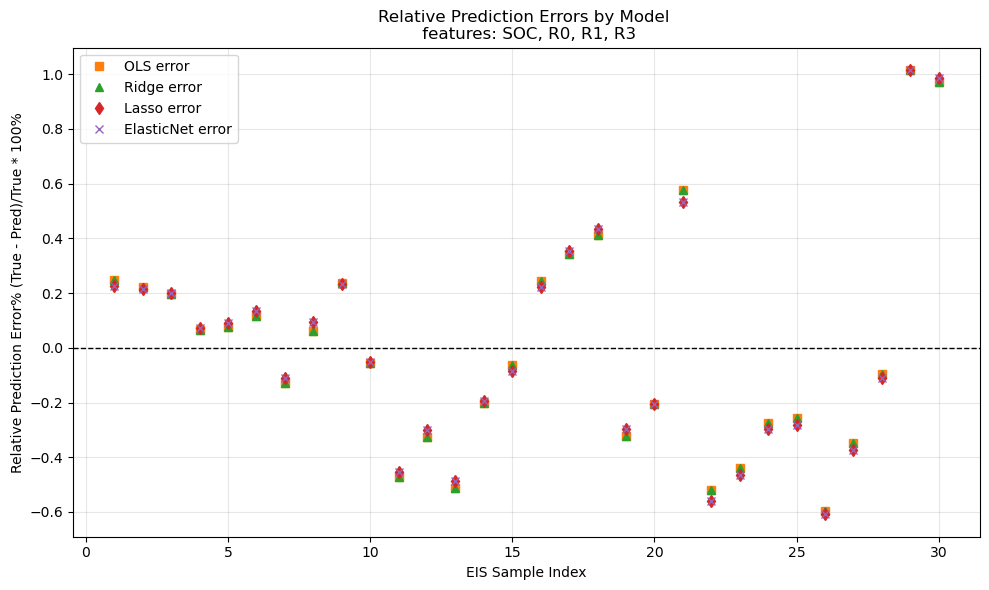

In [341]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.formula.api as smf

# ---- choose the subset you want to plot (here: SOC > 25%) ----

df_plot = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM7_RMSE_abs_trials50_rmOutliers/CELL042_v3CM7_trials50_median_socG25_allSOH.csv")
# df_plot = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM7_RMSE_abs_trials50_rmOutliers/CELL042_v3CM7_trials50_median_allSOH_allSOC.csv")



feature_cols = ["SOC","R0","R1","R3"]      
X = df_plot[feature_cols].values
y = df_plot["SOH"].values
idx = np.arange(1, len(y)+1)
idx_label = df_plot["SOC"].values *100             

# ---- OLS on the same features ----
formula = "SOH ~ " + " + ".join(feature_cols)
model_ols = smf.ols(formula, data=df_plot).fit()
yhat_ols = model_ols.predict(df_plot[feature_cols])

# ---- Fit/Refit the sklearn pipelines on the same data ----
ridge = models["Ridge"]
lasso = models["Lasso"] 
enet  = models["ElasticNet"]

ridge.fit(X, y)
lasso.fit(X, y)
enet.fit(X, y)

yhat_ridge = ridge.predict(X)
yhat_lasso = lasso.predict(X)
yhat_enet  = enet.predict(X)

# ---- Metrics (for legend labels) ----
def scores(y, yhat):
    r2 = r2_score(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    return r2, rmse

r2_o, rmse_o = scores(y, yhat_ols)
r2_r, rmse_r = scores(y, yhat_ridge)
r2_l, rmse_l = scores(y, yhat_lasso)
r2_e, rmse_e = scores(y, yhat_enet)

# =========================
# Plot 1: True vs Predicted
# =========================
plt.figure(figsize=(10,6))
plt.plot(idx, y, "o-", color="black", label="True SOH")
plt.plot(idx, yhat_ols,   "s--", color="tab:orange", label=f"OLS (R²={r2_o:.3f}, RMSE={rmse_o:.3f})")
plt.plot(idx, yhat_ridge, "^--", color="tab:green",  label=f"Ridge (R²={r2_r:.3f}, RMSE={rmse_r:.3f})")
plt.plot(idx, yhat_lasso, "d--", color="tab:red",    label=f"Lasso (R²={r2_l:.3f}, RMSE={rmse_l:.3f})")
plt.plot(idx, yhat_enet,  "x--", color="tab:purple", label=f"ElasticNet (R²={r2_e:.3f}, RMSE={rmse_e:.3f})")
plt.xlabel("EIS Sample Index")
plt.xticks(idx, [f"{val:.1f}%" for val in idx_label], rotation=45)
plt.ylabel("SOH")
plt.title(f"True vs Predicted SOH (OLS, Ridge, Lasso, Elastic Net) \n features: " + ", ".join(feature_cols))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



# =========================
# Plot 2: Prediction Errors
# e = True SOH - Predicted
# =========================
err_ols   = y - yhat_ols
err_ridge = y - yhat_ridge
err_lasso = y - yhat_lasso
err_enet  = y - yhat_enet

plt.figure(figsize=(10,6))
plt.plot(idx, err_ols,   "s", color="tab:orange", label="OLS error")
plt.plot(idx, err_ridge, "^", color="tab:green",  label="Ridge error")
plt.plot(idx, err_lasso, "d", color="tab:red",    label="Lasso error")
plt.plot(idx, err_enet,  "x", color="tab:purple", label="ElasticNet error")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.xlabel("EIS Sample Index")
plt.ylabel("Prediction Error (True - Pred)")
plt.title(f"Prediction Errors by Model \n features: " + ", ".join(feature_cols))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



# =========================
# Plot 3: Relative
# e = True SOH - Predicted
# =========================
err_ols   = ((y - yhat_ols)/y) * 100
err_ridge = ((y - yhat_ridge)/y) * 100
err_lasso = ((y - yhat_lasso)/y)* 100
err_enet  = ((y - yhat_enet)/y) * 100

plt.figure(figsize=(10,6))
plt.plot(idx, err_ols,   "s", color="tab:orange", label="OLS error")
plt.plot(idx, err_ridge, "^", color="tab:green",  label="Ridge error")
plt.plot(idx, err_lasso, "d", color="tab:red",    label="Lasso error")
plt.plot(idx, err_enet,  "x", color="tab:purple", label="ElasticNet error")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.xlabel("EIS Sample Index")
plt.ylabel("Relative Prediction Error% (True - Pred)/True * 100%")
plt.title(f"Relative Prediction Errors by Model \n features: " + ", ".join(feature_cols))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Fitting using median and test using all (SOC > 25% and remove Outliers)

30
soh: 3.57711999999088, number of inputs 8
soh: 3.31860999999049, number of inputs 6
soh: 3.05106999998998, number of inputs 6
soh: 2.65745999999217, number of inputs 10
                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     4248.
Date:                Mon, 01 Sep 2025   Prob (F-statistic):           5.22e-35
Time:                        00:04:06   Log-Likelihood:                 85.223
No. Observations:                  30   AIC:                            -160.4
Df Residuals:                      25   BIC:                            -153.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err      

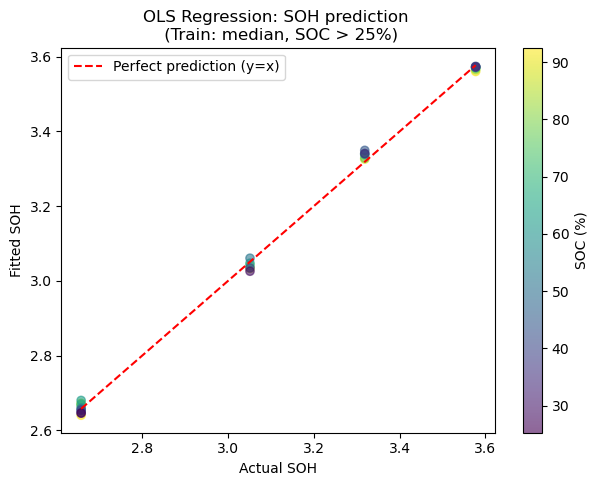

1240
soh: 3.57711999999088, number of inputs 270
soh: 3.31860999999049, number of inputs 239
soh: 3.05106999998998, number of inputs 279
soh: 2.65745999999217, number of inputs 452


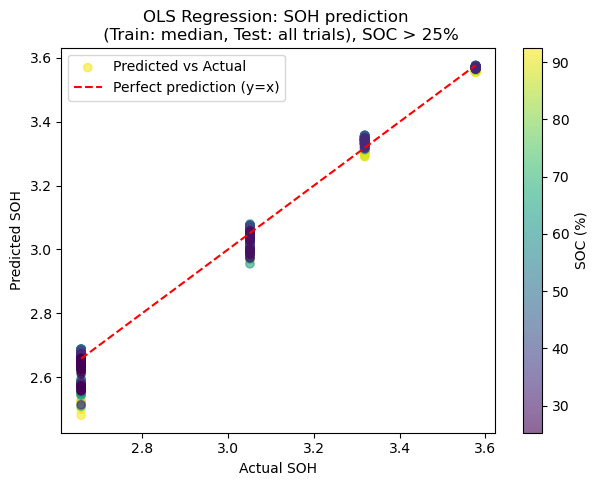

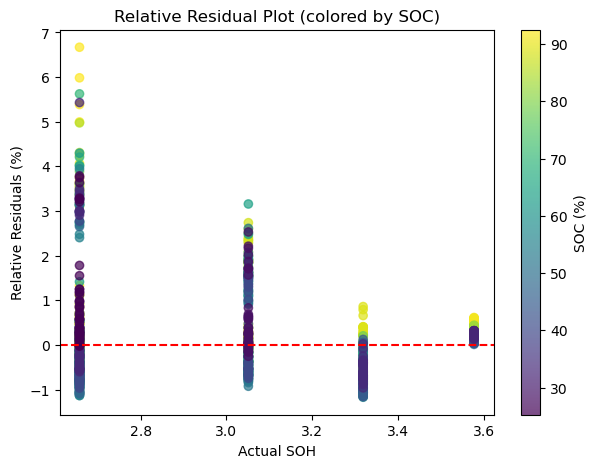

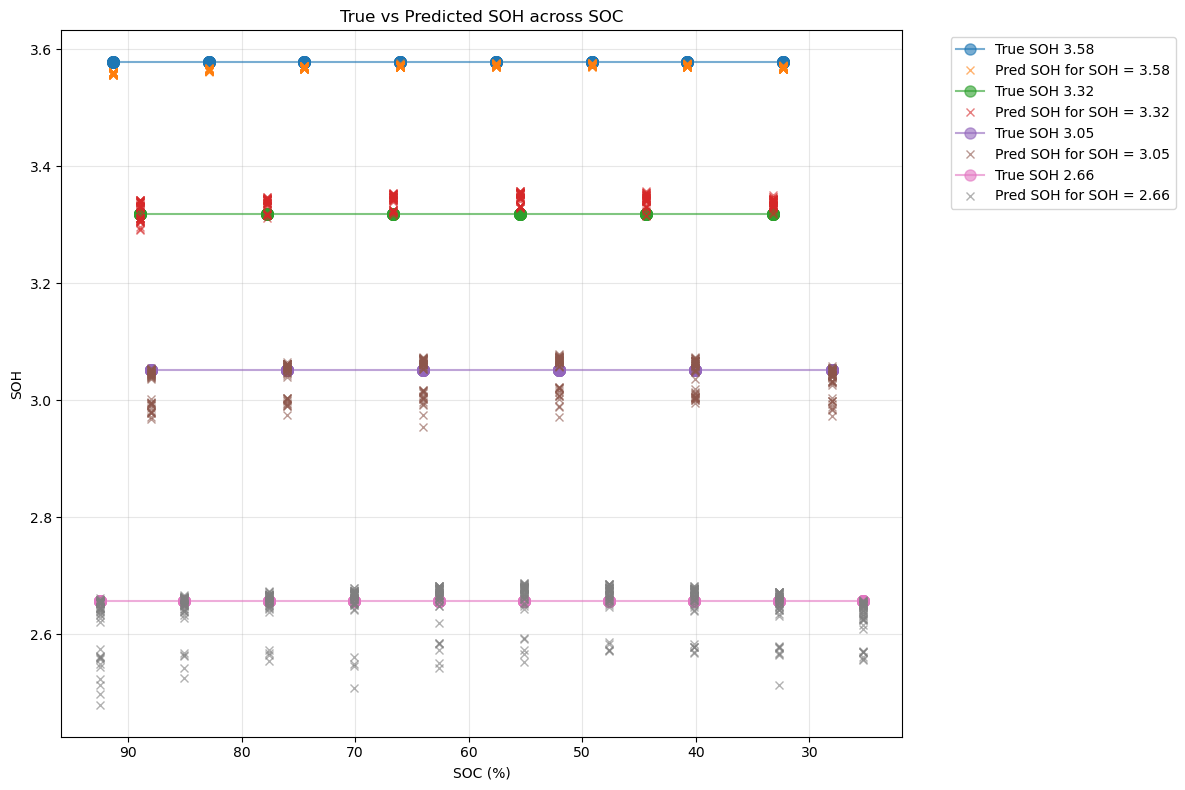

In [666]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# --- Load training ("median") and testing ("all") files ---
median_df = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_allSOH_median_G25SOC.csv")
all_df = pd.read_csv("ECM_Params_Estimation/CELL042/v3CM9_RMSE_abs_trials50_rmOutliers/CELL042_v3CM9_trials50_allSOH_all_G25SOC.csv")

# --- Choose predictors (X) and response (y) ---
# Example: predict R0 from SOH and SOC
X_train = median_df[["SOC", "R1", "R2", "R3"]]
y_train = median_df["SOH"]
X_train = sm.add_constant(X_train)  # adds intercept term
print(len(X_train))
for soh in median_df["SOH"].unique():
    print(f"soh: {soh}, number of inputs {len(median_df[median_df["SOH"]==soh])}")

# --- Fit OLS regression ---
model = sm.OLS(y_train, X_train).fit()
print(model.summary())
# Visualize 
plt.figure(figsize=(7,5))
sc = plt.scatter(y_train, model.fittedvalues, c=median_df["SOC"]*100, cmap="viridis", alpha=0.6,)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         "r--", label="Perfect prediction (y=x)")
plt.xlabel("Actual SOH")
plt.ylabel("Fitted SOH")
plt.title("OLS Regression: SOH prediction \n (Train: median, SOC > 25%)")
plt.legend()
cbar = plt.colorbar(sc)
cbar.set_label("SOC (%)")
plt.show()

# --- Predict on "all" file ---
X_test = all_df[["SOC", "R1", "R2", "R3"]]
X_test = sm.add_constant(X_test)
print(len(X_test))
for soh in all_df["SOH"].unique():
    print(f"soh: {soh}, number of inputs {len(all_df[all_df["SOH"]==soh])}")
all_df["SOH_pred"] = model.predict(X_test)


# ----- Visualization -----
plt.figure(figsize=(7,5))
sc = plt.scatter(
    all_df["SOH"],
    all_df["SOH_pred"],
    c=all_df["SOC"]*100,   
    cmap="viridis",
    alpha=0.6,
    label="Predicted vs Actual"
)

plt.plot([all_df["SOH"].min(), all_df["SOH"].max()],
         [all_df["SOH"].min(), all_df["SOH"].max()],
         "r--", label="Perfect prediction (y=x)")
plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("OLS Regression: SOH prediction \n (Train: median, Test: all trials), SOC > 25%")
plt.legend()
cbar = plt.colorbar(sc)
cbar.set_label("SOC (%)")
plt.show()

# -- Compute relative residuals (%) --
all_df["residuals"] = (all_df["SOH"] - all_df["SOH_pred"]) / all_df["SOH"] * 100

plt.figure(figsize=(7,5))
sc = plt.scatter(
    all_df["SOH"],
    all_df["residuals"],
    c=all_df["SOC"]*100,  
    cmap="viridis",   
    alpha=0.7
)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Actual SOH")
plt.ylabel("Relative Residuals (%)")
plt.title("Relative Residual Plot (colored by SOC)")
cbar = plt.colorbar(sc)
cbar.set_label("SOC (%)")
plt.show()


# -- Plot predicted vs true SOH across SOC levels --
plt.figure(figsize=(12,8))
soh_levels = sorted(all_df["SOH"].unique(), reverse=True)
for soh in soh_levels:
    df_soh = all_df[all_df["SOH"] == soh]
    plt.plot(df_soh["SOC"]*100, df_soh["SOH"], 
             "o-", alpha=0.6, markersize = 8, label=f"True SOH {soh:.2f}")
    plt.plot(df_soh["SOC"]*100, df_soh["SOH_pred"],
             "x", alpha=0.6, label=f"Pred SOH for SOH = {soh:.2f}")

plt.xlabel("SOC (%)")
plt.ylabel("SOH")
plt.title("True vs Predicted SOH across SOC")
plt.gca().invert_xaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


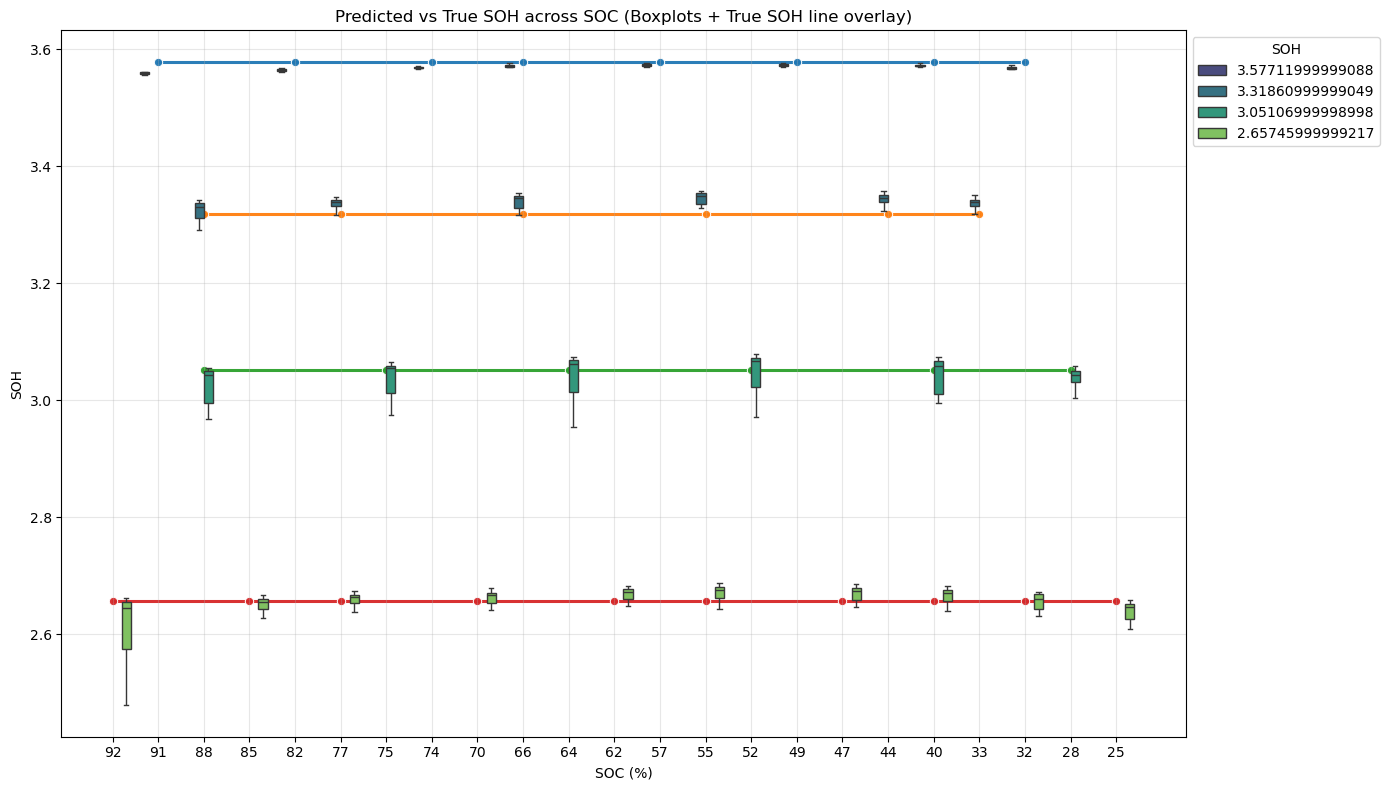

In [667]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare categorical axes & consistent orders
all_df["SOC_pct"]  = (all_df["SOC"]*100).astype(int)
all_df["SOC_cat"]  = all_df["SOC_pct"].astype(str)          # categorical x
all_df["SOH_str"]  = all_df["SOH"].astype(str)     # categorical hue

soc_order  = sorted(all_df["SOC_cat"].unique(), key=int, reverse=True)  # reverse to mimic invert_xaxis
soh_order  = sorted(all_df["SOH_str"].unique(), key=float, reverse=True)

plt.figure(figsize=(14, 8))
ax = sns.boxplot(
    data=all_df,
    x="SOC_cat", y="SOH_pred",
    hue="SOH_str",
    order=soc_order, hue_order=soh_order,
    dodge=True, showfliers=False,
    palette="viridis",
    zorder = 2
)

# True SOH as connected lines (same categorical x & hue orders)
sns.lineplot(
    data=all_df.drop_duplicates(subset=["SOC_cat","SOH_str"]),
    x="SOC_cat", y="SOH",
    hue="SOH_str",
    hue_order=soh_order,
    marker="o", linewidth=2.2, alpha=0.95,
    ax=ax, legend=False,  # keep only one legend (from boxplot)
    palette="tab10",
    zorder=1
)

ax.set_xlabel("SOC (%)")
ax.set_ylabel("SOH")
ax.set_title("Predicted vs True SOH across SOC (Boxplots + True SOH line overlay)")
ax.grid(True, alpha=0.3)

# Tidy legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(soh_order)], labels[:len(soh_order)],
          title="SOH", bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()


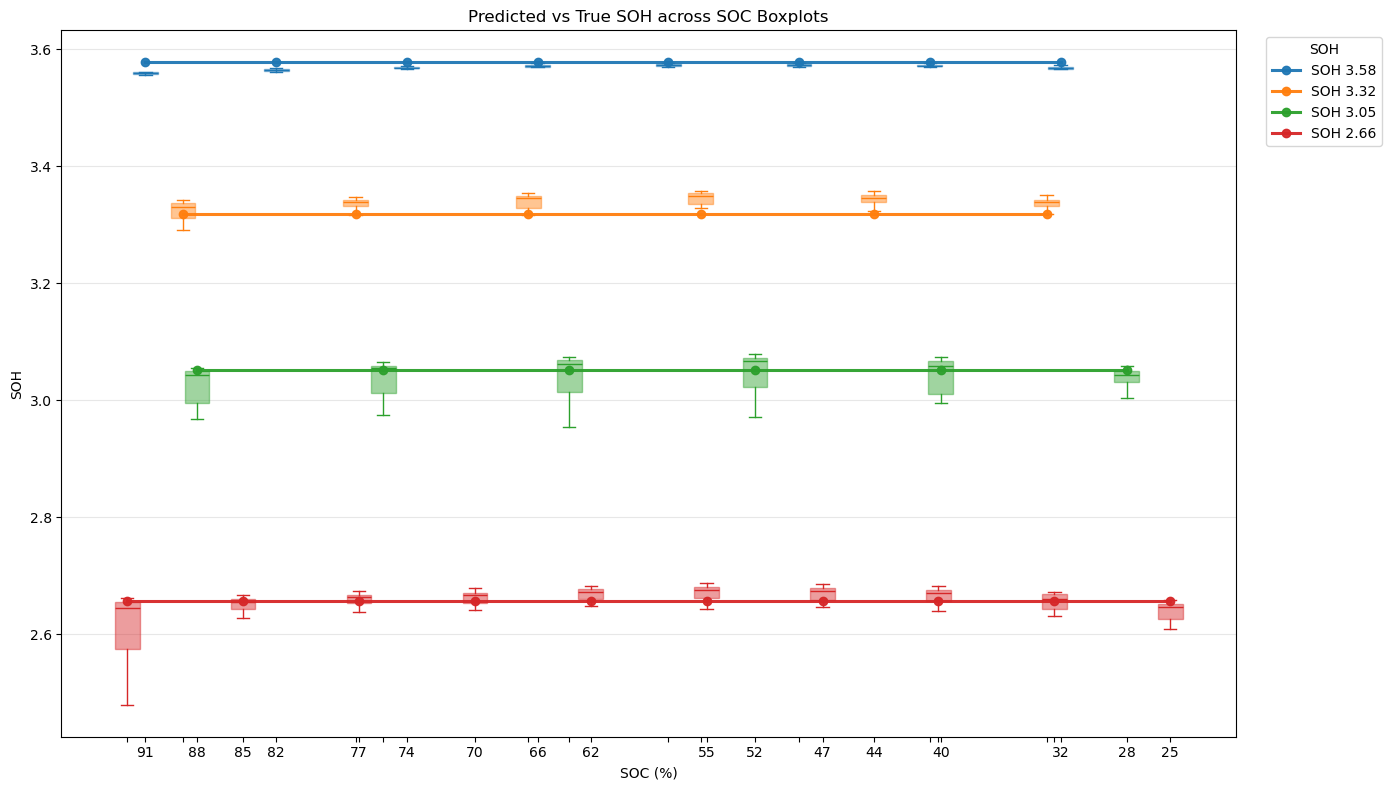

In [672]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # just for a nice palette (optional)
import pandas as pd

# --- Prep ---
all_df["SOC_pct"] = (all_df["SOC"]*100).astype(float)
soc_levels = np.array(sorted(all_df["SOC_pct"].unique()))
soh_levels = sorted(all_df["SOH"].unique(), reverse=True)

# visual params
palette = sns.color_palette("tab10", n_colors=len(soh_levels))
width = 1.6                    # visual width of each box (x-units)


plt.figure(figsize=(14, 8))

# --- 1) Draw boxplots with numeric positions---
for j, soh in enumerate(soh_levels):
    color = palette[j]
    # collect predicted values for each SOC (in same order as soc_levels)
    data_by_soc = [
        all_df[(all_df["SOH"] == soh) & (all_df["SOC_pct"] == soc)]["SOH_pred"].dropna().values
        for soc in soc_levels
    ]
    # positions for this SOH line of boxes
    pos = soc_levels
    # some SOCs may have no data for this SOH -> filter empties to keep boxplot happy
    data_nonempty, pos_nonempty = zip(*[(d, p) for d, p in zip(data_by_soc, pos) if len(d) > 0]) \
                                  if any(len(d) > 0 for d in data_by_soc) else ([], [])

    if len(data_nonempty) == 0:
        continue

    bp = plt.boxplot(
        data_nonempty,
        positions=pos_nonempty,
        widths=width,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        zorder=3  # draw on top
    )

    # color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color)
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color(color)

    # --- 2) Overlay true SOH as a line across available SOCs for this SOH ---
    # (only where data exists, so it lines up with the boxes)
    x_line = np.array(pos_nonempty)
    y_line = np.full_like(x_line, fill_value=soh, dtype=float)
    plt.plot(x_line, y_line, marker='o', linewidth=2.2, alpha=0.95, color=color, zorder=2, label=f"SOH {soh:.2f}")

# --- Axes, ticks, legend ---
plt.xlabel("SOC (%)")
plt.ylabel("SOH")
plt.title("Predicted vs True SOH across SOC Boxplots")

# put ticks at actual SOC levels (center of the groups)
labels = []
last = None
for s in soc_levels:
    if last is None or int(s) - int(last) >= 3:
        labels.append(f"{int(s)}")
        last = s
    else:
        labels.append("")

plt.xticks(soc_levels, labels)
plt.grid(True, axis="y", alpha=0.3)

# deduplicate legend (one entry per SOH)
handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), title="SOH", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()
